<a href="https://colab.research.google.com/github/Arfiadi/absd-customer-segmentation/blob/main/notebook/Customer_segementation_raw.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Business Understanding

## 1. Konteks Proyek

Proyek ini bertujuan untuk menganalisis heterogenitas pelanggan dalam database perusahaan. Dengan mengeksplorasi pola perilaku belanja, karakteristik demografi, dan respons historis pelanggan, perusahaan dapat beralih dari pendekatan pemasaran massal menuju pendekatan yang lebih tersegmentasi.

Fokus utama analisis adalah mengidentifikasi karakteristik yang membedakan satu kelompok pelanggan dengan kelompok lainnya secara sistematis.

---

## 2. Problem Statement

Penerapan strategi pemasaran tunggal (*one-size-fits-all*) pada basis pelanggan yang beragam berisiko menghasilkan relevansi penawaran yang rendah.

Tanpa pemahaman yang jelas mengenai perbedaan profil dan perilaku pelanggan, perusahaan mengalami kesulitan dalam:

* Mengidentifikasi kelompok pelanggan yang secara historis menunjukkan minat pada kategori produk tertentu.
* Menyesuaikan parameter penawaran berdasarkan kapasitas ekonomi dan struktur keluarga pelanggan.
* Menentukan saluran komunikasi (Web, Store, Catalog) yang paling sesuai untuk profil pelanggan tertentu.

---

## 3. Objektif Analisis

Tujuan utama analisis ini adalah melakukan **Segmentasi Pelanggan berbasis Perilaku (Behavioral Segmentation)** menggunakan pendekatan **Unsupervised Learning (Clustering)**.


## 4. Hasil yang Diharapkan (Expected Outcome)

Analisis ini menghasilkan **profil segmen pelanggan yang terdefinisi secara objektif dan berbasis data**.

Hasil tersebut dapat digunakan sebagai dasar untuk:

* Memahami variasi kebutuhan dan daya beli antar kelompok pelanggan.
* Menyusun rekomendasi target pemasaran yang lebih spesifik berdasarkan perilaku historis tiap segmen.
* Memberikan wawasan untuk penyesuaian penawaran produk agar lebih selaras dengan karakteristik kelompok pelanggan yang teridentifikasi.




# Data Understanding

---



Tahap ini bertujuan untuk memahami karakteristik data secara mendalam sebelum melakukan pemodelan. Kami melakukan audit menyeluruh untuk memastikan data yang digunakan memiliki kualitas yang valid dan mampu merepresentasikan profil pelanggan secara objektif.

In [ ]:
#Importing the Libraries
import numpy as np
import pandas as pd
import datetime
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import colors
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import RobustScaler
from sklearn.decomposition import PCA
from yellowbrick.cluster import KElbowVisualizer
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt, numpy as np
from mpl_toolkits.mplot3d import Axes3D
from sklearn.cluster import AgglomerativeClustering
from matplotlib.colors import ListedColormap
from sklearn import metrics
import warnings
import sys
if not sys.warnoptions:
    warnings.simplefilter("ignore")


In [ ]:


# ============================================================
# GLOBAL VISUAL THEME CONFIGURATION
# ============================================================

# 1. Warna Dasar (Parchment/Cream)
canvas_color = '#FFF8E7'
text_color = '#333333'

# 2. Update rcParams untuk konsistensi di SEMUA sel
plt.rcParams.update({
    'figure.facecolor': canvas_color,    # Warna canvas luar
    'axes.facecolor': canvas_color,      # Warna latar belakang plot
    'savefig.facecolor': canvas_color,   # Warna saat gambar disimpan
    'axes.edgecolor': '#D3D3D3',         # Warna garis tepi (border)
    'grid.color': '#E5E5E5',             # Warna garis grid (tipis saja)
    'text.color': text_color,
    'axes.labelcolor': text_color,
    'xtick.color': text_color,
    'ytick.color': text_color,
    'font.family': 'sans-serif',
    'figure.autolayout': True            # Biar gak ada teks kepotong
})

# 3. Set Palette Default Seaborn
sns.set_palette("coolwarm") # Atau lo bisa pake "RdBu_r"

print("Tema visual global Semua grafik akan seragam sekarang")

Tema visual global Semua grafik akan seragam sekarang


## Data Loading

In [ ]:
import pandas as pd

file_path = '/content/drive/MyDrive/Colab Notebooks/Data/marketing_campaign.csv'
pd.set_option('display.max_columns', None)
df = pd.read_csv(file_path, delimiter='\t')

df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0


---

## 👥 People (Profil Pelanggan)

Informasi dasar mengenai demografi dan histori hubungan pelanggan dengan perusahaan.

| Atribut | Deskripsi |
| --- | --- |
| **ID** | Identifikasi unik untuk setiap pelanggan. |
| **Year_Birth** | Tahun kelahiran pelanggan. |
| **Education** | Tingkat pendidikan terakhir pelanggan. |
| **Marital_Status** | Status pernikahan pelanggan. |
| **Income** | Pendapatan rumah tangga tahunan pelanggan. |
| **Kidhome** | Jumlah anak-anak dalam rumah tangga pelanggan. |
| **Teenhome** | Jumlah remaja dalam rumah tangga pelanggan. |
| **Dt_Customer** | Tanggal pendaftaran pelanggan di perusahaan. |
| **Recency** | Jumlah hari sejak pembelian terakhir pelanggan. |
| **Complain** | Nilai `1` jika pelanggan mengeluh dalam 2 tahun terakhir, `0` jika tidak. |

---

## 🍷 Products (Pengeluaran Produk)

Total nominal yang dihabiskan untuk berbagai kategori produk dalam 2 tahun terakhir.

* **MntWines**: Jumlah pengeluaran untuk produk anggur (wine).
* **MntFruits**: Jumlah pengeluaran untuk produk buah-buahan.
* **MntMeatProducts**: Jumlah pengeluaran untuk produk daging.
* **MntFishProducts**: Jumlah pengeluaran untuk produk ikan.
* **MntSweetProducts**: Jumlah pengeluaran untuk produk makanan manis.
* **MntGoldProds**: Jumlah pengeluaran untuk produk emas.

---

## 📣 Promotion (Aktivitas Promosi)

Data efektivitas kampanye pemasaran dan penggunaan diskon.

| Atribut | Deskripsi |
| --- | --- |
| **NumDealsPurchases** | Jumlah pembelian yang dilakukan dengan menggunakan diskon. |
| **AcceptedCmp1 - 5** | Nilai `1` jika pelanggan menerima penawaran pada kampanye ke-1 hingga ke-5, `0` jika tidak. |
| **Response** | Nilai `1` jika pelanggan menerima penawaran pada kampanye terakhir, `0` jika tidak. |

---

## 🛒 Place (Saluran Pembelian)

Informasi mengenai di mana pelanggan melakukan transaksi dan interaksi.

* **NumWebPurchases**: Jumlah pembelian yang dilakukan melalui situs web perusahaan.
* **NumCatalogPurchases**: Jumlah pembelian yang dilakukan menggunakan katalog.
* **NumStorePurchases**: Jumlah pembelian yang dilakukan langsung di toko fisik.
* **NumWebVisitsMonth**: Jumlah kunjungan ke situs web perusahaan dalam satu bulan terakhir.

---


## 2. Data Overview

### Struktur Umum

In [ ]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response'],
      dtype='object')

In [ ]:
df.shape

(2240, 29)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

Dataset terdiri dari 2.240 baris dengan 29 kolom awal yang mencakup informasi demografi, perilaku belanja, dan respons kampanye pemasaran. Peninjauan melalui df.info() menunjukkan bahwa sebagian besar kolom bertipe numerik (integer/float), dengan beberapa fitur kategorikal seperti Education dan Marital_Status.Selain itu, fitur Dt_Customer seharusnya bertipe tanggal.


### Statistik Deskriptif

In [ ]:
df.describe()

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2240.000000,2240.000000,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.0,2240.0,2240.000000
mean,5592.159821,1968.805804,52247.251354,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,27.062946,44.021875,2.325000,4.084821,2.662054,5.790179,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,3.0,11.0,0.149107
std,3246.662198,11.984069,25173.076661,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,41.280498,52.167439,1.932238,2.778714,2.923101,3.250958,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391,0.0,0.0,0.356274
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2828.250000,1959.000000,35303.000000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,1.000000,9.000000,1.000000,2.000000,0.000000,3.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,8.000000,24.000000,2.000000,4.000000,2.000000,5.000000,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8427.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,33.000000,56.000000,3.000000,6.000000,4.000000,8.000000,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,263.000000,362.000000,15.000000,27.000000,28.000000,13.000000,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000


Ringkasan statistik deskriptif memberikan gambaran awal mengenai karakteristik dataset melalui nilai minimum, maksimum, mean, median, dan standar deviasi. Nilai minimum dan maksimum membantu mengidentifikasi kemungkinan nilai error atau nilai ekstrem, namun nilai ekstrem tidak otomatis berarti kesalahan dan tetap harus dievaluasi berdasarkan konteks domain. Perbandingan antara mean dan median memberikan indikasi kemiringan distribusi; perbedaan yang signifikan menunjukkan kemungkinan distribusi tidak simetris atau bersifat skewed, yang umum terjadi pada fitur seperti income dan spending dan juga year birth. Sementara itu, standar deviasi menunjukkan tingkat variasi data, dan fitur dengan standar deviasi nol seperti Z_CostContact dan Z_Revenue menandakan tidak adanya variasi sehingga fitur tersebut tidak informatif untuk analisis sehingga sebaiknya dihapus sebelum proses analis lanjutan.

## 3. Data Quality Check

###  Missing Value & duplicates

In [ ]:
missing_counts = df.isnull().sum()
missing_percentages = (df.isnull().sum() / len(df)) * 100
missing_info = pd.DataFrame({
    'Missing Count': missing_counts,
    'Missing Percentage (%)': missing_percentages
})
print(missing_info[missing_info['Missing Count'] > 0])

        Missing Count  Missing Percentage (%)
Income             24                1.071429


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.duplicated(subset=['ID']).sum()

np.int64(0)

---
* Missing Values: Ditemukan sejumlah kecil missing values pada kolom Income (24 baris) yang jumlahnya sangat rendah sekitar ($21\%$), penanganan akan dilakukan pada tahap Data Preparation.
* Duplicates: Tidak ditemukan baris data duplikat, sehingga integritas unik setiap entitas pelanggan tetap terjaga
---

### Outlier dan Fitur Kategorik

In [ ]:
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], format='%d-%m-%Y')
# Ekstraksi tanggal tanpa waktu dari kolom Dt_Customer
dates = df["Dt_Customer"].dt.date.tolist()

# Mencari tanggal enrolment terbaru dan terlama
print("The newest customer's enrolment date in the records:", max(dates))
print("The oldest customer's enrolment date in the records:", min(dates))

The newest customer's enrolment date in the records: 2014-06-29
The oldest customer's enrolment date in the records: 2012-07-30


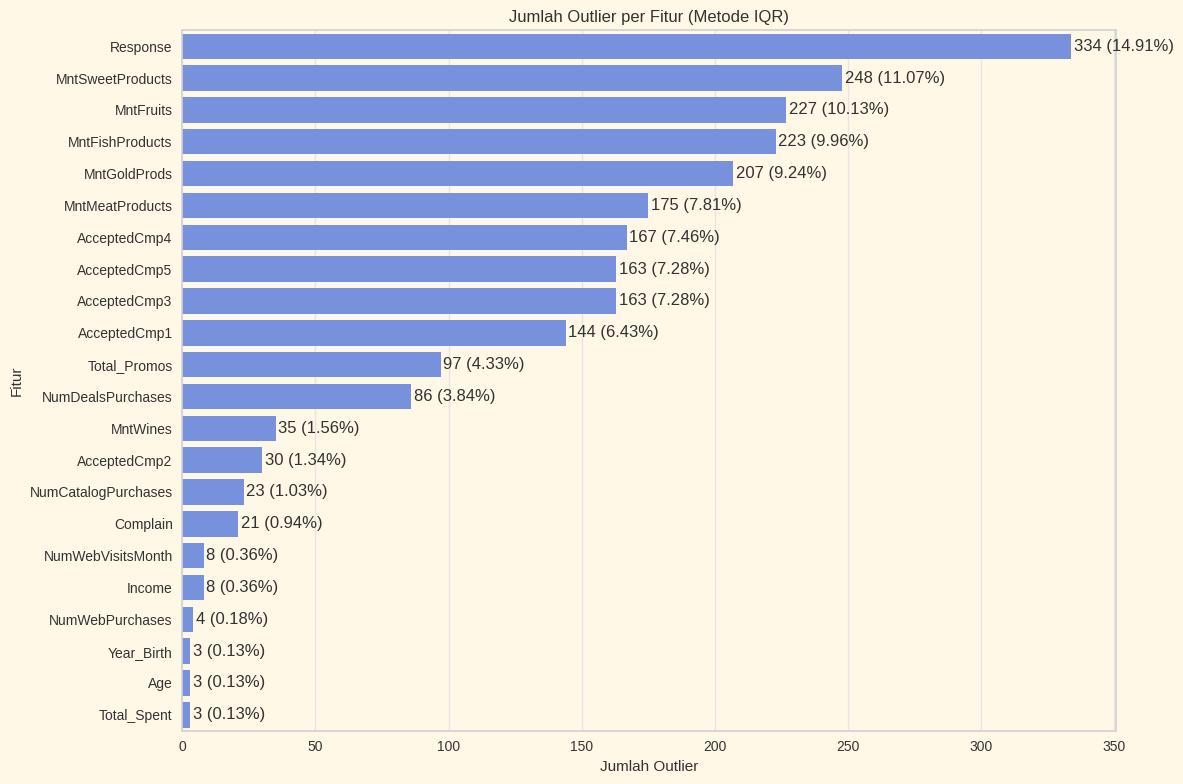

In [ ]:


# 1. KONSTRUKSI FITUR AGREGAT (UNTUK DIAUDIT)
# Feature Engineering Sementara untuk Eksplorasi
df['Age'] = 2014 - df['Year_Birth'] # Menggunakan 2014 sebagai referensi tahun data
df['Total_Spent'] = df[['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']].sum(axis=1)
df['Total_Promos'] = df[['AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'Response']].sum(axis=1)
df['Total_Purchases'] = df[['NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases']].sum(axis=1)


# 2. FUNGSI DETEKSI OUTLIER (IQR)

def get_outlier_summary(df):
    outlier_list = []
    numeric_cols = df.select_dtypes(include=[np.number]).columns

    for col in numeric_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        count = df[(df[col] < lower_bound) | (df[col] > upper_bound)].shape[0]
        percentage = (count / len(df)) * 100

        outlier_list.append({
            'Feature': col,
            'Outlier_Count': count,
            'Percentage (%)': percentage
        })

    return pd.DataFrame(outlier_list)

outlier_df = get_outlier_summary(df)

# Hanya tampilkan fitur dengan outlier
outlier_df = outlier_df[outlier_df['Outlier_Count'] > 0]
outlier_df = outlier_df.sort_values(by='Outlier_Count', ascending=False)


#3. VISUALISASI OUTLIER


plt.figure(figsize=(12, 8))

ax = sns.barplot(
    data=outlier_df,
    y='Feature',
    x='Outlier_Count'
)

plt.title("Jumlah Outlier per Fitur (Metode IQR)")
plt.xlabel("Jumlah Outlier")
plt.ylabel("Fitur")

# Tambahkan anotasi jumlah & persentase
for i, row in enumerate(outlier_df.itertuples()):
    ax.text(
        row.Outlier_Count + 1,      # posisi sedikit di kanan bar
        i,                          # posisi vertikal sesuai index
        f"{row.Outlier_Count} ({row._3:.2f}%)",  # _3 adalah Percentage (%)
        va='center'
    )

plt.tight_layout()
plt.show()

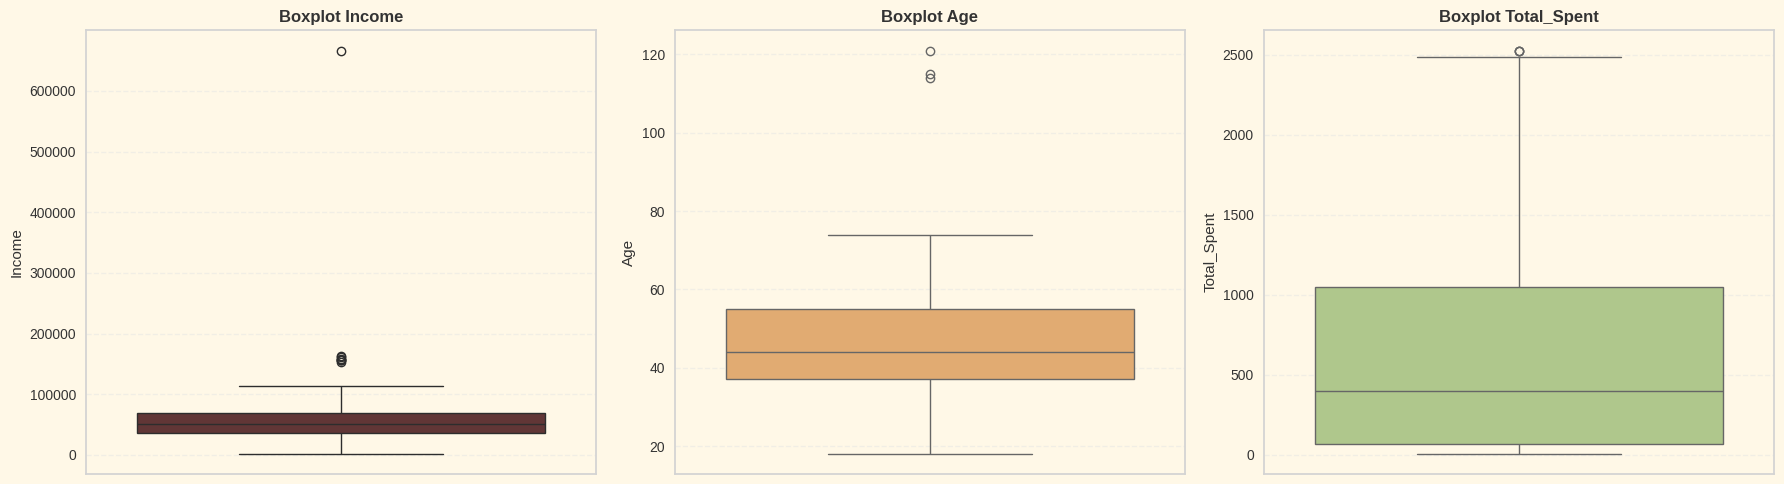


                                  DAFTAR DETAIL DATA OUTLIER                                   

>> FITUR: INCOME
   Jumlah Outlier: 8 baris
   Batas Normal  : -14525.50 s/d 118350.50
-----------------------------------------------------------------------------------------------


,ID,Age,Income,Total_Spent,Total_Purchases,Total_Promos
2233,9432,37,666666.0,62,7,0
617,1503,38,162397.0,107,1,0
687,1501,32,160803.0,1717,29,0
1300,5336,43,157733.0,59,2,0
164,8475,41,157243.0,1608,22,0
1653,4931,37,157146.0,1730,28,0
2132,11181,65,156924.0,8,0,0
655,5555,39,153924.0,6,0,0



>> FITUR: AGE
   Jumlah Outlier: 3 baris
   Batas Normal  : 10.00 s/d 82.00
-----------------------------------------------------------------------------------------------


,ID,Age,Income,Total_Spent,Total_Purchases,Total_Promos
239,11004,121,60182.0,22,3,0
339,1150,115,83532.0,1853,14,1
192,7829,114,36640.0,65,5,0



>> FITUR: TOTAL_SPENT
   Jumlah Outlier: 3 baris
   Batas Normal  : -1396.38 s/d 2510.62
-----------------------------------------------------------------------------------------------


,ID,Age,Income,Total_Spent,Total_Purchases,Total_Promos
1179,5735,23,90638.0,2525,17,1
1572,5350,23,90638.0,2525,17,2
1492,1763,26,87679.0,2524,28,4


In [ ]:
# --- 4. VISUALISASI BOXPLOT & INSPEKSI BARIS OUTLIER ---

# Menggunakan Age sebagai pengganti Year_Birth untuk analisis demografi
target_features = ['Income', 'Age', 'Total_Spent']

# A. Visualisasi Sebaran Outlier
plt.figure(figsize=(18, 5))
colors = ['#682F2F', '#F3AB60', '#B1D182']

for i, col in enumerate(target_features):
    plt.subplot(1, 3, i+1)
    sns.boxplot(y=df[col], color=colors[i], fliersize=6)
    plt.title(f"Boxplot {col}", fontsize=12, fontweight='bold')
    plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# B. Ekstraksi dan Penampilan Baris Outlier (Metode IQR)
print("\n" + "="*95)
print(f"{'DAFTAR DETAIL DATA OUTLIER ':^95}")
print("="*95)

for col in target_features:
    # Perhitungan Statistik IQR
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Identifikasi baris outlier
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

    print(f"\n>> FITUR: {col.upper()}")
    print(f"   Jumlah Outlier: {len(outliers)} baris")
    print(f"   Batas Normal  : {lower_bound:.2f} s/d {upper_bound:.2f}")
    print("-" * 95)

    if not outliers.empty:
        # Menampilkan kolom-kolom strategis untuk verifikasi manual
        # Mengurutkan berdasarkan nilai tertinggi untuk melihat anomali paling ekstrem
        display(outliers[['ID', 'Age', 'Income', 'Total_Spent', 'Total_Purchases', 'Total_Promos']]
                .sort_values(by=col, ascending=False))
    else:
        print("   Hasil: Tidak ditemukan data di luar batas normal.")

print("\n" + "="*95)

Deteksi outlier dilakukan menggunakan metode $IQR$ untuk membedakan antara noise yang bersifat merusak integritas data (*Data Error/invalid*) dan nilai ekstrem yang memiliki nilai informasi bisnis.
Berdasarkan temuan pada tahap ini:
* Fitur Kampanye (Response, AcceptedCmp): Mencatat persentase outlier tertinggi hingga 14.91%. Setelah ditinjau kembali, temuan ini bukan merupakan kerusakan data, melainkan refleksi dari class imbalance. Mayoritas pelanggan tidak merespons kampanye (nilai 0), sehingga kelompok minoritas yang merespons (nilai 1) secara statistik terdeteksi sebagai outlier.

* Fitur Pengeluaran (Mnt... & Total_Spent) menunjukkan jumlah outlier cukup banyak. Namun,jika melihat gambaran dari **statistik deskriptif sebelumnya**, nilai maksimum dan minimum pada fitur-fitur tersebut (seperti `Total_Spent` sebesar 2.525 atau `MntMeatProducts` sebesar 1.725) masih berada dalam rentang kewajaran logika dan ekonomi (*plausible*).Nilai tersebut merepresentasikan profil pelanggan **"High-Value"** yang riil sehingga akan dipertahankan karena mengandung informasi bisnis yang berharga untuk segmentasi.

kemudian, Fitur **Income** dan **Age** dilakukan pengecekan lebih lanjut untuk memvalidasi apakah anomali tersebut merupakan kesalahan input atau nilai ekstrem yang valid. Berdasarkan investigasi baris data:
* Pada fitur **Age**, ditemukan tiga observasi dengan usia **114 hingga 121 tahun**. Temuan ini diklasifikasikan sebagai anomali biologis yang tidak logis dalam konteks pelanggan aktif saat ini.
* Pada fitur **Income**, ditemukan nilai ekstrem **$666.666** (ID 11191).jika melihat fitur lainnya pada baris tersebut, misalnya nilai `Total_Spent` pelanggan tersebut hanya sebesar **62**,ini mengindikasikan adanya ketidakkonsistenan data atau *entry error*.


Catatan: Batas bawah bernilai negatif karena secara matematis nilai pengurang $1.5 \times \text{IQR}$ lebih besar daripada nilai $Q1$.


In [ ]:
# 2. Cek Fitur Kategorikal
print("--- Marital Status Counts ---")
print(df['Marital_Status'].value_counts())
print("\n--- Education Counts ---")
print(df['Education'].value_counts())

--- Marital Status Counts ---
Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

--- Education Counts ---
Education
Graduation    1127
PhD            486
Master         370
2n Cycle       203
Basic           54
Name: count, dtype: int64


Selain pemeriksaan fitur numerik, pemeriksaan juga dilakukan pada kolom kategorikal untuk memastikan konsistensi label dan validitas informasi bisnis:

* Marital Status Anomaly:

  * Ditemukan label yang tidak standar dan tidak memiliki definisi bisnis yang jelas, yaitu Alone (3), Absurd (2), dan YOLO (2).Label ini merupakan noise yang akan menambah cardinality tanpa memberikan nilai informasi yang signifikan bagi algoritma clustering.

  * Rencana Tindakan: Pada tahap Preparation, label-label minor ini akan digabungkan ke kategori yang lebih relevan (misal: Alone menjadi Single) atau diseragamkan untuk menyederhanakan ruang fitur.

* Education Level Distribution:

  * Distribusi pendidikan didominasi oleh kelompok Graduation (1.127), diikuti oleh PhD dan Master. Terdapat kategori 2n Cycle, yang dalam konteks sistem pendidikan tertentu setara dengan Master, namun di sini berdiri sendiri.

  * Rencana Tindakan: Akan dilakukan evaluasi apakah perlu dilakukan encoding hirarki (Ordinal Encoding) atau pengelompokan ulang untuk memperkuat pilar demografi dalam klastering.

## Distribusi dan Korelasi

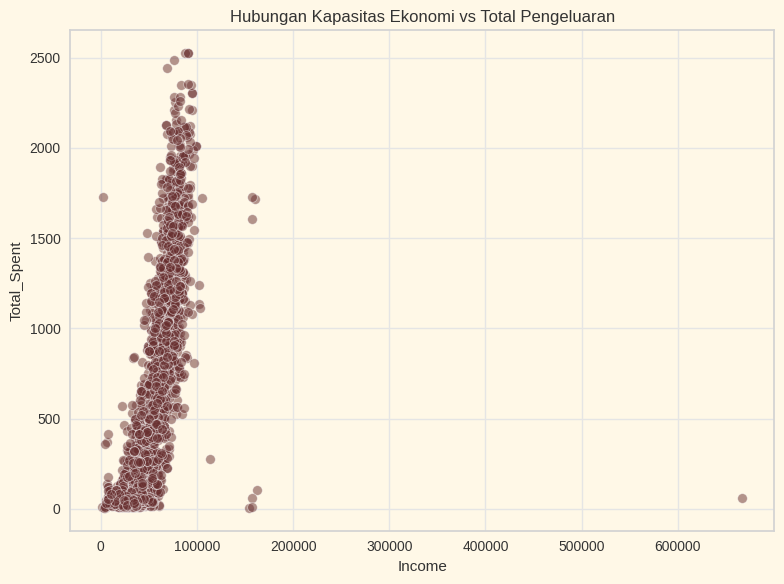

In [ ]:


# A. Pilar People: Hubungan Income vs Total Spent
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='Income', y='Total_Spent', alpha=0.5, color="#682F2F")
plt.title("Hubungan Kapasitas Ekonomi vs Total Pengeluaran")
plt.show()

/tmp/ipykernel_53342/1665377286.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


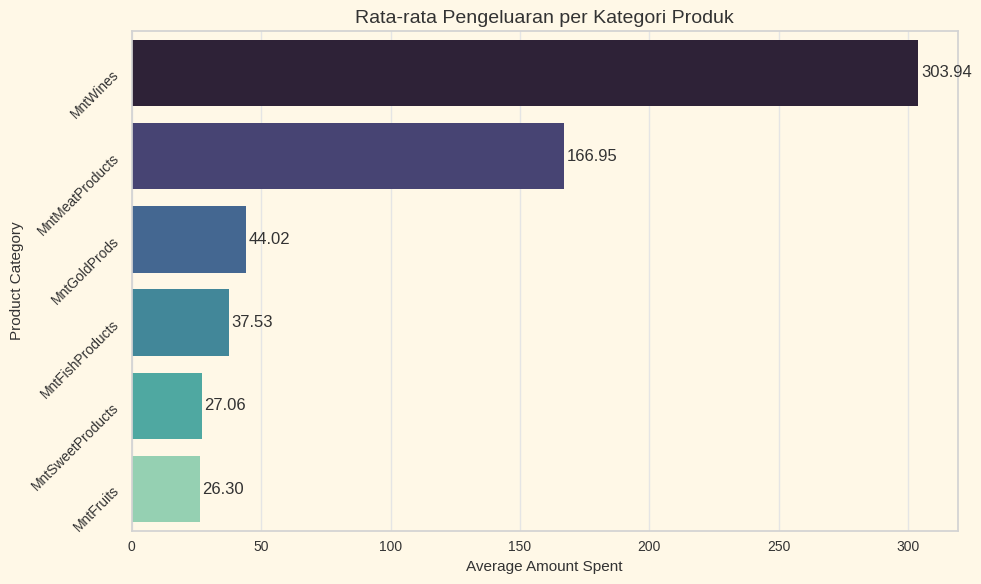

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# B. Product
mnt_cols = [
    'MntWines',
    'MntFruits',
    'MntMeatProducts',
    'MntFishProducts',
    'MntSweetProducts',
    'MntGoldProds'
]

spending_shares = df[mnt_cols].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
ax = sns.barplot(
    x=spending_shares.values,
    y=spending_shares.index,
    palette="mako"
)

plt.title("Rata-rata Pengeluaran per Kategori Produk", fontsize=14)
plt.xlabel("Average Amount Spent")
plt.ylabel("Product Category")

# Tambahkan anotasi angka
for i, v in enumerate(spending_shares.values):
    ax.text(v + 1, i, f"{v:.2f}", va='center')
# 🔎 Miringkan label sumbu Y
for label in ax.get_yticklabels():
    label.set_rotation(45)

plt.tight_layout()
plt.show()

/tmp/ipykernel_53342/400659832.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


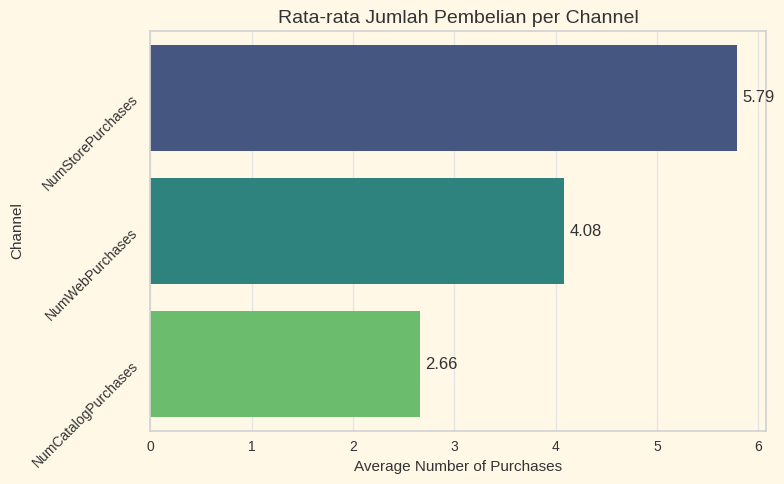

In [ ]:
# C. Place
place_cols = [
    'NumWebPurchases',
    'NumCatalogPurchases',
    'NumStorePurchases'
]

channel_dist = df[place_cols].mean().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
ax = sns.barplot(
    x=channel_dist.values,
    y=channel_dist.index,
    palette="viridis"
)

plt.title("Rata-rata Jumlah Pembelian per Channel", fontsize=14)
plt.xlabel("Average Number of Purchases")
plt.ylabel("Channel")

# Tambahkan anotasi angka
for i, v in enumerate(channel_dist.values):
    ax.text(v + 0.05, i, f"{v:.2f}", va='center')
# Miringkan label sumbu Y
for label in ax.get_yticklabels():
    label.set_rotation(45)

plt.tight_layout()
plt.show()

--- Analisis Nilai Skewness (Kemiringan Distribusi) ---
Complain               10.188972
AcceptedCmp2            8.472093
Income                  6.763487
AcceptedCmp1            3.555444
AcceptedCmp5            3.291705
AcceptedCmp3            3.291705
AcceptedCmp4            3.241574
Total_Promos            2.441021
NumDealsPurchases       2.418569
MntSweetProducts        2.136081
MntFruits               2.102063
MntMeatProducts         2.083233
Response                1.971555
MntFishProducts         1.919769
MntGoldProds            1.886106
NumCatalogPurchases     1.880989
NumWebPurchases         1.382794
MntWines                1.175771
Total_Spent             0.860841
NumStorePurchases       0.702237
Kidhome                 0.635288
Teenhome                0.407115
Age                     0.349944
Total_Purchases         0.297114
NumWebVisitsMonth       0.207926
Recency                -0.001987
Year_Birth             -0.349944
dtype: float64


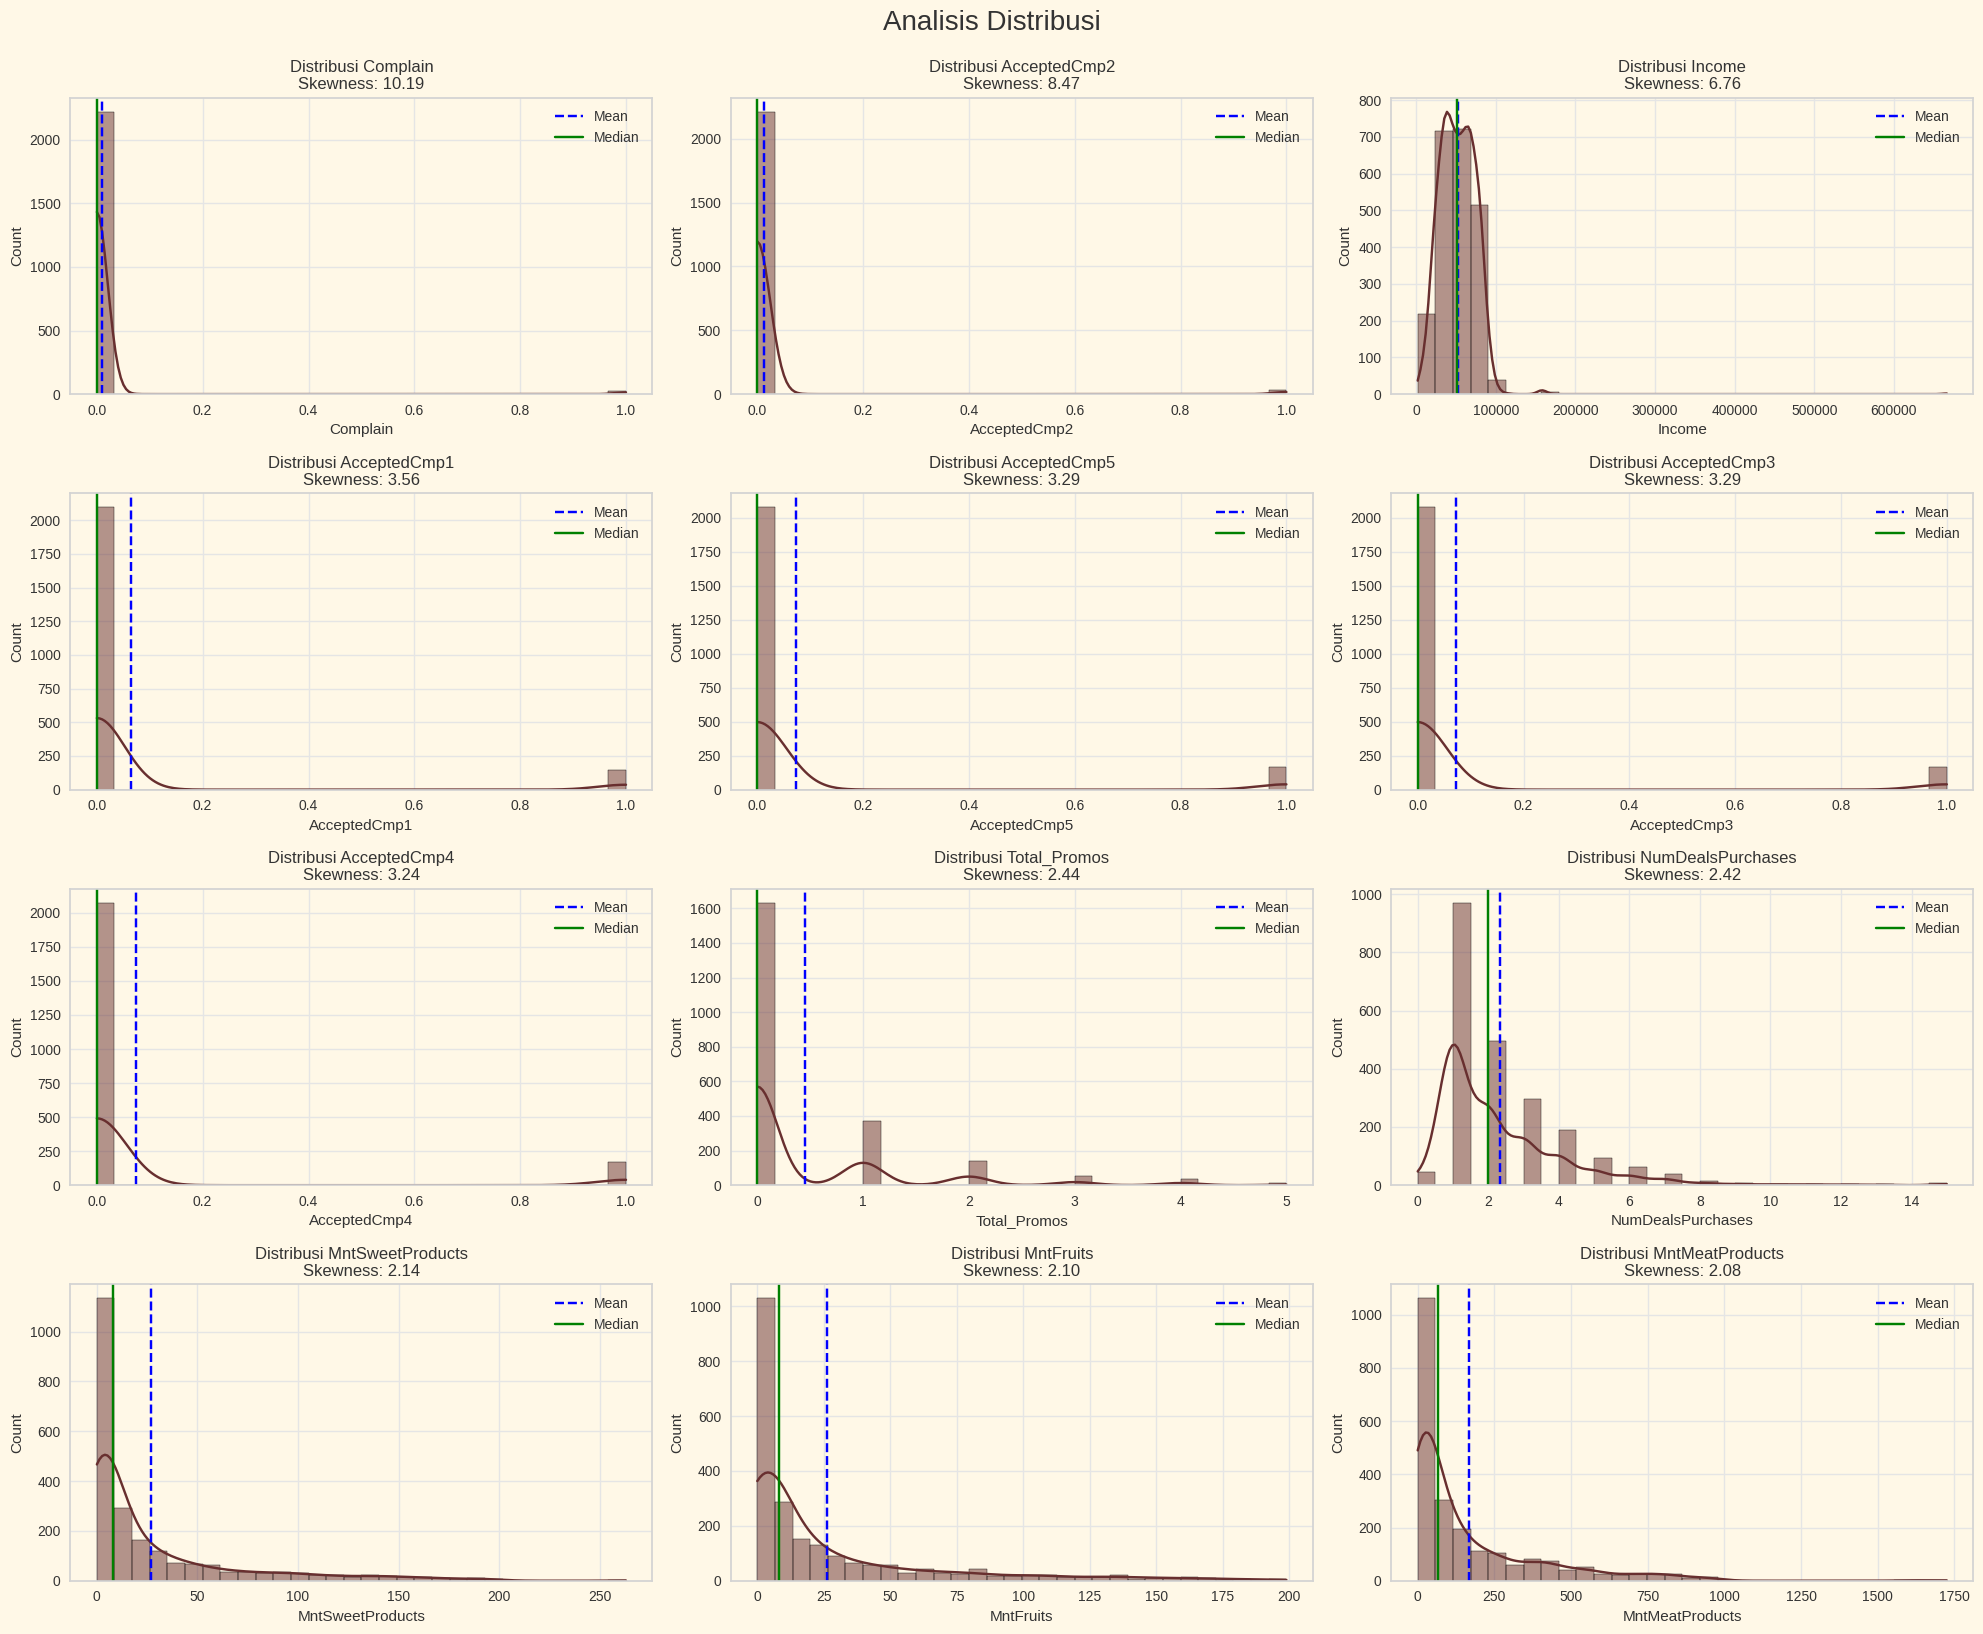

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. ANALISIS DISTRIBUSI & SKEWNESS

# Memilih kolom numerik untuk dicek distribusinya (Menghapus ID dan fitur konstan)
# Kita definisikan list fitur utama agar visualisasi tidak terlalu penuh
features_to_check = df.select_dtypes(include=[np.number]).columns.tolist()
if 'ID' in features_to_check:
    features_to_check.remove('ID')

# Menghapus fitur dengan standar deviasi 0 (Z_CostContact, Z_Revenue) karena tidak ada variansi
features_to_check = [col for col in features_to_check if df[col].std() > 0]

print("--- Analisis Nilai Skewness (Kemiringan Distribusi) ---")
skewness_values = df[features_to_check].skew().sort_values(ascending=False)
print(skewness_values)

# Visualisasi Distribusi Fitur (KDE Plot untuk melihat "ekor" distribusi)
plt.figure(figsize=(20, 16))
# Menampilkan 12 fitur dengan skewness tertinggi/paling menarik
for i, col in enumerate(skewness_values.index[:12]):
    plt.subplot(4, 3, i+1)
    sns.histplot(df[col], kde=True, color='#682F2F', bins=30)
    plt.axvline(df[col].mean(), color='blue', linestyle='--', label='Mean')
    plt.axvline(df[col].median(), color='green', linestyle='-', label='Median')
    plt.title(f'Distribusi {col}\nSkewness: {df[col].skew():.2f}', fontsize=12)
    plt.legend()

plt.tight_layout()
plt.suptitle("Analisis Distribusi", fontsize=20, y=1.02)
plt.show()




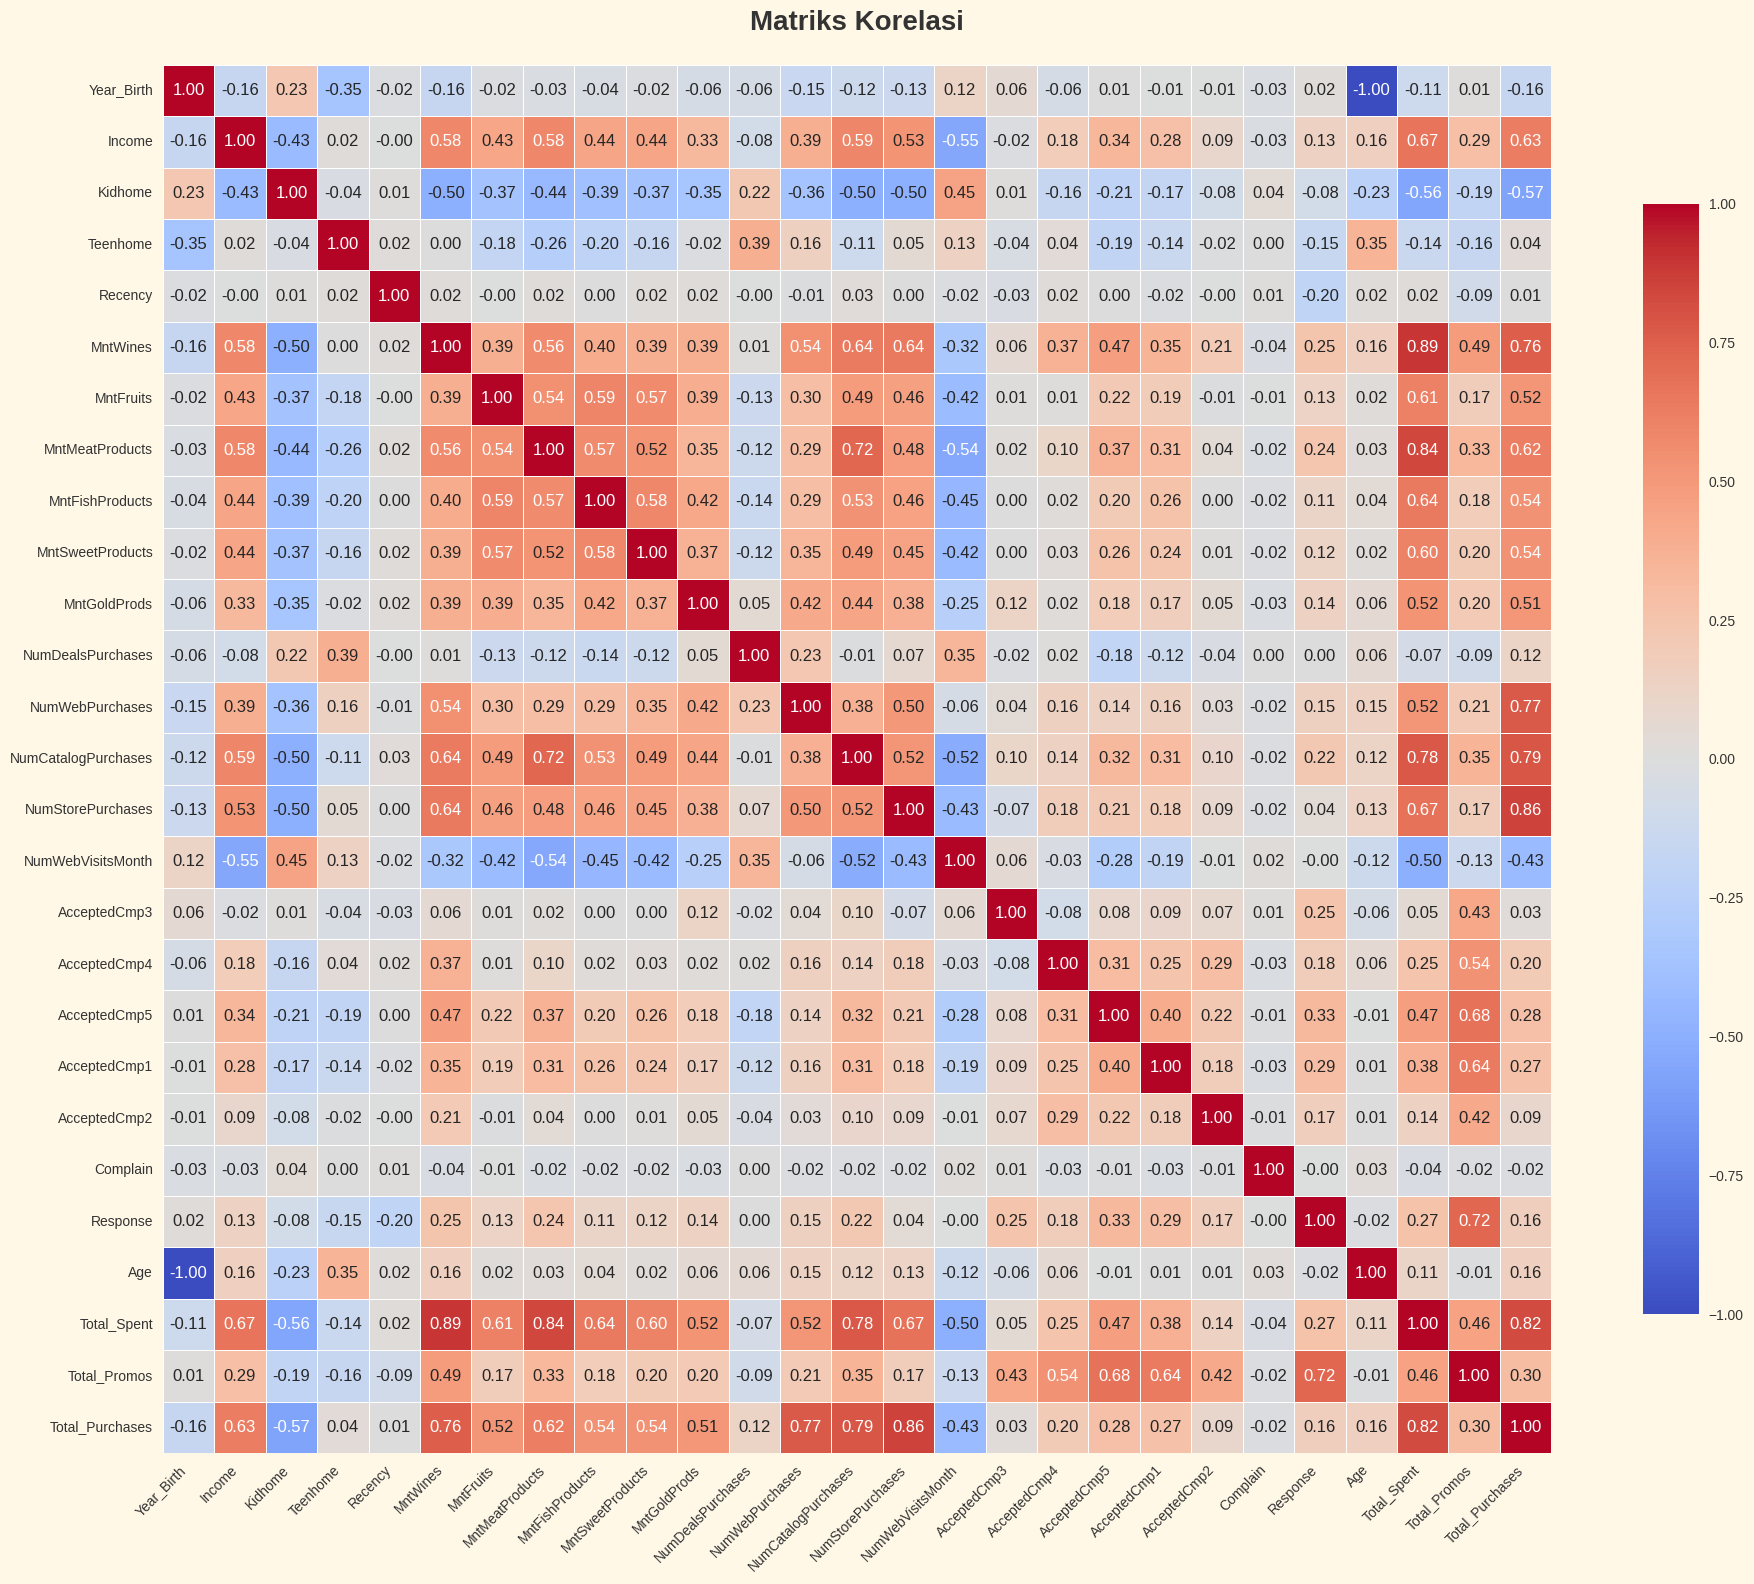


Fitur Korelasi Tinggi (> 0.70)
MntWines             Total_Spent            0.891839
Total_Purchases      NumStorePurchases      0.855454
Total_Spent          MntMeatProducts        0.842965
                     Total_Purchases        0.820687
Total_Purchases      NumCatalogPurchases    0.785609
Total_Spent          NumCatalogPurchases    0.778577
NumWebPurchases      Total_Purchases        0.765923
MntWines             Total_Purchases        0.756490
Total_Promos         Response               0.724600
NumCatalogPurchases  MntMeatProducts        0.723827
dtype: float64


In [ ]:
# 2. ANALISIS KORELASI & MULTIKOLINEARITAS
# Mengambil kolom numerik dari fitur yang sudah difilter sebelumnya
numeric_cols = df[features_to_check]

# Menghitung matriks korelasi Pearson
full_corr_matrix = numeric_cols.corr()

# Visualisasi Heatmap Global (Full Version)
plt.figure(figsize=(20, 16))

# Tanpa 'mask' agar heatmap tampil penuh (simetris)
sns.heatmap(
    full_corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    center=0,
    linewidths=0.5,
    linecolor='white',
    cbar_kws={"shrink": .8},
    square=True # Memastikan sel tetap kotak sempurna
)

plt.title("Matriks Korelasi",
          fontsize=20, fontweight='bold', pad=25)
plt.xticks(rotation=45, ha='right')
plt.show()

# --- Identifikasi Redundansi Data ---
print("\n" + "="*50)
print("Fitur Korelasi Tinggi (> 0.70)")
print("="*50)

# Mencari pasangan fitur dengan korelasi tinggi
high_corr = full_corr_matrix.unstack().sort_values(ascending=False)

# Filter: > 0.7 (Redundan) dan < 1.0 (Bukan diri sendiri)
high_corr_filtered = high_corr[(high_corr > 0.7) & (high_corr < 1.0)].drop_duplicates()

if not high_corr_filtered.empty:
    print(high_corr_filtered)
else:
    print("Tidak ditemukan pasangan fitur dengan korelasi di atas 0.7")

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 33 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   ID                   2240 non-null   int64         
 1   Year_Birth           2240 non-null   int64         
 2   Education            2240 non-null   object        
 3   Marital_Status       2240 non-null   object        
 4   Income               2216 non-null   float64       
 5   Kidhome              2240 non-null   int64         
 6   Teenhome             2240 non-null   int64         
 7   Dt_Customer          2240 non-null   datetime64[ns]
 8   Recency              2240 non-null   int64         
 9   MntWines             2240 non-null   int64         
 10  MntFruits            2240 non-null   int64         
 11  MntMeatProducts      2240 non-null   int64         
 12  MntFishProducts      2240 non-null   int64         
 13  MntSweetProducts     2240 non-nul



---

**Analisis Karakteristik Distribusi**

Berdasarkan eksploras, distribusi data pelanggan menunjukkan beberapa pola penting yang perlu diperhatikan sebelum proses clustering dilakukan.

1. **Profil Demografi (People):** UUsia pelanggan relatif terdistribusi merata dengan tingkat kemiringan rendah (Skew = 0,35). Sebaliknya, variabel Income menunjukkan ketimpangan yang sangat tinggi (Skew = 6,76). Kondisi ini mengindikasikan adanya kelompok kecil pelanggan berpendapatan sangat tinggi yang menarik distribusi ke arah kanan (right-skewed).
2. **Pola Konsumsi (Products):** Pengeluaran pelanggan terkonsentrasi secara masif pada produk **Wine** dan **Daging**. Untuk kategori produk lainnya seperti buah dan permen, jumlah pembeliannya jauh lebih sedikit dan hanya dilakukan oleh pelanggan tertentu saja.
3. **Saluran Penjualan (Place):** Toko fisik tetap menjadi pilihan utama dengan rata-rata **5,79 pembelian**, mengungguli saluran digital atau katalog. Ini menunjukkan bahwa kunjungan langsung ke toko adalah perilaku belanja yang paling umum dilakukan oleh mayoritas pelanggan.
4. **Respon Promosi (Promotion):** Mayoritas pelanggan cenderung tidak merespon tawaran promosi (nilai dominan 0). Namun, kelompok kecil yang merespon kampanye menunjukkan pola yang konsisten, di mana mereka biasanya menerima lebih dari satu jenis tawaran.

---

**Analisis Hubungan Antar Fitur (Korelasi)**

Kami menemukan adanya hubungan yang sangat kuat antara beberapa fitur, yang mengindikasikan adanya penumpukan informasi (redundansi):

* **Redundansi Pengeluaran:** Fitur `Total_Spent` memiliki korelasi di atas **0,80** dengan kategori produk penyusunnya, terutama `MntWines` (**0,89**) dan `MntMeatProducts` (**0,84**). Hal ini merupakan konsekuensi logis karena kedua kategori tersebut adalah kontributor terbesar dalam pembentukan nilai total belanja..
* **Redundansi pada Promosi dan Transaksi:** Pola yang sama ditemukan pada `Total_Promos` terhadap `Response` (**0,72**) serta `Total_Purchases` terhadap `NumStorePurchases` (**0,85**). Tingginya angka korelasi ini menegaskan bahwa fitur agregat tersebut membawa informasi yang hampir sama dengan fitur individualnya.

**Dampak pada Klustering**
Jika kita memasukkan fitur agregasi (Total) bersamaan dengan fitur penyusunnya ke dalam algoritma klustering akan membuat informasi menjaid redundan. Ini akan membuat algoritma memberika pengaruh yang bias ke dimensi tersebut sehingga menghilangkan informasi dari fitur-fitur lainnya.

---

**Kesimpulan untuk Tahap Persiapan Data**

Berdasarkan hasil analisis distribusi dan korelasi di atas, berikut adalah langkah-langkah yang akan diambil untuk menyiapkan data sebelum masuk ke tahap pemodelan:

1. **Pembersihan:** Menghapus observasi yang tidak logis (Usia di atas 100 tahun dan kesalahan input pada Income) agar tidak membiaskan analisis populasi.
2. **Penyeimbangan Sebaran:** Melakukan transformasi pada fitur yang sangat timpang agar distribusi data lebih simetris dan adil untuk diproses oleh algoritma.
3. **Seleksi Fitur:** Memilih fitur yang paling representatif. Kita akan menggunakan fitur **Total** (Agregat) untuk melihat gambaran besar perilaku pelanggan, namun mengesampingkan fitur penyusunnya yang bersifat redundan. Hal ini dilakukan agar setiap dimensi (Demografi, Pengeluaran, dan Promosi) memiliki bobot yang seimbang dalam pembentukan kelompok pelanggan nantinya.

---



In [ ]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age,Total_Spent,Total_Promos,Total_Purchases
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1,57,1617,1,22
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0,60,27,0,4
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0,49,776,0,20
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0,30,53,0,6
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0,33,422,0,14


In [ ]:
df.describe()

,ID,Year_Birth,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age,Total_Spent,Total_Promos,Total_Purchases
count,2240.000000,2240.000000,2216.000000,2240.000000,2240.000000,2240,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.0,2240.0,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000
mean,5592.159821,1968.805804,52247.251354,0.444196,0.506250,2013-07-10 10:01:42.857142784,49.109375,303.935714,26.302232,166.950000,37.525446,27.062946,44.021875,2.325000,4.084821,2.662054,5.790179,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,3.0,11.0,0.149107,45.194196,605.798214,0.446875,12.537054
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,2012-07-30 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000,18.000000,5.000000,0.000000,0.000000
25%,2828.250000,1959.000000,35303.000000,0.000000,0.000000,2013-01-16 00:00:00,24.000000,23.750000,1.000000,16.000000,3.000000,1.000000,9.000000,1.000000,2.000000,0.000000,3.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000,37.000000,68.750000,0.000000,6.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,2013-07-08 12:00:00,49.000000,173.500000,8.000000,67.000000,12.000000,8.000000,24.000000,2.000000,4.000000,2.000000,5.000000,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000,44.000000,396.000000,0.000000,12.000000
75%,8427.750000,1977.000000,68522.000000,1.000000,1.000000,2013-12-30 06:00:00,74.000000,504.250000,33.000000,232.000000,50.000000,33.000000,56.000000,3.000000,6.000000,4.000000,8.000000,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000,55.000000,1045.500000,1.000000,18.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,2014-06-29 00:00:00,99.000000,1493.000000,199.000000,1725.000000,259.000000,263.000000,362.000000,15.000000,27.000000,28.000000,13.000000,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000,121.000000,2525.000000,5.000000,32.000000
std,3246.662198,11.984069,25173.076661,0.538398,0.544538,NaN,28.962453,336.597393,39.773434,225.715373,54.628979,41.280498,52.167439,1.932238,2.778714,2.923101,3.250958,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391,0.0,0.0,0.356274,11.984069,602.249288,0.890543,7.205741


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 33 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   ID                   2240 non-null   int64         
 1   Year_Birth           2240 non-null   int64         
 2   Education            2240 non-null   object        
 3   Marital_Status       2240 non-null   object        
 4   Income               2216 non-null   float64       
 5   Kidhome              2240 non-null   int64         
 6   Teenhome             2240 non-null   int64         
 7   Dt_Customer          2240 non-null   datetime64[ns]
 8   Recency              2240 non-null   int64         
 9   MntWines             2240 non-null   int64         
 10  MntFruits            2240 non-null   int64         
 11  MntMeatProducts      2240 non-null   int64         
 12  MntFishProducts      2240 non-null   int64         
 13  MntSweetProducts     2240 non-nul

# Data Preparation

## Handling missing value and anomaly

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

# --- 1. HANDLING MISSING VALUE & ANOMALIES ---
# Drop missing Income (hanya 1.07%, lebih aman di-drop untuk menjaga keaslian data)
df_clean = df.dropna(subset=['Income']).copy()

# Filter anomali Age dan Income (berdasarkan hasil EDA sebelumnya)
df_clean = df_clean[(df_clean['Age'] < 100) & (df_clean['Income'] < 600000)].copy()
df_clean.isna().sum()

,0
ID,0
Year_Birth,0
Education,0
Marital_Status,0
Income,0
Kidhome,0
Teenhome,0
Dt_Customer,0
Recency,0
MntWines,0


## Handling categorical feature and create new feature

In [ ]:
# --- 2. FEATURE ENGINEERING (Pilar People, Product, Place, Promotion) ---

# A. Pilar People: Struktur Rumah Tangga & Life Stage
# Sesuai narasi: 2n Cycle setara Master, urutan hirarki diperbaiki
education_map = {
    'Basic': 0,
    'Graduation': 1,
    '2n Cycle': 2,
    'Master': 2,
    'PhD': 3
}
df_clean['Education_Level'] = df_clean['Education'].map(education_map)

# Pembersihan Marital Status & Penyeragaman Label (Single, Married, Together, Divorced, Widow)
df_clean['Marital_Status'] = df_clean['Marital_Status'].replace({
    'Alone': 'Single', 'Absurd': 'Single', 'YOLO': 'Single'
})

# Penyederhanaan Ruang Fitur: Berpasangan (1) vs Sendiri (0)
df_clean['Living_With'] = df_clean['Marital_Status'].replace({
    'Married': 1, 'Together': 1, 'Single': 0, 'Divorced': 0, 'Widow': 0
})

df_clean['Total_Children'] = df_clean['Kidhome'] + df_clean['Teenhome']
df_clean['Is_Parent'] = (df_clean['Total_Children'] > 0).astype(int)

#  Family_Size
df_clean['Family_Size'] = df_clean['Total_Children'] + df_clean['Living_With'] + 1

# Menghitung Customer Tenure (Senioritas Pelanggan)
df_clean['Dt_Customer'] = pd.to_datetime(df_clean['Dt_Customer'], dayfirst=True)
latest_date = df_clean['Dt_Customer'].max()
df_clean['Customer_Tenure'] = (latest_date - df_clean['Dt_Customer']).dt.days

# B. Pilar Product & Place: Monetary & Frequency
# (Pastikan kolom Total_Spent dan Total_Purchases sudah terhitung sebelumnya)


# C. Pilar Promotion: Responsivitas Total (Combined)
# Total_Promos is already calculated in the previous step (Pv6EM-lXehq6)
# No need to recalculate if it's already in df_clean correctly.
# promo_cols = ['AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'Response']
# df_clean['Total_Promos'] = df_clean[promo_cols].sum(axis=1)


df_clean.head()

/tmp/ipykernel_53342/2840909987.py:20: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_clean['Living_With'] = df_clean['Marital_Status'].replace({


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age,Total_Spent,Total_Promos,Total_Purchases,Education_Level,Living_With,Total_Children,Is_Parent,Family_Size,Customer_Tenure
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1,57,1617,1,22,1,0,0,0,1,663
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0,60,27,0,4,1,0,2,1,3,113
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0,49,776,0,20,1,1,0,0,2,312
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0,30,53,0,6,1,1,1,1,3,139
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0,33,422,0,14,3,1,1,1,3,161


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 33 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   ID                   2240 non-null   int64         
 1   Year_Birth           2240 non-null   int64         
 2   Education            2240 non-null   object        
 3   Marital_Status       2240 non-null   object        
 4   Income               2216 non-null   float64       
 5   Kidhome              2240 non-null   int64         
 6   Teenhome             2240 non-null   int64         
 7   Dt_Customer          2240 non-null   datetime64[ns]
 8   Recency              2240 non-null   int64         
 9   MntWines             2240 non-null   int64         
 10  MntFruits            2240 non-null   int64         
 11  MntMeatProducts      2240 non-null   int64         
 12  MntFishProducts      2240 non-null   int64         
 13  MntSweetProducts     2240 non-nul

## Feature selection

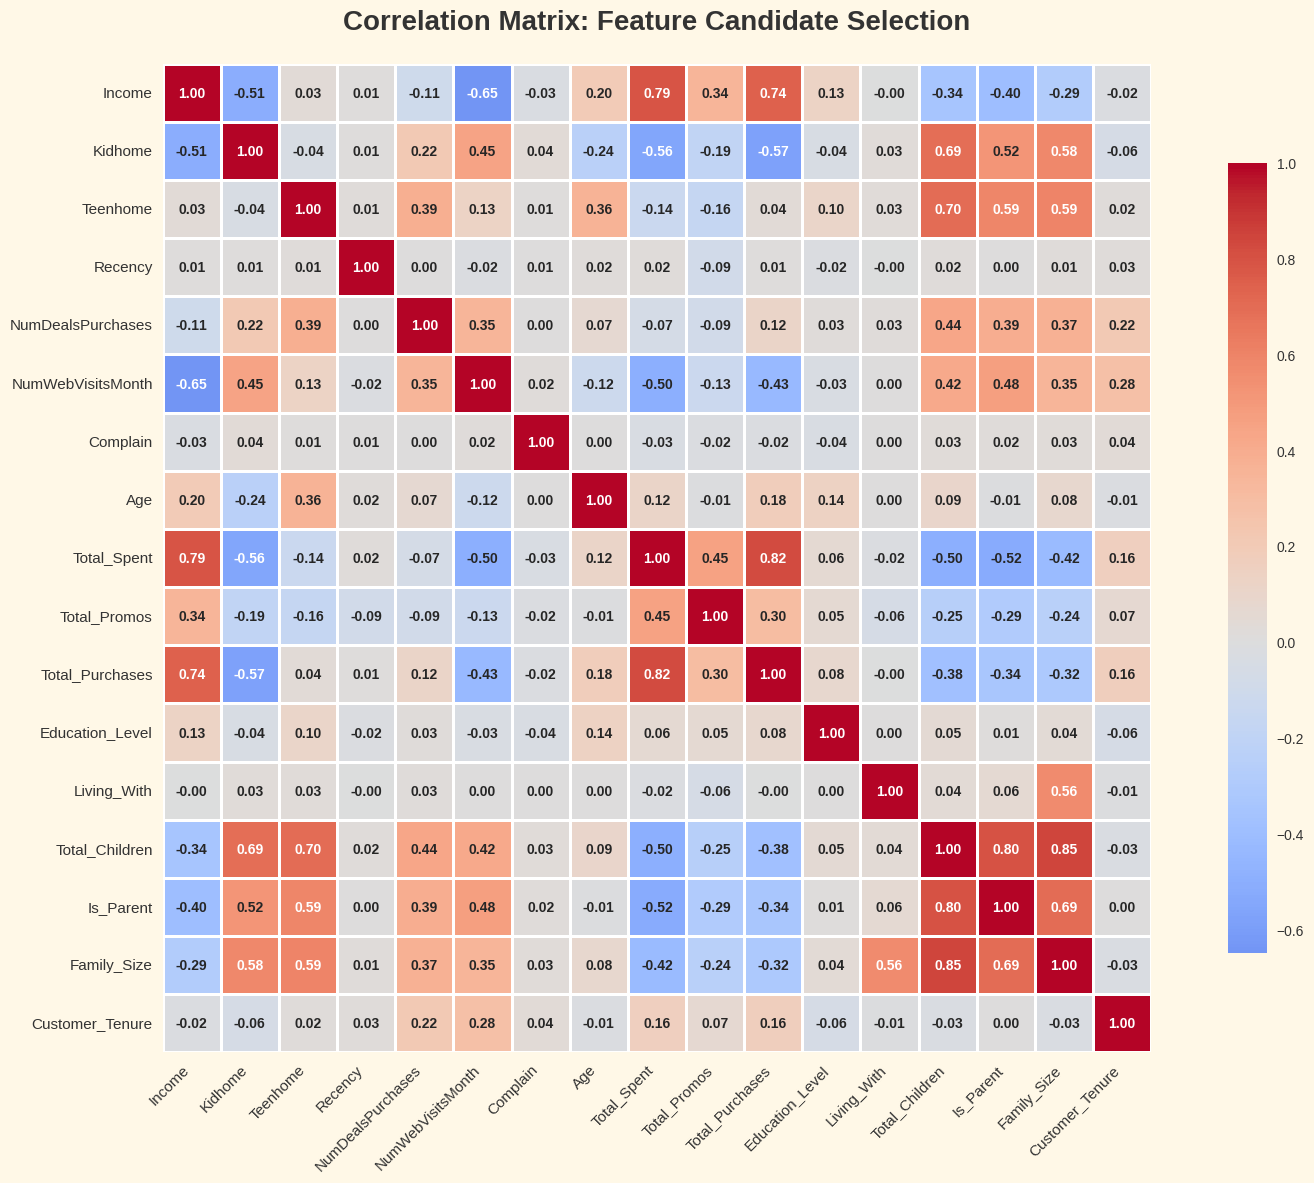


Pasangan Fitur dengan Korelasi Tertinggi (diurutkan)
Total_Children   Family_Size        0.849574
Total_Purchases  Total_Spent        0.823361
Total_Children   Is_Parent          0.799802
Total_Spent      Income             0.792740
Income           Total_Purchases    0.742691
dtype: float64


In [ ]:
# Heatmap untuk Membantu feature selection

# 1. Identifikasi kolom yang JELAS tidak digunakan untuk clustering
blacklist = [
    # --- Kelompok A: Administratif & Konstanta ---
    'ID', 'Z_CostContact', 'Z_Revenue',

    # --- Kelompok B: Kolom Asal (Sudah di-Engineering) ---
    'Education', 'Marital_Status',      # Sudah jadi Education_Level & Living_With
    'Dt_Customer',                      # Sudah jadi Customer_Tenure
    'Year_Birth',                       # Sudah jadi Age
    # 'Kidhome', 'Teenhome',              # Sudah jadi Total_Children

    # --- Kelompok C: Komponen Agregat  ---
    # Kita blacklist komponen penyusun karena sudah ada 'Total_Spent' & 'Total_Purchases'
    'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds',
    'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases',

    # --- Kelompok D: Komponen Promosi ---
    'AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'Response',

    # --- Kelompok E: Fitur dengan Korelasi Logis 1.0 ---
    # 'Is_Parent' # Biasanya korelasi sangat tinggi dengan Total_Children
]

# 2. Filter fitur numerik
numeric_features = df_clean.select_dtypes(include=[np.number]).columns
features_to_check = [col for col in numeric_features if col not in blacklist]

# ============================================================
# VISUALISASI HEATMAP
# ============================================================
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Konfigurasi Tema Global
plt.rcParams['figure.facecolor'] = '#FFF8E7'
plt.rcParams['axes.facecolor'] = '#FFF8E7'

plt.figure(figsize=(16, 12))

# Menghitung korelasi
corr_matrix = df_clean[features_to_check].corr()

# Plot Heatmap
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=1.0,
    linecolor='white',
    cbar_kws={"shrink": .8},
    square=True,
    annot_kws={"size": 10, "weight": "bold"}
)

plt.title("Correlation Matrix: Feature Candidate Selection",
          fontsize=20, fontweight='bold', pad=25, color='#333333')
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(fontsize=11)

plt.show()

# --- Identifikasi Redundansi Data --- Tambahan untuk menampilkan korelasi terurut
print("\n" + "="*50)
print("Pasangan Fitur dengan Korelasi Tertinggi (diurutkan)")
print("="*50)

# Mendapatkan pasangan korelasi unik dan mengurutkannya
corr_pairs = corr_matrix.unstack()
sorted_corr_pairs = corr_pairs.sort_values(ascending=False)

# Filter out self-correlations and duplicate pairs
unique_sorted_corr_pairs = sorted_corr_pairs[
    (sorted_corr_pairs < 1.0) & (sorted_corr_pairs > 0)
].drop_duplicates()

# Filter for high correlation (e.g., > 0.7 or any threshold deemed relevant)
high_corr_filtered = unique_sorted_corr_pairs[unique_sorted_corr_pairs.abs() > 0.7]

if not high_corr_filtered.empty:
    print(high_corr_filtered)
else:
    print("Tidak ditemukan pasangan fitur dengan korelasi di atas 0.7")


In [ ]:
len(features_to_check)

17

## Data PCA

## Check distribution and correlation aftermath

In [ ]:
# import matplotlib.pyplot as plt
# import seaborn as sns

# # 1. Heatmap Korelasi Final
# plt.figure(figsize=(12, 8))
# # sns.heatmap(X_final_df.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
# sns.heatmap(
#     X_final_df.corr(),
#     annot=True,
#     fmt=".2f",
#     cmap="coolwarm",
#     center=0,
#     linewidths=1.0,
#     linecolor='white',
#     cbar_kws={"shrink": .8},
#     square=True,
#     annot_kws={"size": 10, "weight": "bold"}
# )
# plt.title('Final Feature Correlation Matrix')
# plt.show()



In [ ]:
# # Get all column names from X_final_df
# all_features = X_final_df.columns

# # Determine grid size for subplots
# num_features = len(all_features)
# num_rows = (num_features + 2) // 3 # Roughly 3 columns per row
# num_cols = 3

# plt.figure(figsize=(num_cols * 5, num_rows * 4))
# plt.suptitle('Final Feature Distribution', fontsize=16, y=1.02)

# for i, col in enumerate(all_features):
#     plt.subplot(num_rows, num_cols, i + 1)
#     sns.histplot(X_final_df[col], kde=True, color='#682F2F', bins=30) # Using 30 bins for smoother histograms
#     plt.title(f'{col}', fontsize=12)
#     plt.xlabel('') # Remove x-label to reduce clutter
#     plt.ylabel('') # Remove y-label to reduce clutter

# plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust layout to make room for suptitle
# plt.show()

## 15 Fitur tanpa demografi

In [ ]:
# 15 Fitur tanpa demografi
#  # Define the final features for clustering
# features_pca = [

#    # 3. Perilaku Belanja Produk
#     "MntWines",
#     "MntFruits",
#     "MntMeatProducts",
#     "MntFishProducts",
#     "MntSweetProducts",
#     "MntGoldProds",
# # 4. Channel & Frekuensi Pembelian
#     "NumWebPurchases",
#     "NumCatalogPurchases",
#     "NumStorePurchases",
#     "NumWebVisitsMonth",

# # lifecycle
#    "Customer_Tenure",
#     "Recency",

#    # 5. Respons Promosi
#     "Total_Promos",
#     "NumDealsPurchases",

#   #
#    "Complain"
# ]
# print(f"Jumlah fitur yang akan dimasukkan ke PCA: {len(features_pca)}")

## 26 fitur

In [ ]:
df['Total_Spent'] = df[['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']].sum(axis=1)
df['Total_Purchases'] = df[['NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases']].sum(axis=1)

In [ ]:

# features_pca = [
# #      # 1. Demografi & Kapasitas (8 Fitur)
#     "Age",
#     "Income",
#     "Education_Level",
#     "Living_With",
#      "Kidhome",
#      "Teenhome",

# #     # 2. Perilaku Belanja Produk (7 Fitur)
#     "MntWines",
#     "MntFruits",
#     "MntMeatProducts",
#     "MntFishProducts",
#     "MntSweetProducts",
#     "MntGoldProds",


# #     # 3. Saluran & Frekuensi Pembelian (6 Fitur)
#     "NumWebPurchases",
#     "NumCatalogPurchases",
#     "NumStorePurchases",
#     "NumWebVisitsMonth",

#     #
#     "Recency",
#      "Customer_Tenure",

# #     # 4. Respons Kampanye & Promosi (8 Fitur)
#     "AcceptedCmp1",
#     "AcceptedCmp2",
#     "AcceptedCmp3",
#     "AcceptedCmp4",
#     "AcceptedCmp5",
#     "Response",
#     "NumDealsPurchases",

# #     # 5. Fitur Dasar & Lainnya (3 Fitur)
#     "Complain"

# ]

# print(f"Jumlah fitur yang akan dimasukkan ke PCA: {len(features_pca)}")



In [ ]:

# features_pca = [
# #      # 1. Demografi & Kapasitas (8 Fitur)
#     "Age",
#     "Income",
#     "Education_Level",
#     "Living_With",
#      "Kidhome",
#      "Teenhome",

# # #     # 2. Perilaku Belanja Produk (7 Fitur)
# #     "MntWines",
# #     "MntFruits",
# #     "MntMeatProducts",
# #     "MntFishProducts",
# #     "MntSweetProducts",
# #     "MntGoldProds",
#     "Total_Spent",
#     # "Total_Purchases",

# # #     # 3. Saluran & Frekuensi Pembelian (6 Fitur)
# #     "NumWebPurchases",
#     "NumCatalogPurchases",
#     "NumStorePurchases",
#     "NumWebVisitsMonth",

#     #
#     # "Recency",
#      "Customer_Tenure",

# #     # 4. Respons Kampanye & Promosi (8 Fitur)
#     "AcceptedCmp1",
#     "AcceptedCmp2",
#     "AcceptedCmp3",
#     "AcceptedCmp4",
#     "AcceptedCmp5",
#     "Response",
#     "NumDealsPurchases",

# #     # 5. Fitur Dasar & Lainnya (3 Fitur)
#     # "Complain"

# ]

# print(f"Jumlah fitur yang akan dimasukkan ke PCA: {len(features_pca)}")




In [ ]:
# features_pca = [
#     # Demografi
#     "Age",
#     "Income",
#     "Customer_Tenure",
#     "Kidhome",
#     "Teenhome",

#     # Product spending
#     "MntWines",
#     "MntFruits",
#     "MntMeatProducts",
#     "MntFishProducts",
#     "MntSweetProducts",
#     "MntGoldProds",

#     # Purchase channels
#     "NumWebPurchases",
#     "NumCatalogPurchases",
#     "NumStorePurchases",

#     # Behaviour
#     "NumDealsPurchases",
#     "Total_Promos",
#     "Recency",

#     # Satisfaction
#     "Complain"
# ]
# print(f"Jumlah fitur yang akan dimasukkan ke PCA: {len(features_pca)}")

## 21 Fitur


In [ ]:
## 21 Fitur

features_pca = [
'Age', 'Income', 'Education_Level', 'Living_With', 'Customer_Tenure', 'Kidhome', 'Teenhome',
    'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds',
    'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'Recency',
    'Total_Promos', 'NumDealsPurchases', 'Complain']
print(f"Jumlah fitur yang akan dimasukkan ke PCA: {len(features_pca)}")

Jumlah fitur yang akan dimasukkan ke PCA: 21


Feature Selection Justification for PCA

Pemilihan fitur untuk analisis clustering dilakukan dengan mempertimbangkan dua prinsip utama:

1. **Menghindari redundansi informasi** agar setiap fitur memberikan kontribusi yang berbeda dalam membentuk cluster.
2. **Mempertahankan dimensi perilaku customer yang penting** sehingga hasil segmentasi dapat diinterpretasikan secara bisnis.

Berdasarkan analisis korelasi dan pemahaman domain bisnis, fitur yang digunakan dikelompokkan ke dalam beberapa dimensi utama berikut.

---

1. Demografi & Kapasitas Customer

   Fitur yang digunakan:

   - Age  
   - Income  
   - Education_Level  
   - Living_With  
   - Customer_Tenure  

   Fitur demografi digunakan untuk menangkap karakteristik dasar pelanggan yang dapat memengaruhi perilaku konsumsi dan daya beli. Variabel seperti **Income** merepresentasikan kemampuan finansial, sedangkan **Age**, **Education_Level**, dan **Living_With** membantu menjelaskan perbedaan gaya hidup dan preferensi konsumsi antar pelanggan.

   Fitur-fitur ini memiliki korelasi relatif rendah dengan fitur perilaku transaksi, sehingga dapat menambahkan **dimensi informasi baru** dalam proses clustering.

---

2. Struktur Keluarga

   Fitur yang digunakan:

   - Family_Size  
   - Kidhome  
   - Teenhome  

   Struktur keluarga memengaruhi pola konsumsi rumah tangga. Misalnya, pelanggan dengan anak cenderung memiliki pola belanja berbeda dibandingkan pelanggan tanpa anak.

   Fitur seperti **Total_Children** dan **Is_Parent** tidak digunakan karena memiliki korelasi tinggi dengan fitur lain dan membawa informasi yang hampir sama. Dengan mempertahankan **Kidhome**, **Teenhome**, dan **Family_Size**, informasi tentang komposisi keluarga tetap terwakili tanpa menimbulkan redundansi fitur.

---

3. Perilaku Belanja Produk

   Fitur yang digunakan:

   - MntWines  
   - MntFruits  
   - MntMeatProducts  
   - MntFishProducts  
   - MntSweetProducts  
   - MntGoldProds  

   Fitur ini menggambarkan **preferensi konsumsi produk** pelanggan.

   Fitur agregasi seperti **Total_Spent** tidak digunakan karena merupakan penjumlahan langsung dari seluruh kategori produk. Jika fitur agregasi tersebut digunakan bersamaan dengan fitur penyusunnya, maka dimensi pengeluaran akan menjadi terlalu dominan dalam perhitungan jarak pada algoritma clustering.

   Dengan menggunakan **kategori produk secara terpisah**, model dapat menangkap variasi preferensi pelanggan, seperti pelanggan yang lebih banyak membeli produk premium, produk makanan tertentu, atau memiliki pola konsumsi yang berbeda.

   Selain itu, penggunaan fitur penyusun memungkinkan model mendeteksi **pola konsumsi yang lebih spesifik**. Misalnya, dua pelanggan dapat memiliki nilai **Total_Spent** yang sama, tetapi komposisi pengeluarannya berbeda (misalnya satu lebih banyak membeli wine, sementara yang lain lebih banyak membeli meat products). Jika hanya menggunakan fitur agregasi, perbedaan perilaku ini tidak dapat terlihat dalam proses clustering.

---

4. Channel & Frekuensi Pembelian

   Fitur yang digunakan:

   - NumWebPurchases  
   - NumCatalogPurchases  
   - NumStorePurchases  
   - NumWebVisitsMonth  
   - Recency  

   Fitur ini menggambarkan **bagaimana pelanggan berinteraksi dengan berbagai channel penjualan** serta tingkat aktivitas mereka.

   Fitur agregasi seperti **Total_Purchases** tidak digunakan karena merupakan penjumlahan dari seluruh channel pembelian. Jika digunakan bersamaan dengan channel individual, fitur tersebut akan menciptakan korelasi tinggi dan mengurangi kontribusi masing-masing channel dalam membentuk cluster.

   Dengan mempertahankan channel secara terpisah, segmentasi dapat mengidentifikasi tipe pelanggan seperti **online shoppers**, **store buyers**, atau pelanggan yang aktif melakukan browsing tetapi jarang melakukan pembelian.

   Pendekatan ini memberikan informasi perilaku yang lebih kaya dibandingkan hanya menggunakan jumlah total pembelian.

---

5. Respons terhadap Promosi

   Fitur yang digunakan:

   - Total_Promos  
   - NumDealsPurchases  

   Dimensi ini digunakan untuk menangkap **sensitivitas pelanggan terhadap promosi dan diskon**.

   Variabel kampanye individu seperti **AcceptedCmp1–AcceptedCmp5** dan **Response** tidak digunakan karena memiliki distribusi yang sangat jarang (sparse) dan membawa informasi yang mirip satu sama lain. Sebagai gantinya, **Total_Promos** digunakan untuk merepresentasikan total respons pelanggan terhadap kampanye secara keseluruhan.

---

Alasan Menggunakan Fitur Penyusun daripada Fitur Agregasi

Beberapa fitur agregasi seperti:

- Total_Spent  
- Total_Purchases  
- Total_Children  
- Is_Parent  

tidak digunakan karena merupakan **kombinasi langsung dari fitur lain**. Jika fitur agregasi digunakan bersamaan dengan fitur penyusunnya, maka informasi yang sama akan muncul berulang kali dalam dataset.

Dalam algoritma clustering berbasis jarak seperti **K-Means**, kondisi ini dapat menyebabkan dimensi tertentu menjadi **terlalu dominan** dan memengaruhi pembentukan cluster secara tidak proporsional.

Selain itu, fitur agregasi juga **menghilangkan variasi perilaku yang lebih detail**. Sebagai contoh, dua pelanggan dapat memiliki nilai *Total_Spent* yang sama tetapi dengan komposisi produk yang berbeda. Dengan menggunakan fitur penyusun secara langsung, model dapat menangkap variasi perilaku tersebut sehingga cluster yang dihasilkan menjadi lebih informatif.

Dengan menggunakan **fitur penyusun**, model dapat:

- mempertahankan variasi perilaku pelanggan yang lebih detail
- mengurangi korelasi antar fitur
- mencegah dominasi satu dimensi dalam perhitungan jarak
- menghasilkan cluster yang lebih seimbang dan mudah diinterpretasikan

---

Peran Fitur Agregasi dan Fitur Turunan Lainnya

Meskipun tidak digunakan dalam proses clustering, fitur agregasi seperti **Total_Spent**, **Total_Purchases**, atau **Total_Children** tetap memiliki nilai analitis yang penting.

Fitur-fitur tersebut dapat digunakan pada tahap **analisis lanjutan setelah cluster terbentuk**, seperti:

- **Profiling cluster** untuk memahami karakteristik setiap segmen pelanggan secara lebih ringkas
- **Business interpretation**, misalnya membandingkan total pengeluaran rata-rata antar cluster
- **Visualisasi dan reporting**, karena metrik agregasi biasanya lebih mudah dipahami oleh stakeholder bisnis

Dengan demikian, fitur agregasi tetap bermanfaat sebagai **variabel interpretatif**, meskipun tidak digunakan secara langsung dalam proses pembentukan cluster.

---

Ringkasan

Feature set yang digunakan dirancang untuk merepresentasikan beberapa dimensi utama pelanggan:

- karakteristik demografi
- struktur keluarga
- preferensi produk
- channel pembelian
- sensitivitas terhadap promosi

Pendekatan ini membantu menghasilkan segmentasi pelanggan yang tidak hanya stabil secara statistik, tetapi juga **bermakna secara bisnis dan mudah diinterpretasikan pada tahap analisis lanjutan**.

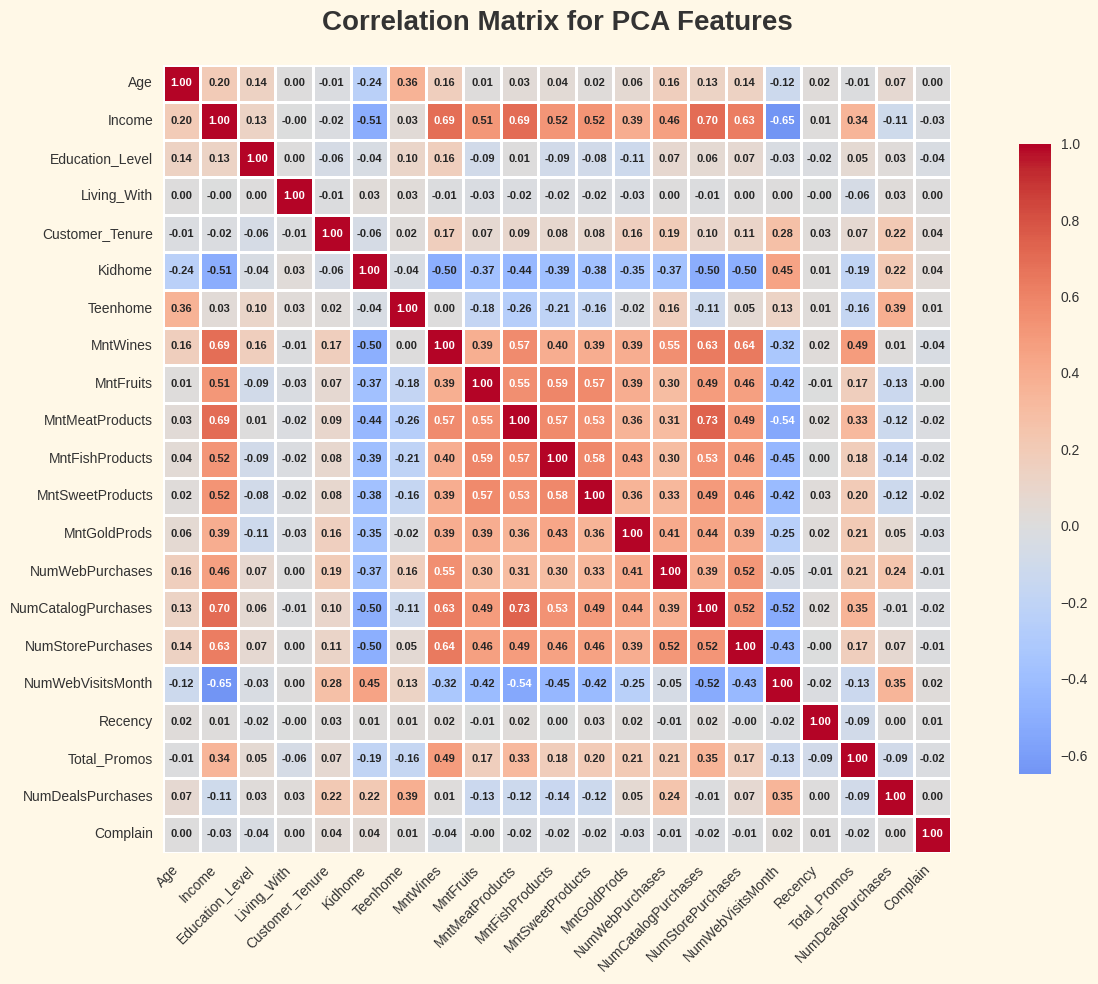


Pasangan Fitur dengan Korelasi Tertinggi (> 0.70) di antara Fitur PCA
MntMeatProducts  NumCatalogPurchases    0.733787
dtype: float64


In [ ]:
# ============================================================
# VISUALISASI HEATMAP UNTUK FITUR PCA
# ============================================================
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Pastikan df_clean sudah tersedia dan features_pca sudah didefinisikan
# df_clean = df_clean # Diasumsikan df_clean sudah ada dari sel sebelumnya
# features_pca = features_pca # Diasumsikan features_pca sudah ada dari sel sebelumnya

plt.rcParams['figure.facecolor'] = '#FFF8E7'
plt.rcParams['axes.facecolor'] = '#FFF8E7'

plt.figure(figsize=(14, 10))

# Menghitung matriks korelasi untuk fitur-fitur yang dipilih untuk PCA
corr_matrix_pca = df_clean[features_pca].corr()

# Plot Heatmap
sns.heatmap(
    corr_matrix_pca,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=1.0,
    linecolor='white',
    cbar_kws={"shrink": .8},
    square=True,
    annot_kws={"size": 8, "weight": "bold"}
)

plt.title("Correlation Matrix for PCA Features",
          fontsize=20, fontweight='bold', pad=25, color='#333333')
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)

plt.tight_layout()
plt.show()

# --- Identifikasi Redundansi Data --- Tambahan untuk menampilkan korelasi terurut
print("\n" + "="*50)
print("Pasangan Fitur dengan Korelasi Tertinggi (> 0.70) di antara Fitur PCA")
print("="*50)

# Mendapatkan pasangan korelasi unik dan mengurutkannya
corr_pairs_pca = corr_matrix_pca.unstack()
sorted_corr_pairs_pca = corr_pairs_pca.sort_values(ascending=False)

# Filter out self-correlations and duplicate pairs
unique_sorted_corr_pairs_pca = sorted_corr_pairs_pca[
    (sorted_corr_pairs_pca < 1.0) & (sorted_corr_pairs_pca > 0)
].drop_duplicates()

# Filter for high correlation (e.g., > 0.7 or any threshold deemed relevant)
high_corr_filtered_pca = unique_sorted_corr_pairs_pca[unique_sorted_corr_pairs_pca.abs() > 0.7]

if not high_corr_filtered_pca.empty:
    print(high_corr_filtered_pca)
else:
    print("Tidak ditemukan pasangan fitur dengan korelasi di atas 0.7")

In [ ]:
import numpy as np

# Data for PCA (re-creating it here as this cell is empty and previous one defined it)
df_for_pca_new = df_clean[features_pca].copy()

# Identify skewed features suitable for log transformation (skewness > 1.0 and not binary/ordinal with few categories)
skewed_features_for_log_transform = [
    'Income',
    'MntWines',
    'MntFruits',
    'MntMeatProducts',
    'MntFishProducts',
    'MntSweetProducts',
    'MntGoldProds',
    'NumDealsPurchases',
    'NumWebPurchases',
    'NumCatalogPurchases'
]

print("Applying log1p transformation to the following skewed features:")
for feature in skewed_features_for_log_transform:
    if feature in df_for_pca_new.columns:
        df_for_pca_new[feature] = np.log1p(df_for_pca_new[feature])
        print(f"- {feature}")
    else:
        print(f"- {feature} (not found in current feature set)")

print("\nLog transformation applied. Now proceed with scaling and PCA using 'df_for_pca_new'.")


Applying log1p transformation to the following skewed features:
- Income
- MntWines
- MntFruits
- MntMeatProducts
- MntFishProducts
- MntSweetProducts
- MntGoldProds
- NumDealsPurchases
- NumWebPurchases
- NumCatalogPurchases

Log transformation applied. Now proceed with scaling and PCA using 'df_for_pca_new'.


In [ ]:
# Data for PCA
df_for_pca_new = df_clean[features_pca ].copy()

# Scaling
scaler_new_pca = RobustScaler()
X_scaled_new_pca = scaler_new_pca.fit_transform(df_for_pca_new)

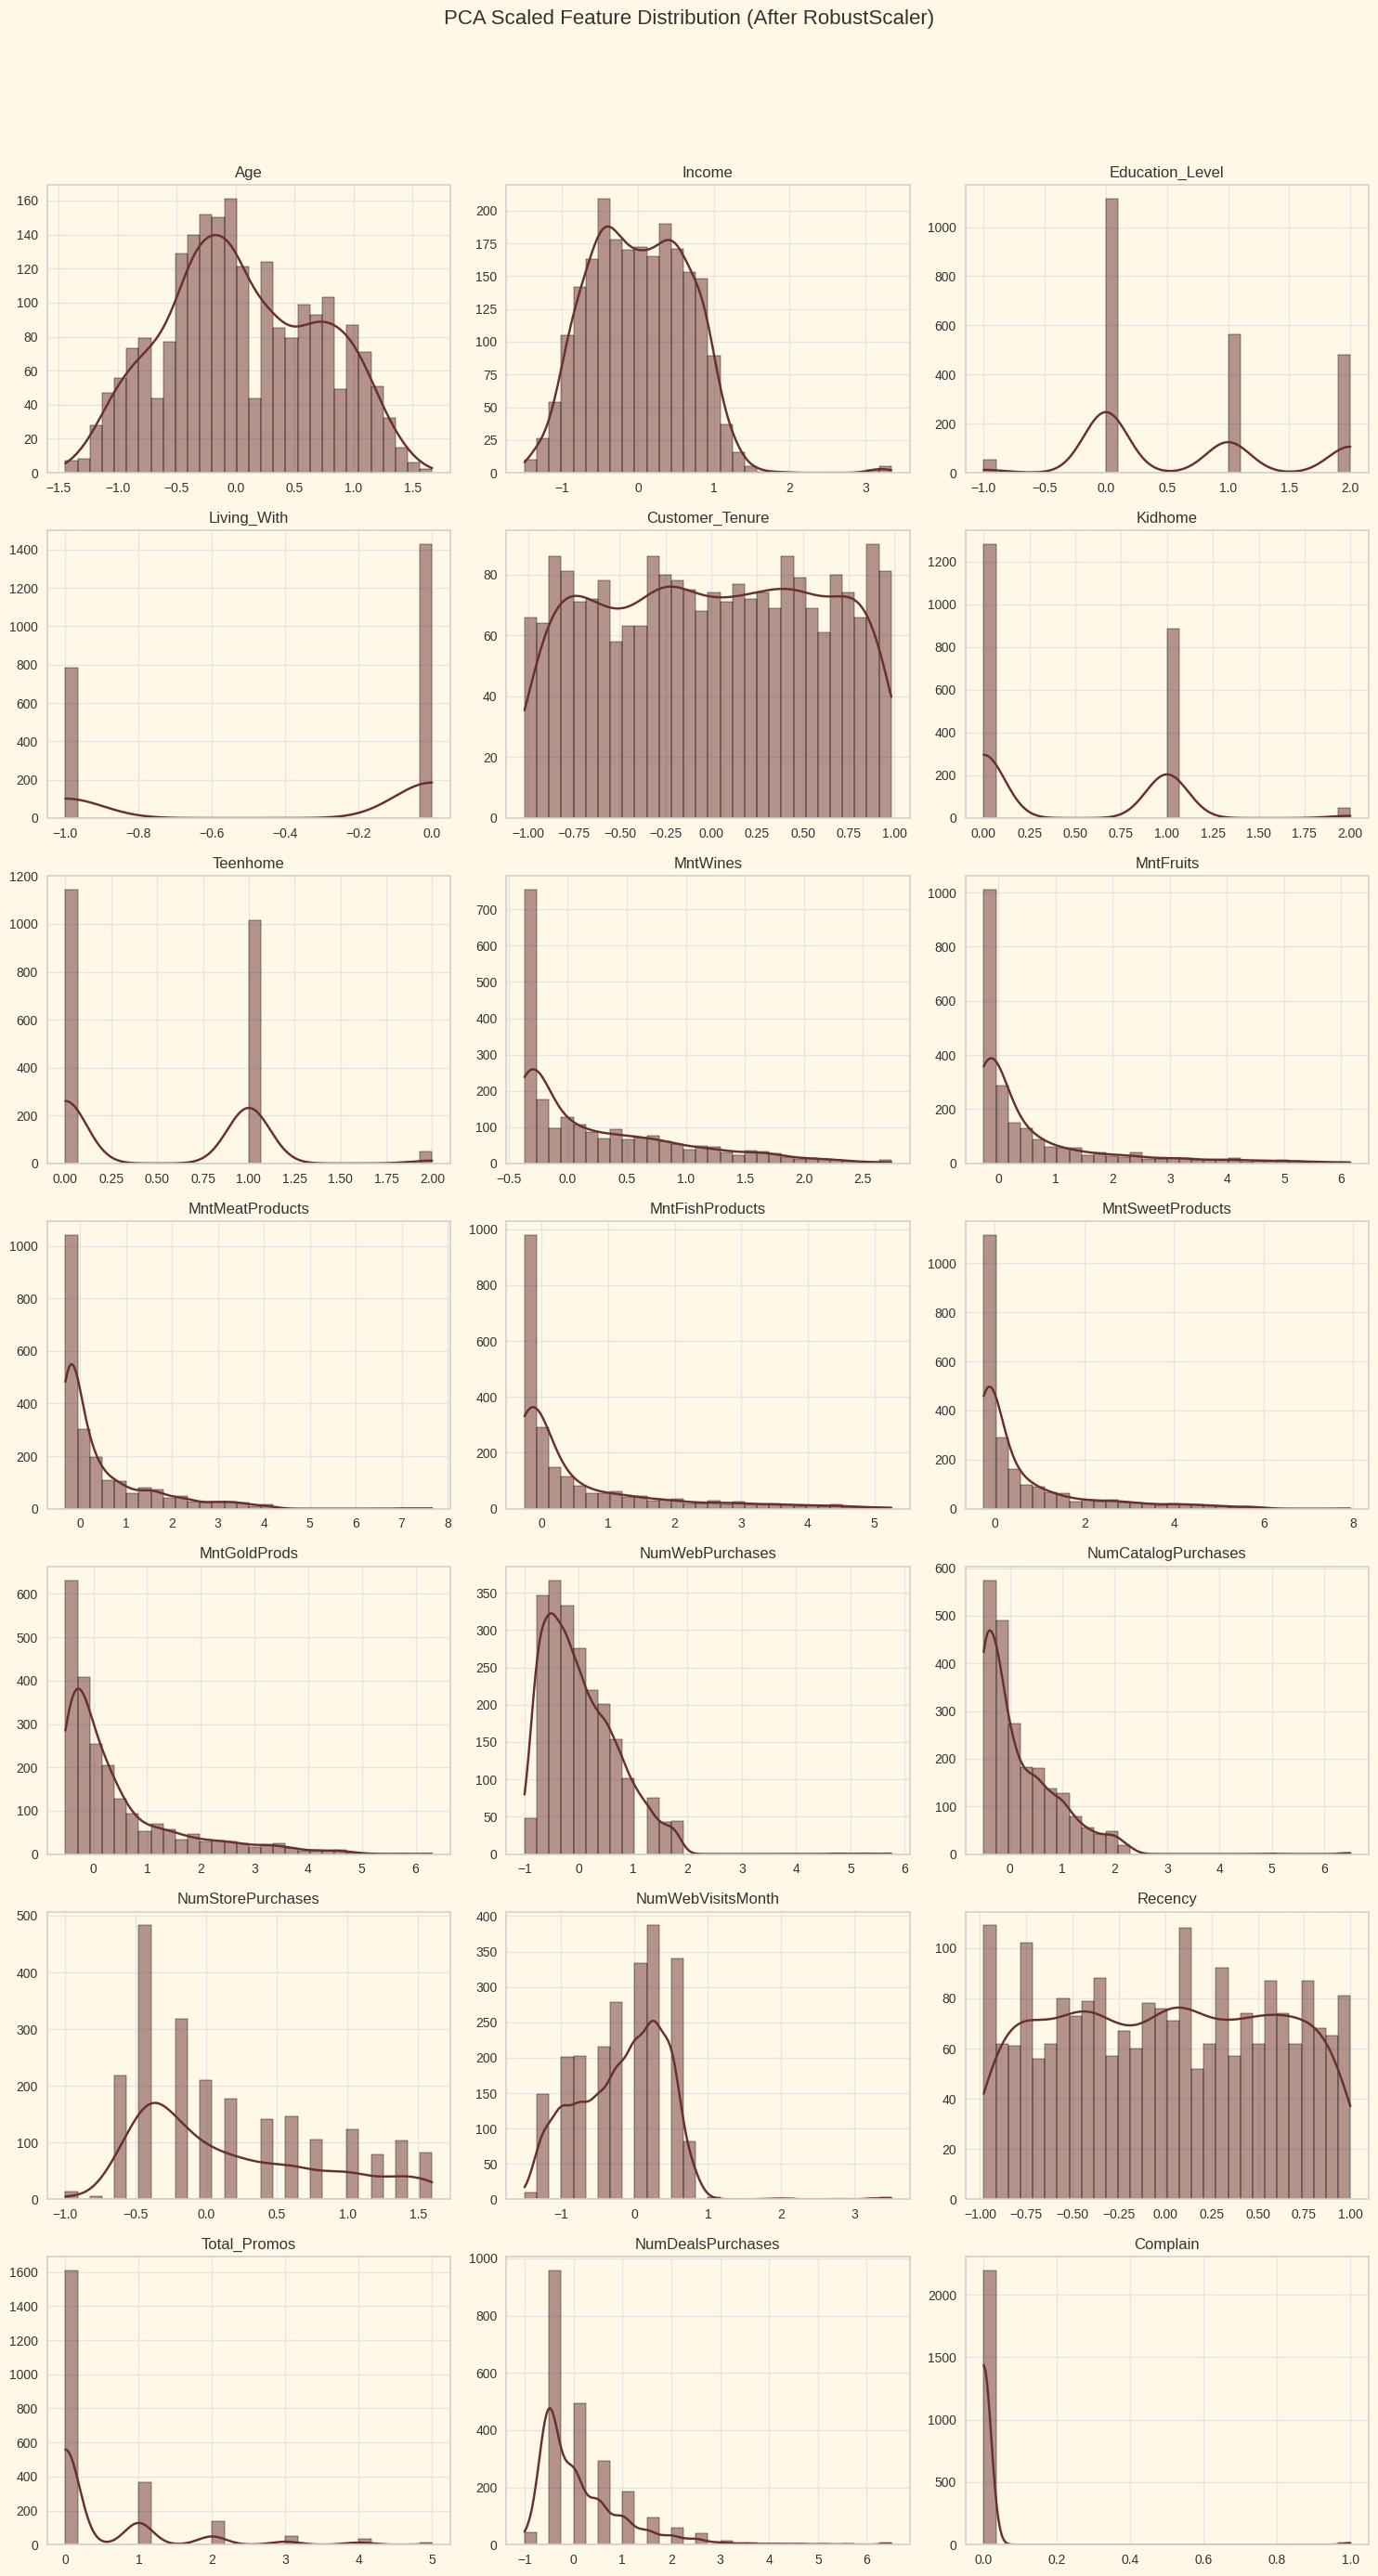

In [ ]:
df_scaled_pca_plot = pd.DataFrame(X_scaled_new_pca, columns=features_pca)

# Get all column names from df_scaled_pca_plot
all_features_pca_scaled = df_scaled_pca_plot.columns

# Determine grid size for subplots
num_features = len(all_features_pca_scaled)
num_rows = (num_features + 2) // 3 # Roughly 3 columns per row
num_cols = 3

plt.figure(figsize=(num_cols * 5, num_rows * 4))
plt.suptitle('PCA Scaled Feature Distribution (After RobustScaler)', fontsize=16, y=1.02)

for i, col in enumerate(all_features_pca_scaled):
    plt.subplot(num_rows, num_cols, i + 1)
    sns.histplot(df_scaled_pca_plot[col], kde=True, color='#682F2F', bins=30)
    plt.title(f'{col}', fontsize=12)
    plt.xlabel('') # Remove x-label to reduce clutter
    plt.ylabel('') # Remove y-label to reduce clutter

plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust layout to make room for suptitle
plt.show()

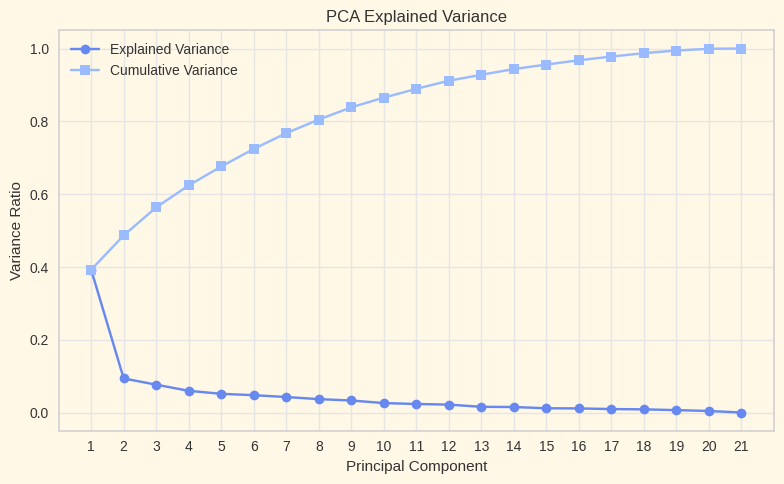


--- PCA Explained Variance (Table Format) ---


,Principal Component,Explained Variance Ratio,Cumulative Explained Variance
0,PC1,0.392703,0.392703
1,PC2,0.094124,0.486826
2,PC3,0.077163,0.563989
3,PC4,0.060216,0.624204
4,PC5,0.051969,0.676174
5,PC6,0.048236,0.724410
6,PC7,0.043195,0.767604
7,PC8,0.037395,0.804999
8,PC9,0.033680,0.838679
9,PC10,0.026554,0.865233


In [ ]:


# PCA exploratory (tanpa menentukan jumlah komponen)
pca_explore = PCA()
X_pca_explore = pca_explore.fit_transform(X_scaled_new_pca)

# Explained variance
explained_var = pca_explore.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)

# Plot
plt.figure(figsize=(8,5))

plt.plot(range(1, len(explained_var)+1), explained_var, marker='o', label='Explained Variance')
plt.plot(range(1, len(cumulative_var)+1), cumulative_var, marker='s', label='Cumulative Variance')

plt.xlabel('Principal Component')
plt.ylabel('Variance Ratio')
plt.title('PCA Explained Variance')
plt.xticks(range(1, len(explained_var)+1))

plt.legend()
plt.grid(True)

plt.show()

# Display explained variance in a table
pca_summary_df = pd.DataFrame({
    'Principal Component': [f'PC{i+1}' for i in range(len(explained_var))],
    'Explained Variance Ratio': explained_var,
    'Cumulative Explained Variance': cumulative_var
})
print("\n--- PCA Explained Variance (Table Format) ---")
display(pca_summary_df)

### Loading

In [ ]:
# Initialize PCA for clustering
pca_clustering_new = PCA(n_components=2, random_state=42)
X_pca_clustering_new = pca_clustering_new.fit_transform(X_scaled_new_pca)

# Visualization data (PC1 & PC2)
X_pca_visual_new = X_pca_clustering_new[:, :2]

# Keep compatibility
pca_visual_new = pca_clustering_new

print("Data Preparation with PCA Complete!")
print(f"Shape PCA clustering: {X_pca_clustering_new.shape}")
print(f"Shape PCA visualization: {X_pca_visual_new.shape}")

pd.set_option('display.max_columns', None)

display(
    pd.DataFrame(
        X_pca_clustering_new,
        columns=[f'PC{i+1}' for i in range(X_pca_clustering_new.shape[1])]
    ).head()
)

# Output variables for clustering pipeline
X_clustering_data_pca = X_pca_clustering_new
X_visual_data_pca = X_pca_visual_new

Data Preparation with PCA Complete!
Shape PCA clustering: (2212, 2)
Shape PCA visualization: (2212, 2)


,PC1,PC2
0,4.518971,0.170711
1,-2.124221,-0.613303
2,1.326256,-0.543186
3,-2.085637,-1.039788
4,-0.137843,0.340252


In [ ]:
loadings = pd.DataFrame(pca_clustering_new.components_.T, columns=['PC1', 'PC2'], index=features_pca)
print(loadings.sort_values(by='PC1', ascending=False))

                          PC1       PC2
MntFruits            0.435149 -0.210428
MntSweetProducts     0.433484 -0.188339
MntFishProducts      0.396632 -0.147567
MntMeatProducts      0.353131 -0.004314
MntGoldProds         0.280709  0.368747
NumCatalogPurchases  0.238261  0.125375
Income               0.213079  0.085418
MntWines             0.197329  0.235519
NumStorePurchases    0.183483  0.158687
NumWebPurchases      0.142389  0.318862
Total_Promos         0.137188  0.141504
Customer_Tenure      0.027739  0.153398
Age                  0.023883  0.148294
Recency              0.002558 -0.001445
Complain            -0.001028 -0.001128
Living_With         -0.006004  0.005856
Education_Level     -0.016947  0.161953
Teenhome            -0.044485  0.226377
NumDealsPurchases   -0.060080  0.628340
Kidhome             -0.131348 -0.035537
NumWebVisitsMonth   -0.153425  0.134193


In [ ]:
loadings = pd.DataFrame(pca_clustering_new.components_.T, columns=['PC1', 'PC2'], index=features_pca)
print(loadings.sort_values(by='PC2', ascending=False))

                          PC1       PC2
NumDealsPurchases   -0.060080  0.628340
MntGoldProds         0.280709  0.368747
NumWebPurchases      0.142389  0.318862
MntWines             0.197329  0.235519
Teenhome            -0.044485  0.226377
Education_Level     -0.016947  0.161953
NumStorePurchases    0.183483  0.158687
Customer_Tenure      0.027739  0.153398
Age                  0.023883  0.148294
Total_Promos         0.137188  0.141504
NumWebVisitsMonth   -0.153425  0.134193
NumCatalogPurchases  0.238261  0.125375
Income               0.213079  0.085418
Living_With         -0.006004  0.005856
Complain            -0.001028 -0.001128
Recency              0.002558 -0.001445
MntMeatProducts      0.353131 -0.004314
Kidhome             -0.131348 -0.035537
MntFishProducts      0.396632 -0.147567
MntSweetProducts     0.433484 -0.188339
MntFruits            0.435149 -0.210428


# Clustering

## K Optimal for PCA-Transformed Data

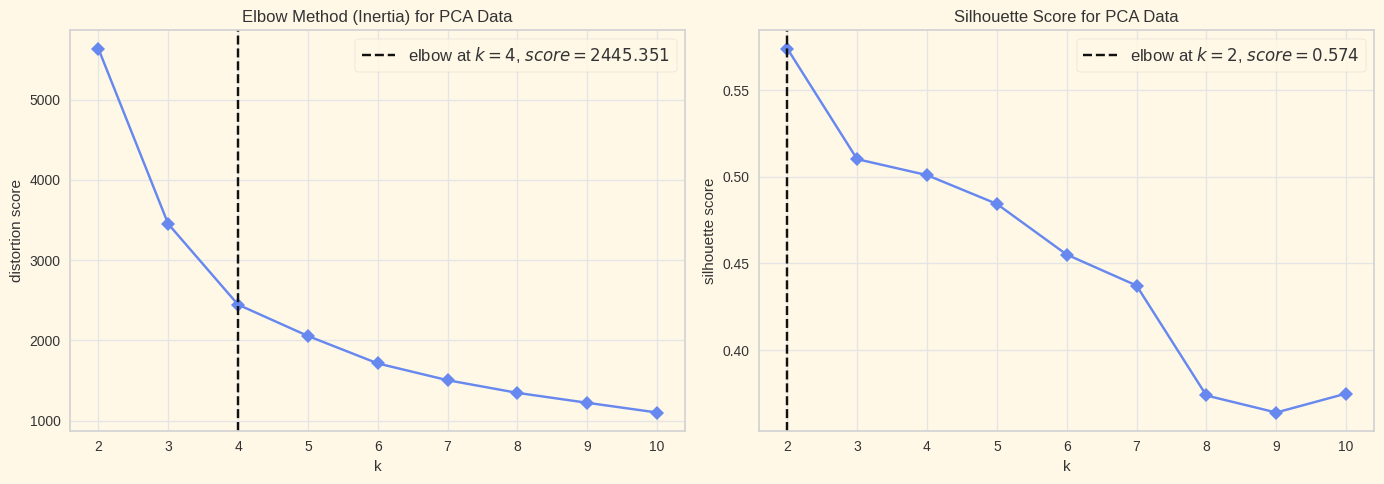

In [ ]:
from yellowbrick.cluster import KElbowVisualizer
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Model KMeans
model = KMeans(init='k-means++', random_state=42, n_init=10)

# Membuat figure dengan 1 baris 2 kolom
fig, ax = plt.subplots(1, 2, figsize=(14,5))

# Elbow Method (Inertia) for PCA data
visualizer_elbow_pca = KElbowVisualizer(
    model,
    k=(2,11),
    timings=False,
    ax=ax[0]
)
visualizer_elbow_pca.fit(X_clustering_data_pca) # Using PCA-transformed data
visualizer_elbow_pca.finalize()
ax[0].set_title('Elbow Method (Inertia) for PCA Data')

# Silhouette Score for PCA data
visualizer_silhouette_pca = KElbowVisualizer(
    model,
    k=(2,11),
    metric='silhouette',
    timings=False,
    ax=ax[1]
)
visualizer_silhouette_pca.fit(X_clustering_data_pca) # Using PCA-transformed data
visualizer_silhouette_pca.finalize()
ax[1].set_title('Silhouette Score for PCA Data')

plt.tight_layout()
plt.show()


## K-Means

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, silhouette_samples

import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.cm as cm

import numpy as np
import pandas as pd

def perform_kmeans_clustering_and_profiling(
    data_for_clustering,
    data_for_visual_2d_pca,
    df_original_clean,
    df_scaled_for_snake_plot,
    n_clusters,
    feature_names_for_profiling,
    method_prefix
):
    """
    Performs K-Means clustering, evaluates it, and profiles the resulting clusters.

    Args:
        data_for_clustering (np.ndarray or pd.DataFrame): The data to apply K-Means on.
        data_for_visual_2d_pca (np.ndarray or pd.DataFrame): 2-component PCA data for visualization.
        df_original_clean (pd.DataFrame): The original clean DataFrame.
        df_scaled_for_snake_plot (pd.DataFrame): The DataFrame of scaled features for snake plot.
        n_clusters (int): Number of clusters for K-Means.
        feature_names_for_profiling (list): List of feature names for profiling.
        method_prefix (str): Prefix for plot titles and cluster column name.
    """

    print(f"\n{'='*50}")
    print(f"--- Starting {method_prefix} Clustering ---")
    print(f"{'='*50}")

    # 1. Perform K-Means Clustering
    kmeans_model = KMeans(n_clusters=n_clusters, init='k-means++', random_state=42, n_init=10)
    cluster_labels = kmeans_model.fit_predict(data_for_clustering)

    # Add cluster labels to original and scaled dataframes
    cluster_col_name = f'{method_prefix.replace(" ", "_")}_Cluster'
    df_original_clean[cluster_col_name] = cluster_labels
    df_scaled_for_snake_plot[cluster_col_name] = cluster_labels

    print(f"K-Means Clustering applied with {n_clusters} clusters.")

    # 2. Technical Evaluation
    s_score = silhouette_score(data_for_clustering, cluster_labels)
    db_index = davies_bouldin_score(data_for_clustering, cluster_labels)

    print(f"\n--- Technical Evaluation ({method_prefix} Clustering) ---")
    print(f"Overall Silhouette Score: {s_score:.4f}")
    print(f"Davies-Bouldin Index: {db_index:.4f} (Lower is better)")

    # 3. Visualizations
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

    # 3.1. 2D PCA Plot
    df_pca_plot = pd.DataFrame(data=data_for_visual_2d_pca, columns=['PC1', 'PC2'])
    df_pca_plot['Cluster'] = cluster_labels

    sns.scatterplot(x='PC1', y='PC2', hue='Cluster', data=df_pca_plot, palette='viridis', s=70, alpha=0.8, ax=ax1)
    ax1.set_title(f'{method_prefix} Clusters Visualization (PCA 2D)', fontsize=15, fontweight='bold')
    ax1.set_xlabel('Principal Component 1 (PC1)')
    ax1.set_ylabel('Principal Component 2 (PC2)')
    ax1.grid(True, linestyle='--', alpha=0.5)

    # 3.2. Silhouette Plot
    sample_silhouette_values = silhouette_samples(data_for_clustering, cluster_labels)
    y_lower = 10
    for i in range(n_clusters):
        ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]
        ith_cluster_silhouette_values.sort()

        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i

        color = cm.nipy_spectral(float(i) / n_clusters)
        ax2.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_silhouette_values,
                          facecolor=color, edgecolor=color, alpha=0.7)
        ax2.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
        y_lower = y_upper + 10

    ax2.axvline(x=s_score, color="red", linestyle="--")
    ax2.set_title(f"Silhouette Plot per Cluster ({method_prefix})", fontsize=15, fontweight='bold')
    ax2.set_xlabel("Silhouette Coefficient")
    ax2.set_ylabel("Cluster Label")

    plt.tight_layout()
    plt.show()

    # 4. Profiling (Cluster Summary and Snake Plot)
    cluster_summary = df_original_clean.groupby(cluster_col_name)[feature_names_for_profiling].mean().T
    print(f"\nRata-rata Karakteristik per {method_prefix} Cluster:\n")
    display(cluster_summary)

    # Snake Plot
    df_melt = pd.melt(df_scaled_for_snake_plot, id_vars=[cluster_col_name], var_name='Feature', value_name='Value')
    plt.figure(figsize=(15, 7))
    sns.lineplot(x='Feature', y='Value', hue=cluster_col_name, data=df_melt, marker='o', palette='viridis')
    plt.title(f'Snake Plot: Relative Characteristics ({method_prefix} Cluster DNA)', fontsize=15, fontweight='bold')
    plt.xticks(rotation=45, ha='right')
    plt.axhline(0, color='black', linestyle='--', alpha=0.5)
    plt.grid(True, alpha=0.3)

    plt.show()

    # Cluster Counts
    cluster_counts = df_original_clean[cluster_col_name].value_counts().sort_index()
    plt.figure(figsize=(8, 6))
    sns.barplot(x=cluster_counts.index, y=cluster_counts.values, hue=cluster_counts.index, palette='viridis', legend=False)
    plt.title(f'Distribusi Jumlah Anggota per {method_prefix} Cluster', fontsize=14)
    plt.xlabel('Cluster', fontsize=12)
    plt.ylabel('Jumlah Anggota', fontsize=12)
    plt.xticks(rotation=0)
    for index, value in enumerate(cluster_counts.values):
        plt.text(index, value + 0.5, str(value), ha='center', va='bottom', fontsize=10)
    plt.tight_layout()
    plt.show()

    print(f"\nJumlah Anggota per {method_prefix} Cluster:\n")
    print(cluster_counts)
    print(f"\n{'='*50}")
    print(f"--- {method_prefix} Clustering Complete ---")
    print(f"{'='*50}")

In [ ]:
n_cluster = 4


### Running K-Means Clustering WITH PCA ###

--- Starting PCA-based K-Means Clustering ---
K-Means Clustering applied with 4 clusters.

--- Technical Evaluation (PCA-based K-Means Clustering) ---
Overall Silhouette Score: 0.5010
Davies-Bouldin Index: 0.7714 (Lower is better)


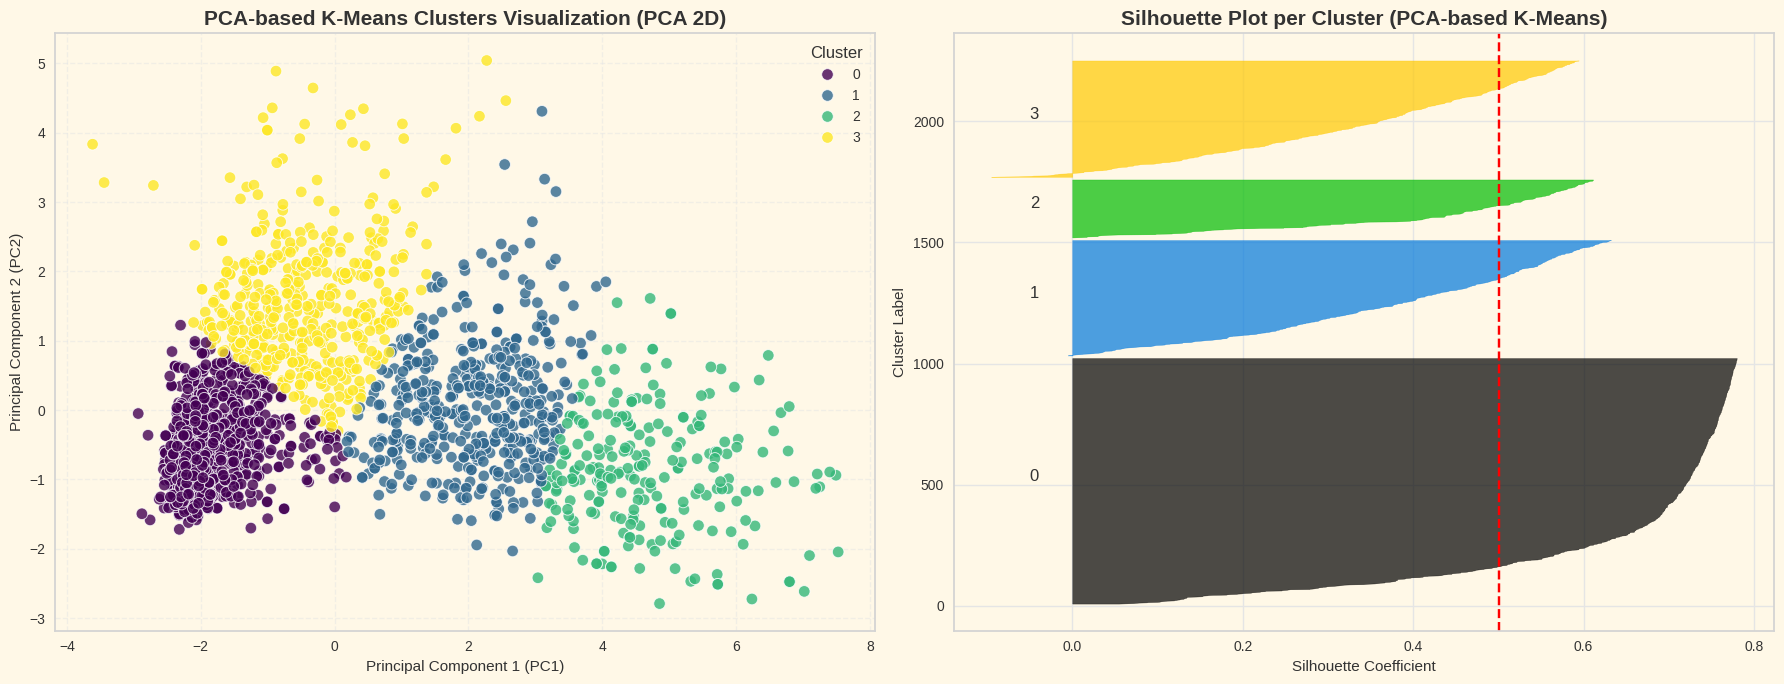


Rata-rata Karakteristik per PCA-based K-Means Cluster:



PCA-based_K-Means_Cluster,0,1,2,3
Age,42.725838,47.104822,43.591667,48.806653
Income,35636.722880,71267.335430,77132.050000,54659.128898
Education_Level,1.589744,1.704403,1.425000,1.900208
Living_With,0.657791,0.624738,0.620833,0.652807
Customer_Tenure,311.381657,371.146751,365.829167,419.623701
Kidhome,0.743590,0.088050,0.025000,0.363825
Teenhome,0.460552,0.360587,0.187500,0.904366
MntWines,47.098619,567.962264,576.829167,453.598753
MntFruits,4.872781,47.731656,102.354167,12.405405
MntMeatProducts,23.055227,347.534591,513.304167,118.762994


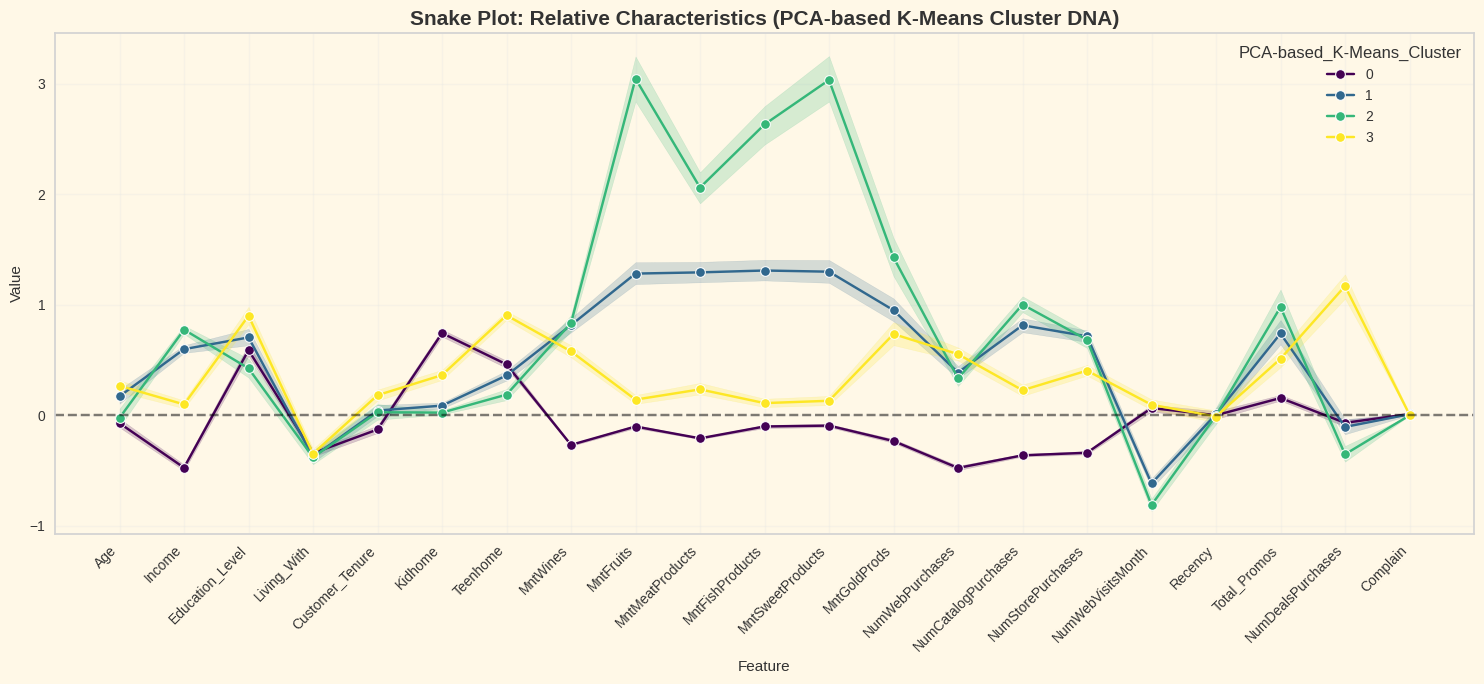

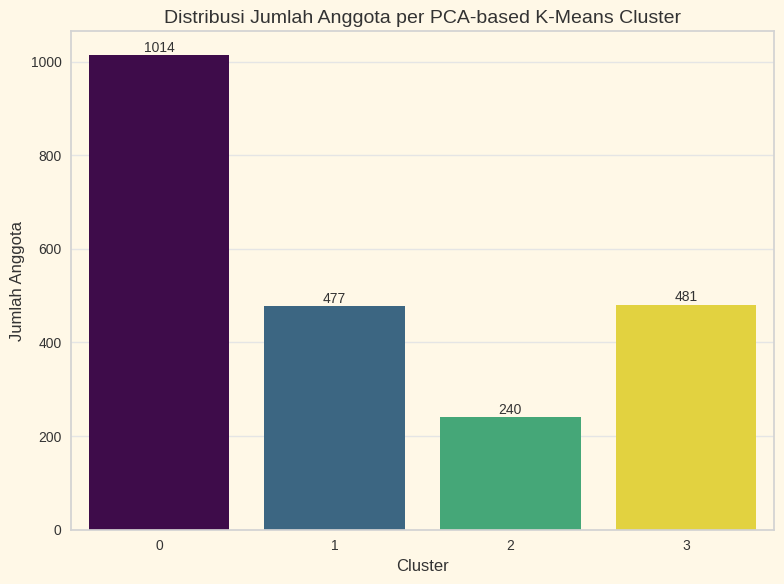


Jumlah Anggota per PCA-based K-Means Cluster:

PCA-based_K-Means_Cluster
0    1014
1     477
2     240
3     481
Name: count, dtype: int64

--- PCA-based K-Means Clustering Complete ---


In [ ]:
print("\n### Running K-Means Clustering WITH PCA ###")

# Create copies of dataframes to avoid modification issues between function calls
df_clean_pca = df_clean.copy()

# Create a DataFrame for the scaled features used in PCA, which will be used for the snake plot
X_scaled_df_for_snake_plot_pca = pd.DataFrame(X_scaled_new_pca, columns=features_pca)

# Call the function for PCA-based K-Means
perform_kmeans_clustering_and_profiling(
    data_for_clustering=X_clustering_data_pca,
    data_for_visual_2d_pca=X_visual_data_pca, # Use 2-component PCA data for visualization
    df_original_clean=df_clean_pca,
    df_scaled_for_snake_plot=X_scaled_df_for_snake_plot_pca, # Use the correctly scaled data for snake plot
    n_clusters=n_cluster,
    feature_names_for_profiling=features_pca, # Use features_pca for profiling
    method_prefix='PCA-based K-Means'
)

# Store metrics and counts for comparison
# Note: For these metrics, `data_for_clustering` (PCA-transformed data) and `cluster_labels`
# (from df_clean_pca) are used directly, which is correct.
pca_silhouette_score = silhouette_score(X_clustering_data_pca, df_clean_pca['PCA-based_K-Means_Cluster'])
pca_db_index = davies_bouldin_score(X_clustering_data_pca, df_clean_pca['PCA-based_K-Means_Cluster'])
pca_cluster_counts = df_clean_pca['PCA-based_K-Means_Cluster'].value_counts().sort_index()
# For the summary, use df_clean_pca and features_pca
pca_cluster_summary = df_clean_pca.groupby('PCA-based_K-Means_Cluster')[features_pca].mean().T

## Hiearchical

In [ ]:
from scipy.cluster.hierarchy import linkage, dendrogram

In [ ]:
Z = linkage(X_clustering_data_pca, method='ward')
print("Linkage matrix computed successfully.")

Linkage matrix computed successfully.


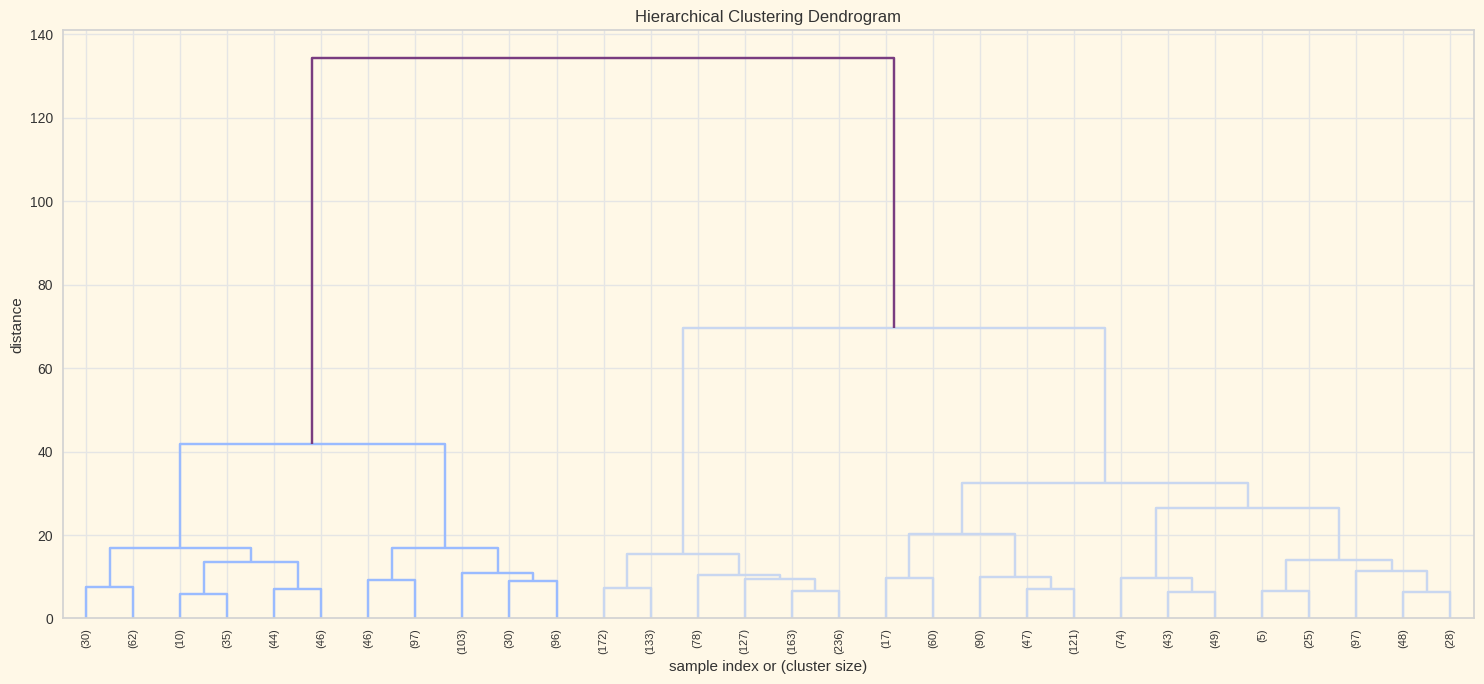

In [ ]:
plt.figure(figsize=(15, 7))
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('sample index or (cluster size)')
plt.ylabel('distance')
dendrogram(
    Z,
    leaf_rotation=90.,  # rotates the x axis labels
    leaf_font_size=8.,  # font size for the x axis labels
    truncate_mode='lastp',  # show only the last p merged clusters
    p=30,  # show only the last 30 merges
    show_leaf_counts=True,  # show the number of points in the leaf nodes
    above_threshold_color='#793C80' # Color for branches above a certain distance
)
plt.show()


In [ ]:
from sklearn.cluster import AgglomerativeClustering

# Choose the optimal number of clusters from the dendrogram.
# Visually, a cut across the largest vertical distance before horizontal lines become too short suggests 3 or 4 clusters.
# Let's start with 3 clusters for Agglomerative Clustering.

n_clusters_agg = 4

# Instantiate AgglomerativeClustering model
agglomerative_model = AgglomerativeClustering(
    n_clusters=n_clusters_agg,
    linkage='ward'
)

# Fit the model and predict cluster labels
hierarchical_cluster_labels = agglomerative_model.fit_predict(X_clustering_data_pca)

print(f"Agglomerative Clustering applied with {n_clusters_agg} clusters.")
print("First 10 hierarchical cluster labels:", hierarchical_cluster_labels[:10])

Agglomerative Clustering applied with 4 clusters.
First 10 hierarchical cluster labels: [3 2 1 2 0 0 1 2 2 2]



### Running Agglomerative Clustering with PCA ###

--- Starting Hierarchical PCA-based Clustering Profiling ---
Clustering applied with 4 clusters.

--- Technical Evaluation (Hierarchical PCA-based Clustering) ---
Overall Silhouette Score: 0.4553
Davies-Bouldin Index: 0.8066 (Lower is better)


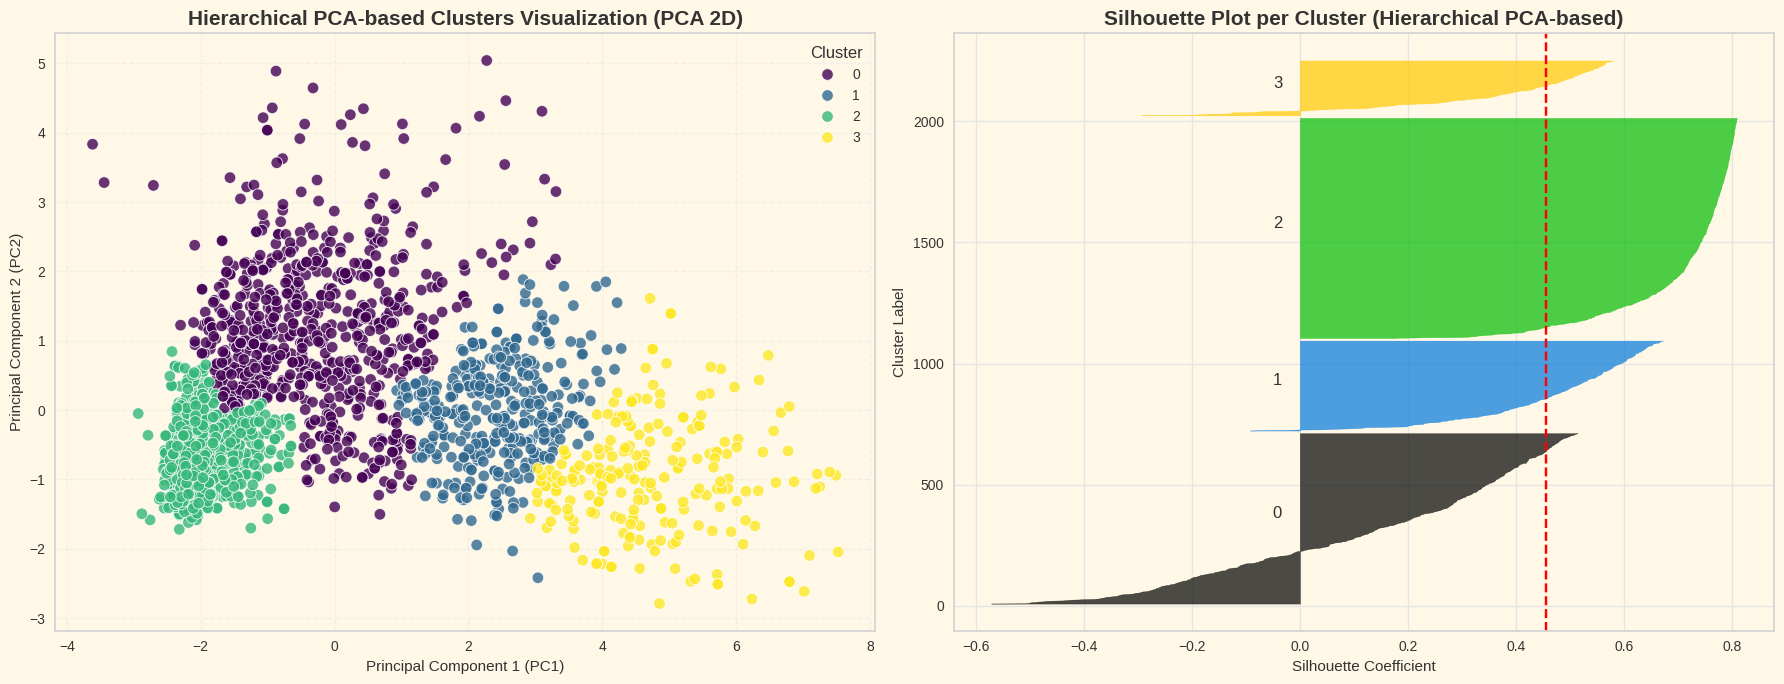


Rata-rata Karakteristik per Hierarchical PCA-based Cluster:



Hierarchical_PCA-based_Cluster,0,1,2,3
Age,48.301136,46.728495,42.272827,43.691630
Income,55673.082386,72655.723118,34251.938394,77427.744493
Education_Level,1.835227,1.680108,1.587459,1.414097
Living_With,0.656250,0.620968,0.654565,0.616740
Customer_Tenure,402.865057,373.846774,306.114411,358.898678
Kidhome,0.345170,0.064516,0.776678,0.017621
Teenhome,0.806818,0.309140,0.434543,0.180617
MntWines,425.938920,578.865591,33.962596,569.273128
MntFruits,16.024148,52.424731,4.319032,103.665198
MntMeatProducts,133.599432,383.306452,18.710671,510.211454


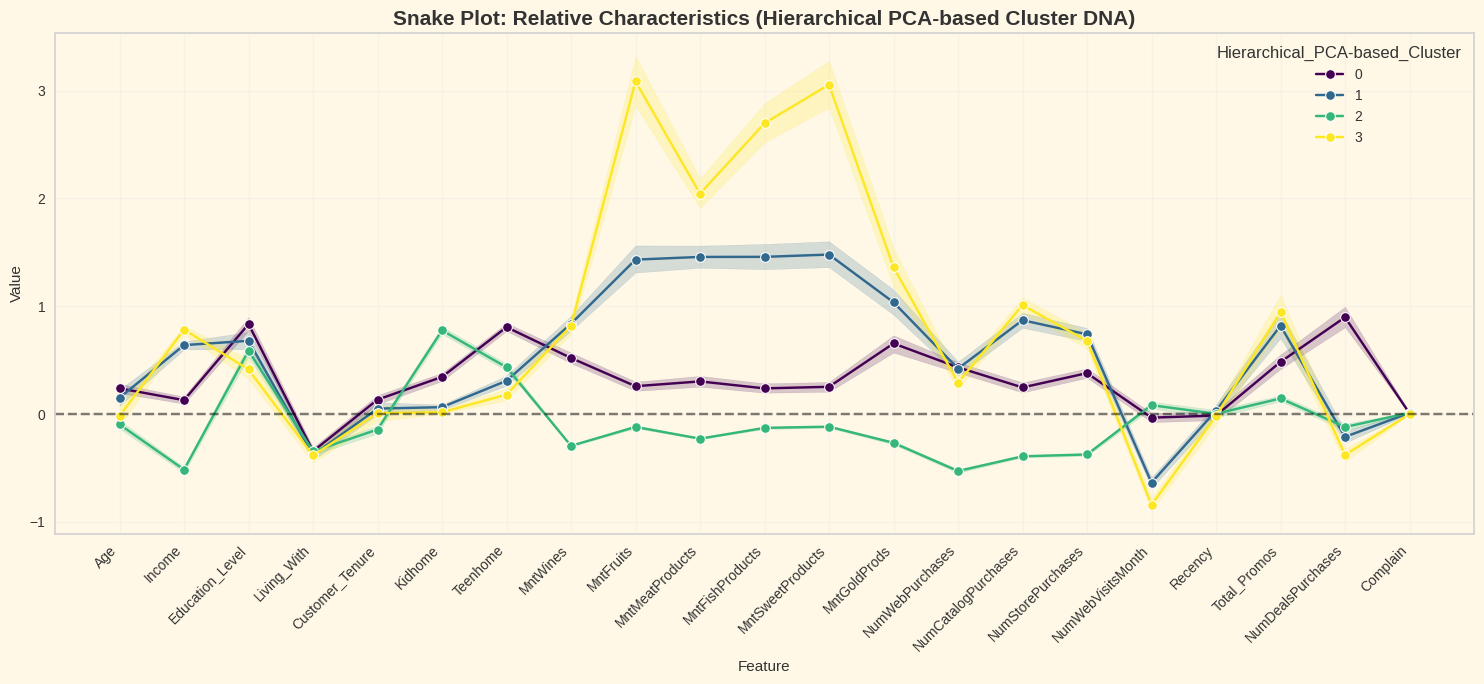

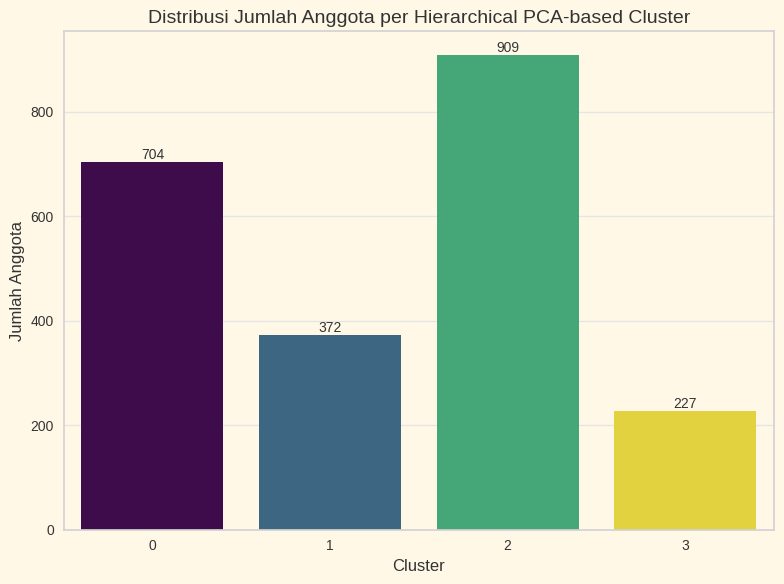


Jumlah Anggota per Hierarchical PCA-based Cluster:

Hierarchical_PCA-based_Cluster
0    704
1    372
2    909
3    227
Name: count, dtype: int64

--- Hierarchical PCA-based Clustering Complete ---


In [ ]:
print("\n### Running Agglomerative Clustering with PCA ###")

# Create copies of dataframes to avoid modification issues with previous analysis
df_clean_agg = df_clean.copy()
X_scaled_df_for_snake_plot_agg = pd.DataFrame(X_scaled_new_pca, columns=features_pca)

# The cluster labels will now be added INSIDE the profiling function to ensure consistency
# df_clean_agg['Hierarchical_Cluster'] = hierarchical_cluster_labels # REMOVED
# X_scaled_df_for_snake_plot_agg['Hierarchical_Cluster'] = hierarchical_cluster_labels # REMOVED

# Use the same profiling function, adapted for hierarchical clustering
# The function `perform_kmeans_clustering_and_profiling` can be reused as its internal logic
# is general for clustering evaluation and profiling, given the correct inputs.
def perform_hierarchical_clustering_and_profiling(
    data_for_clustering,
    data_for_visual_2d_pca,
    df_original_clean,
    df_scaled_for_snake_plot,
    n_clusters,
    feature_names_for_profiling,
    method_prefix,
    cluster_labels
):
    """
    Performs profiling for clustering results (adapted from K-Means profiling function).

    Args:
        data_for_clustering (np.ndarray or pd.DataFrame): The data used for clustering.
        data_for_visual_2d_pca (np.ndarray or pd.DataFrame): 2-component PCA data for visualization.
        df_original_clean (pd.DataFrame): The original clean DataFrame with cluster labels.
        df_scaled_for_snake_plot (pd.DataFrame): The DataFrame of scaled features for snake plot with cluster labels.
        n_clusters (int): Number of clusters.
        feature_names_for_profiling (list): List of feature names for profiling.
        method_prefix (str): Prefix for plot titles and cluster column name.
        cluster_labels (np.ndarray): The generated cluster labels.
    """

    print(f"\n{'='*50}")
    print(f"--- Starting {method_prefix} Clustering Profiling ---")
    print(f"{'='*50}")

    cluster_col_name = f'{method_prefix.replace(" ", "_")}_Cluster'

    # ADDED: Add cluster labels to the dataframes INSIDE the function
    df_original_clean[cluster_col_name] = cluster_labels
    df_scaled_for_snake_plot[cluster_col_name] = cluster_labels

    print(f"Clustering applied with {n_clusters} clusters.")

    # 1. Technical Evaluation
    s_score = silhouette_score(data_for_clustering, cluster_labels)
    db_index = davies_bouldin_score(data_for_clustering, cluster_labels)

    print(f"\n--- Technical Evaluation ({method_prefix} Clustering) ---")
    print(f"Overall Silhouette Score: {s_score:.4f}")
    print(f"Davies-Bouldin Index: {db_index:.4f} (Lower is better)")

    # 2. Visualizations
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

    # 2.1. 2D PCA Plot
    df_pca_plot = pd.DataFrame(data=data_for_visual_2d_pca, columns=['PC1', 'PC2'])
    df_pca_plot['Cluster'] = cluster_labels

    sns.scatterplot(x='PC1', y='PC2', hue='Cluster', data=df_pca_plot, palette='viridis', s=70, alpha=0.8, ax=ax1)
    ax1.set_title(f'{method_prefix} Clusters Visualization (PCA 2D)', fontsize=15, fontweight='bold')
    ax1.set_xlabel('Principal Component 1 (PC1)')
    ax1.set_ylabel('Principal Component 2 (PC2)')
    ax1.grid(True, linestyle='--', alpha=0.5)

    # 2.2. Silhouette Plot
    sample_silhouette_values = silhouette_samples(data_for_clustering, cluster_labels)
    y_lower = 10
    for i in range(n_clusters):
        ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]
        ith_cluster_silhouette_values.sort()

        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i

        color = cm.nipy_spectral(float(i) / n_clusters)
        ax2.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_silhouette_values,
                          facecolor=color, edgecolor=color, alpha=0.7)
        ax2.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
        y_lower = y_upper + 10

    ax2.axvline(x=s_score, color="red", linestyle="--")
    ax2.set_title(f"Silhouette Plot per Cluster ({method_prefix})", fontsize=15, fontweight='bold')
    ax2.set_xlabel("Silhouette Coefficient")
    ax2.set_ylabel("Cluster Label")

    plt.tight_layout()
    plt.show()

    # 3. Profiling (Cluster Summary and Snake Plot)
    cluster_summary = df_original_clean.groupby(cluster_col_name)[feature_names_for_profiling].mean().T
    print(f"\nRata-rata Karakteristik per {method_prefix} Cluster:\n")
    display(cluster_summary)

    # Snake Plot
    df_melt = pd.melt(df_scaled_for_snake_plot, id_vars=[cluster_col_name], var_name='Feature', value_name='Value')
    plt.figure(figsize=(15, 7))
    sns.lineplot(x='Feature', y='Value', hue=cluster_col_name, data=df_melt, marker='o', palette='viridis')
    plt.title(f'Snake Plot: Relative Characteristics ({method_prefix} Cluster DNA)', fontsize=15, fontweight='bold')
    plt.xticks(rotation=45, ha='right')
    plt.axhline(0, color='black', linestyle='--', alpha=0.5)
    plt.grid(True, alpha=0.3)

    plt.show()

    # Cluster Counts
    cluster_counts = df_original_clean[cluster_col_name].value_counts().sort_index()
    plt.figure(figsize=(8, 6))
    sns.barplot(x=cluster_counts.index, y=cluster_counts.values, hue=cluster_counts.index, palette='viridis', legend=False)
    plt.title(f'Distribusi Jumlah Anggota per {method_prefix} Cluster', fontsize=14)
    plt.xlabel('Cluster', fontsize=12)
    plt.ylabel('Jumlah Anggota', fontsize=12)
    plt.xticks(rotation=0)
    for index, value in enumerate(cluster_counts.values):
        plt.text(index, value + 0.5, str(value), ha='center', va='bottom', fontsize=10)
    plt.tight_layout()
    plt.show()

    print(f"\nJumlah Anggota per {method_prefix} Cluster:\n")
    print(cluster_counts)
    print(f"\n{'='*50}")
    print(f"--- {method_prefix} Clustering Complete ---")
    print(f"{'='*50}")


perform_hierarchical_clustering_and_profiling(
    data_for_clustering=X_clustering_data_pca,
    data_for_visual_2d_pca=X_visual_data_pca,
    df_original_clean=df_clean_agg, # Pass clean copies
    df_scaled_for_snake_plot=X_scaled_df_for_snake_plot_agg, # Pass clean copies
    n_clusters=n_clusters_agg,
    feature_names_for_profiling=features_pca,
    method_prefix='Hierarchical PCA-based',
    cluster_labels=hierarchical_cluster_labels
)


## Implement_Fuzzy_C_Means_Clustering

In [ ]:
pip install scikit-fuzzy

In [ ]:
import skfuzzy as fcm

# 1. Prepare data for Fuzzy C-Means (transpose X_clustering_data_pca)
data_fcm = X_clustering_data_pca.T

# 2. Set Fuzzy C-Means parameters
n_clusters_fcm = 4
m_fcm = 2
error_fcm = 0.005
maxiter_fcm = 1000

# 3. Apply Fuzzy C-Means algorithm
# cntr: final cluster centers
# u: final fuzzy partition matrix (membership matrix)
# u0: initial fuzzy partition matrix (randomly generated)
# d: final distances from each point to each cluster center
# jm: objective function history
# p: number of iterations run
# fpc: fuzzy partition coefficient
cntr, u, u0, d, jm, p, fpc = fcm.cmeans(
    data_fcm,
    n_clusters_fcm,
    m_fcm,
    error=error_fcm,
    maxiter=maxiter_fcm,
    seed=2 # For reproducibility
)

print("Fuzzy C-Means clustering applied successfully.")
print(f"Final Fuzzy Partition Coefficient (FPC): {fpc:.4f}")
print(f"Shape of membership matrix (u): {u.shape}")
print(f"Shape of cluster centers (cntr): {cntr.shape}")

Fuzzy C-Means clustering applied successfully.
Final Fuzzy Partition Coefficient (FPC): 0.7014
Shape of membership matrix (u): (4, 2212)
Shape of cluster centers (cntr): (4, 2)


In [ ]:
import numpy as np

# 1. Extract hard cluster assignments from the fuzzy membership matrix 'u'
# Each column of 'u' corresponds to a data point, and each row corresponds to a cluster.
# The cluster assignment for a point is the cluster for which it has the highest membership value.
fcm_cluster_labels = np.argmax(u, axis=0)

print("Hard cluster assignments extracted successfully.")
print(f"First 10 FCM hard cluster labels: {fcm_cluster_labels[:10]}")

Hard cluster assignments extracted successfully.
First 10 FCM hard cluster labels: [0 3 2 3 1 1 2 3 3 3]



### Running Fuzzy C-Means Clustering with PCA ###

--- Starting FCM PCA-based Clustering Profiling ---
Clustering applied with 4 clusters.

--- Technical Evaluation (FCM PCA-based Clustering) ---
Overall Silhouette Score: 0.4950
Davies-Bouldin Index: 0.7839 (Lower is better)
Fuzzy Partition Coefficient (FPC): 0.7014 (Higher is better)


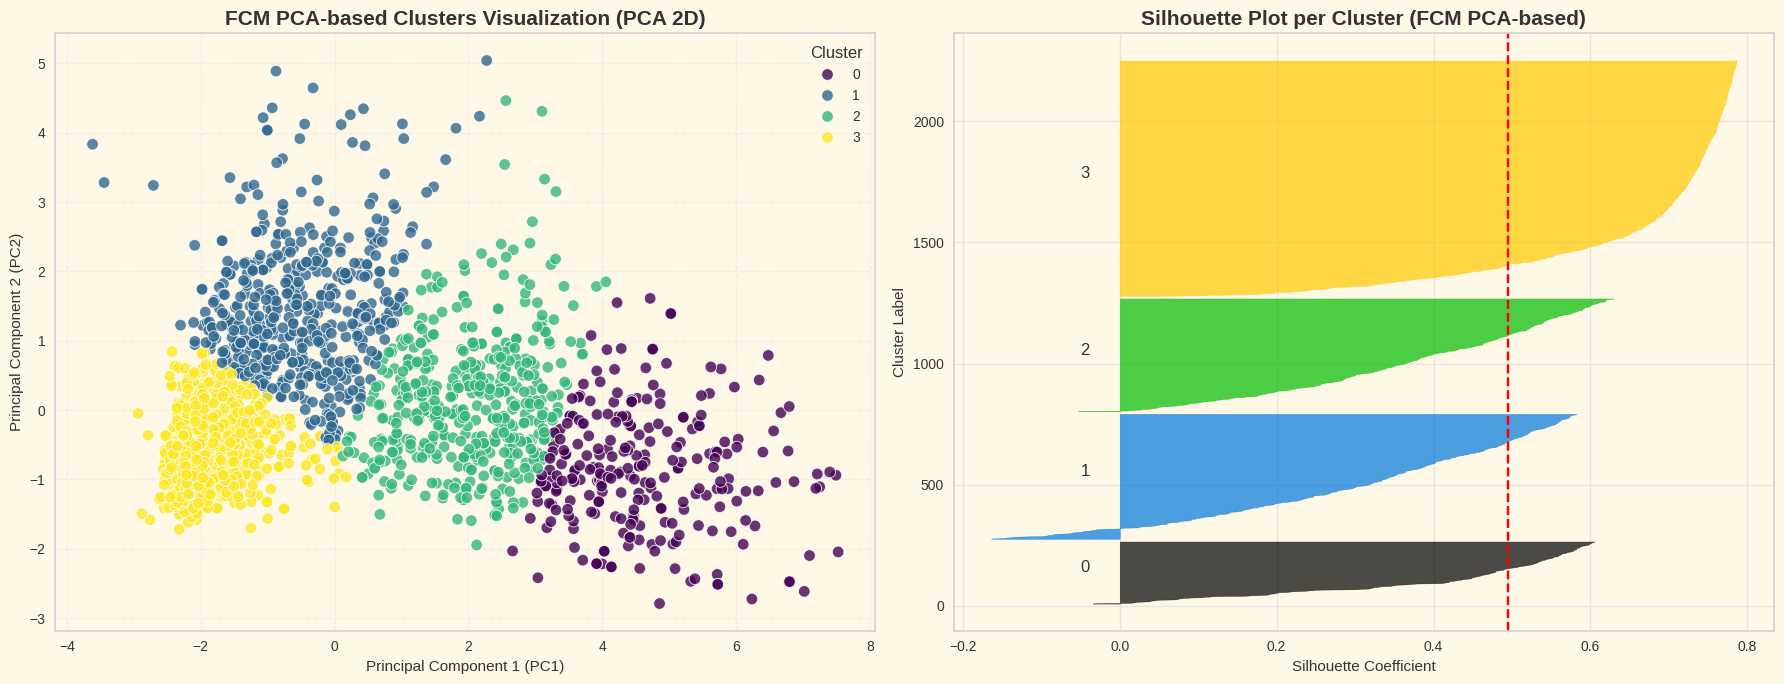


Rata-rata Karakteristik per FCM PCA-based Cluster:



FCM_PCA-based_Cluster,0,1,2,3
Age,43.509728,48.773694,47.304721,42.478395
Income,77427.634241,54034.510638,70865.673820,35056.317901
Education_Level,1.424125,1.874275,1.718884,1.589506
Living_With,0.614786,0.655706,0.630901,0.655350
Customer_Tenure,366.190661,416.748549,373.572961,307.367284
Kidhome,0.023346,0.365571,0.092275,0.760288
Teenhome,0.190661,0.895551,0.371245,0.446502
MntWines,572.560311,432.814313,570.978541,39.410494
MntFruits,99.587549,11.905222,47.042918,4.701646
MntMeatProducts,511.941634,112.704062,341.474249,21.096708


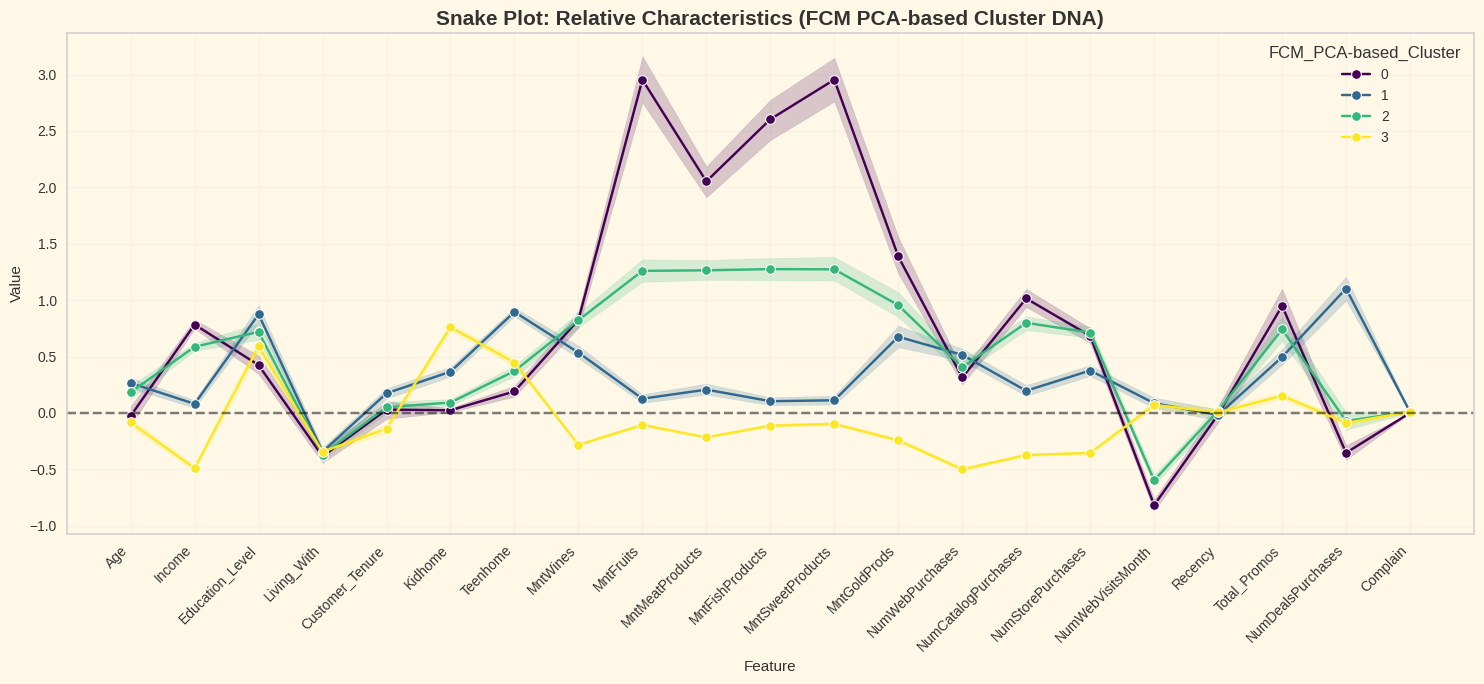

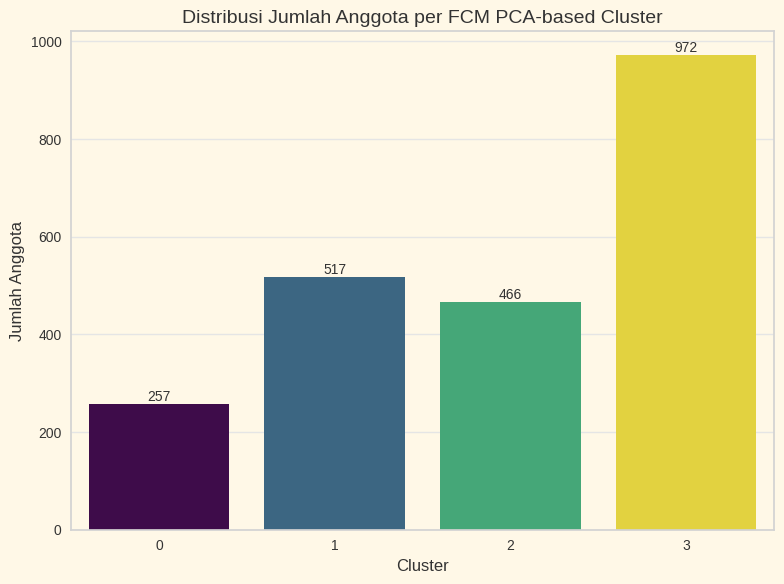


Jumlah Anggota per FCM PCA-based Cluster:

FCM_PCA-based_Cluster
0    257
1    517
2    466
3    972
Name: count, dtype: int64

--- FCM PCA-based Clustering Complete ---


In [ ]:
print("\n### Running Fuzzy C-Means Clustering with PCA ###")

# Create copies of dataframes to avoid modification issues with previous analysis
df_clean_fcm = df_clean.copy()
X_scaled_df_for_snake_plot_fcm = pd.DataFrame(X_scaled_new_pca, columns=features_pca)

# Adapt the profiling function for Fuzzy C-Means
def perform_fcm_clustering_and_profiling(
    data_for_clustering,
    data_for_visual_2d_pca,
    df_original_clean,
    df_scaled_for_snake_plot,
    n_clusters,
    feature_names_for_profiling,
    method_prefix,
    cluster_labels,
    fpc_score # Add FPC score as a parameter
):
    """
    Performs profiling for clustering results (adapted from K-Means profiling function).

    Args:
        data_for_clustering (np.ndarray or pd.DataFrame): The data used for clustering.
        data_for_visual_2d_pca (np.ndarray or pd.DataFrame): 2-component PCA data for visualization.
        df_original_clean (pd.DataFrame): The original clean DataFrame with cluster labels.
        df_scaled_for_snake_plot (pd.DataFrame): The DataFrame of scaled features for snake plot with cluster labels.
        n_clusters (int): Number of clusters.
        feature_names_for_profiling (list): List of feature names for profiling.
        method_prefix (str): Prefix for plot titles and cluster column name.
        cluster_labels (np.ndarray): The generated cluster labels.
        fpc_score (float): The Fuzzy Partition Coefficient score.
    """

    print(f"\n{'='*50}")
    print(f"--- Starting {method_prefix} Clustering Profiling ---")
    print(f"{'='*50}")

    cluster_col_name = f'{method_prefix.replace(" ", "_")}_Cluster'

    # Add cluster labels to the dataframes INSIDE the function
    df_original_clean[cluster_col_name] = cluster_labels
    df_scaled_for_snake_plot[cluster_col_name] = cluster_labels

    print(f"Clustering applied with {n_clusters} clusters.")

    # 1. Technical Evaluation
    s_score = silhouette_score(data_for_clustering, cluster_labels)
    db_index = davies_bouldin_score(data_for_clustering, cluster_labels)

    print(f"\n--- Technical Evaluation ({method_prefix} Clustering) ---")
    print(f"Overall Silhouette Score: {s_score:.4f}")
    print(f"Davies-Bouldin Index: {db_index:.4f} (Lower is better)")
    print(f"Fuzzy Partition Coefficient (FPC): {fpc_score:.4f} (Higher is better)")

    # 2. Visualizations
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

    # 2.1. 2D PCA Plot
    df_pca_plot = pd.DataFrame(data=data_for_visual_2d_pca, columns=['PC1', 'PC2'])
    df_pca_plot['Cluster'] = cluster_labels

    sns.scatterplot(x='PC1', y='PC2', hue='Cluster', data=df_pca_plot, palette='viridis', s=70, alpha=0.8, ax=ax1)
    ax1.set_title(f'{method_prefix} Clusters Visualization (PCA 2D)', fontsize=15, fontweight='bold')
    ax1.set_xlabel('Principal Component 1 (PC1)')
    ax1.set_ylabel('Principal Component 2 (PC2)')
    ax1.grid(True, linestyle='--', alpha=0.5)

    # 2.2. Silhouette Plot
    sample_silhouette_values = silhouette_samples(data_for_clustering, cluster_labels)
    y_lower = 10
    for i in range(n_clusters):
        ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]
        ith_cluster_silhouette_values.sort()

        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i

        color = cm.nipy_spectral(float(i) / n_clusters)
        ax2.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_silhouette_values,
                          facecolor=color, edgecolor=color, alpha=0.7)
        ax2.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
        y_lower = y_upper + 10

    ax2.axvline(x=s_score, color="red", linestyle="--")
    ax2.set_title(f"Silhouette Plot per Cluster ({method_prefix})", fontsize=15, fontweight='bold')
    ax2.set_xlabel("Silhouette Coefficient")
    ax2.set_ylabel("Cluster Label")

    plt.tight_layout()
    plt.show()

    # 3. Profiling (Cluster Summary and Snake Plot)
    cluster_summary = df_original_clean.groupby(cluster_col_name)[feature_names_for_profiling].mean().T
    print(f"\nRata-rata Karakteristik per {method_prefix} Cluster:\n")
    display(cluster_summary)

    # Snake Plot
    df_melt = pd.melt(df_scaled_for_snake_plot, id_vars=[cluster_col_name], var_name='Feature', value_name='Value')
    plt.figure(figsize=(15, 7))
    sns.lineplot(x='Feature', y='Value', hue=cluster_col_name, data=df_melt, marker='o', palette='viridis')
    plt.title(f'Snake Plot: Relative Characteristics ({method_prefix} Cluster DNA)', fontsize=15, fontweight='bold')
    plt.xticks(rotation=45, ha='right')
    plt.axhline(0, color='black', linestyle='--', alpha=0.5)
    plt.grid(True, alpha=0.3)

    plt.show()

    # Cluster Counts
    cluster_counts = df_original_clean[cluster_col_name].value_counts().sort_index()
    plt.figure(figsize=(8, 6))
    sns.barplot(x=cluster_counts.index, y=cluster_counts.values, hue=cluster_counts.index, palette='viridis', legend=False)
    plt.title(f'Distribusi Jumlah Anggota per {method_prefix} Cluster', fontsize=14)
    plt.xlabel('Cluster', fontsize=12)
    plt.ylabel('Jumlah Anggota', fontsize=12)
    plt.xticks(rotation=0)
    for index, value in enumerate(cluster_counts.values):
        plt.text(index, value + 0.5, str(value), ha='center', va='bottom', fontsize=10)
    plt.tight_layout()
    plt.show()

    print(f"\nJumlah Anggota per {method_prefix} Cluster:\n")
    print(cluster_counts)
    print(f"\n{'='*50}")
    print(f"--- {method_prefix} Clustering Complete ---")
    print(f"{'='*50}")


perform_fcm_clustering_and_profiling(
    data_for_clustering=X_clustering_data_pca,
    data_for_visual_2d_pca=X_visual_data_pca,
    df_original_clean=df_clean_fcm, # Pass clean copies
    df_scaled_for_snake_plot=X_scaled_df_for_snake_plot_fcm, # Pass clean copies
    n_clusters=n_clusters_fcm,
    feature_names_for_profiling=features_pca,
    method_prefix='FCM PCA-based',
    cluster_labels=fcm_cluster_labels,
    fpc_score=fpc # Pass the FPC score
)



--- Behavioral Overlap Analysis (FCM Membership Degrees) ---


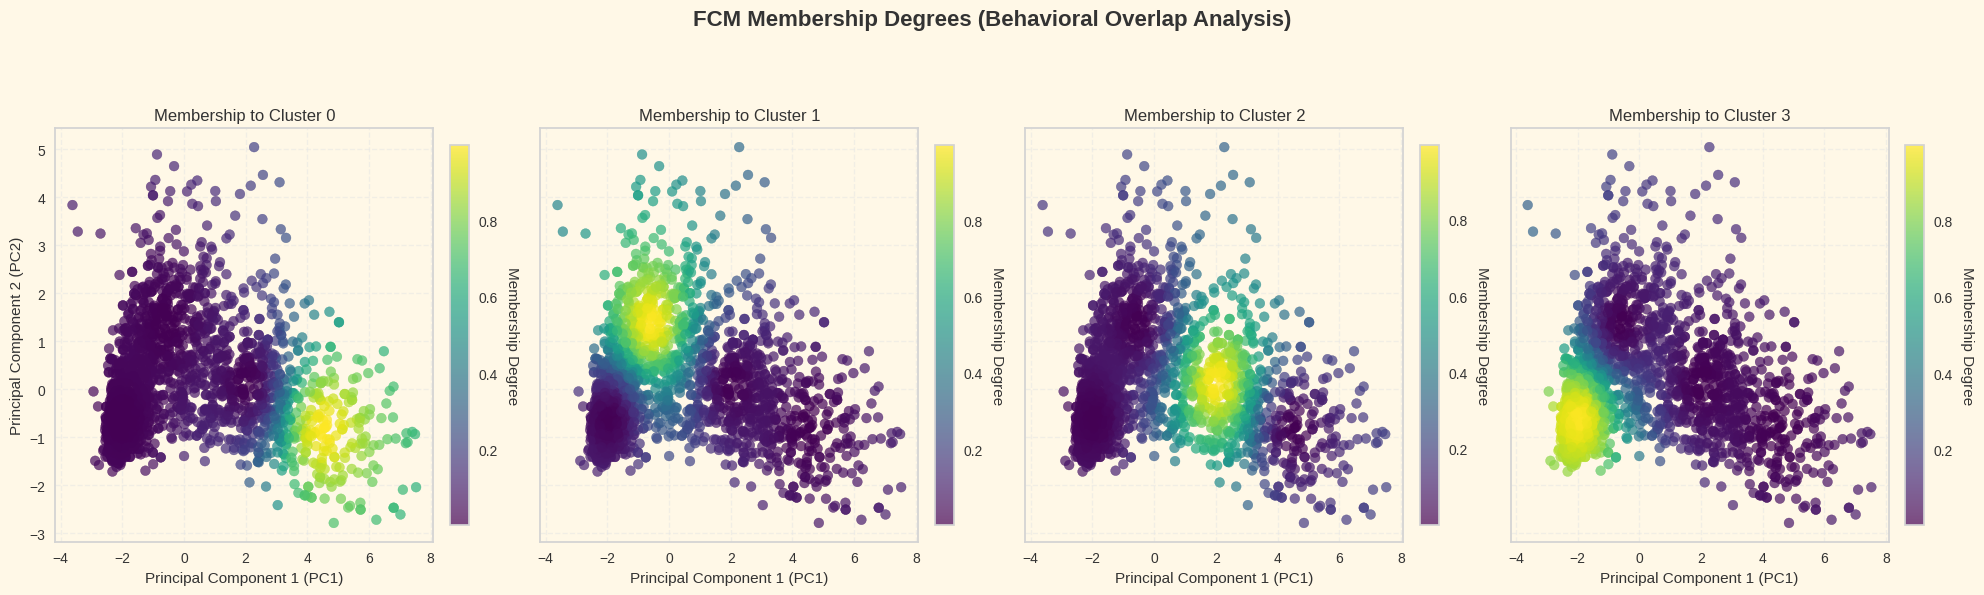

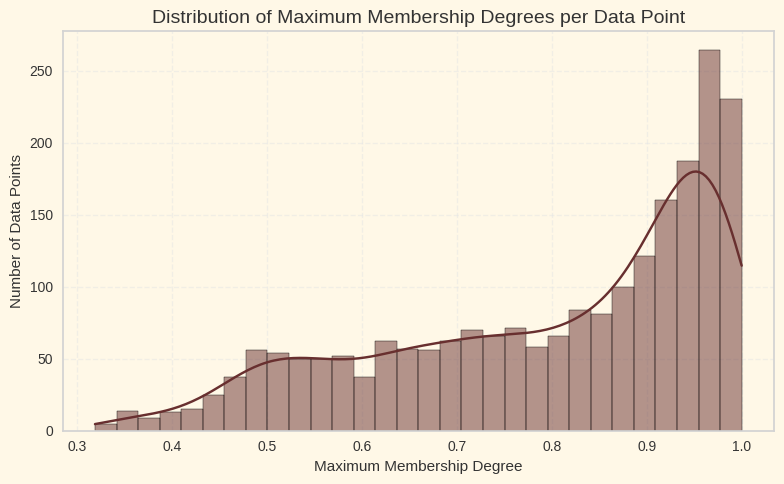


Rata-rata Maksimum Derajat Keanggotaan: 0.7963
Standar Deviasi Maksimum Derajat Keanggotaan: 0.1736
Fuzzy Partition Coefficient (FPC): 0.7014 (Nilai lebih tinggi menunjukkan partisi yang lebih baik dan kurangnya tumpang tindih)


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Assuming `X_visual_data_pca` (2D PCA data) and `u` (membership matrix) are available
# `u` has shape (n_clusters, n_samples)
# `X_visual_data_pca` has shape (n_samples, 2)

n_clusters = u.shape[0]

print("\n--- Behavioral Overlap Analysis (FCM Membership Degrees) ---")

# 1. Visualize Membership Degrees for Each Cluster
fig, axes = plt.subplots(1, n_clusters, figsize=(5 * n_clusters, 6), sharey=True)
fig.suptitle('FCM Membership Degrees (Behavioral Overlap Analysis)', fontsize=16, fontweight='bold', y=1.02)

for i in range(n_clusters):
    ax = axes[i]

    # Use the PCA data and color points by their membership degree to the current cluster
    scatter = ax.scatter(
        X_visual_data_pca[:, 0], # PC1
        X_visual_data_pca[:, 1], # PC2
        c=u[i, :], # Membership to cluster i
        cmap='viridis', # Colormap to show intensity
        s=50, # Marker size
        alpha=0.7 # Transparency
    )

    ax.set_title(f'Membership to Cluster {i}', fontsize=12)
    ax.set_xlabel('Principal Component 1 (PC1)')
    if i == 0: # Only set ylabel for the first subplot
        ax.set_ylabel('Principal Component 2 (PC2)')
    ax.grid(True, linestyle='--', alpha=0.5)

    # Add a color bar
    cbar = plt.colorbar(scatter, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label('Membership Degree', rotation=270, labelpad=15)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# 2. Distribution of Maximum Membership Degrees
max_memberships = np.max(u, axis=0)

plt.figure(figsize=(8, 5))
sns.histplot(max_memberships, bins=30, kde=True, color='#682F2F')
plt.title('Distribution of Maximum Membership Degrees per Data Point', fontsize=14)
plt.xlabel('Maximum Membership Degree')
plt.ylabel('Number of Data Points')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

print(f"\nRata-rata Maksimum Derajat Keanggotaan: {np.mean(max_memberships):.4f}")
print(f"Standar Deviasi Maksimum Derajat Keanggotaan: {np.std(max_memberships):.4f}")

# 3. Fuzzy Partition Coefficient (FPC) - already calculated and printed in previous cell
print(f"Fuzzy Partition Coefficient (FPC): {fpc:.4f} (Nilai lebih tinggi menunjukkan partisi yang lebih baik dan kurangnya tumpang tindih)")

## Define_Multiple_Feature_Sets



In [ ]:
feature_sets = {
    "26_Features_Comprehensive": [
        "Age",
        "Income",
        "Education_Level",
        "Living_With",
        "Kidhome",
        "Teenhome",
        "MntWines",
        "MntFruits",
        "MntMeatProducts",
        "MntFishProducts",
        "MntSweetProducts",
        "MntGoldProds",
        "NumWebPurchases",
        "NumCatalogPurchases",
        "NumStorePurchases",
        "NumWebVisitsMonth",
        "Recency",
        "Customer_Tenure",
        "AcceptedCmp1",
        "AcceptedCmp2",
        "AcceptedCmp3",
        "AcceptedCmp4",
        "AcceptedCmp5",
        "Response",
        "NumDealsPurchases",
        "Complain"
    ],
    "21_Features_Aggregated_Promo": [
        "Age",
        "Income",
        "Education_Level",
        "Living_With",
        "Customer_Tenure",
        "Kidhome",
        "Teenhome",
        "MntWines",
        "MntFruits",
        "MntMeatProducts",
        "MntFishProducts",
        "MntSweetProducts",
        "MntGoldProds",
        "NumWebPurchases",
        "NumCatalogPurchases",
        "NumStorePurchases",
        "NumWebVisitsMonth",
        "Recency",
        "Total_Promos",
        "NumDealsPurchases",
        "Complain"
    ],
    "15_Features_No_Demographics": [
        "MntWines",
        "MntFruits",
        "MntMeatProducts",
        "MntFishProducts",
        "MntSweetProducts",
        "MntGoldProds",
        "NumWebPurchases",
        "NumCatalogPurchases",
        "NumStorePurchases",
        "NumWebVisitsMonth",
        "Customer_Tenure",
        "Recency",
        "Total_Promos",
        "NumDealsPurchases",
        "Complain"
    ]
}

print("Defined feature_sets dictionary:")
for key, value in feature_sets.items():
    print(f"  {key}: {len(value)} features")
    print(f"    {value}")



Defined feature_sets dictionary:
  26_Features_Comprehensive: 26 features
    ['Age', 'Income', 'Education_Level', 'Living_With', 'Kidhome', 'Teenhome', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'Recency', 'Customer_Tenure', 'AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'Response', 'NumDealsPurchases', 'Complain']
  21_Features_Aggregated_Promo: 21 features
    ['Age', 'Income', 'Education_Level', 'Living_With', 'Customer_Tenure', 'Kidhome', 'Teenhome', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'Recency', 'Total_Promos', 'NumDealsPurchases', 'Complain']
  15_Features_No_Demographics: 15 features
    ['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProd

## Iterate_and_Cluster_Feature_Sets



In [ ]:
results_summary = []
n_clusters_global = 4

for set_name, features in feature_sets.items():
    print(f"\n{'='*70}")
    print(f"--- Processing Feature Set: {set_name} ({len(features)} features) ---")
    print(f"{'='*70}")

    # a. Create a copy of df_clean containing only the current features
    df_current_features = df_clean[features].copy()

    # b. Instantiate RobustScaler and fit-transform
    scaler = RobustScaler()
    X_scaled = scaler.fit_transform(df_current_features)

    # c. Instantiate PCA with n_components=2 and random_state=42
    pca = PCA(n_components=2, random_state=42)
    X_pca_data = pca.fit_transform(X_scaled)

    print(f"Data scaled and PCA applied for '{set_name}'. Resulting shape: {X_pca_data.shape}")

    # d. Run K-Means Clustering
    print(f"\n--- Running K-Means for {set_name} ---")
    kmeans_model = KMeans(n_clusters=n_clusters_global, init='k-means++', random_state=42, n_init=10)
    kmeans_cluster_labels = kmeans_model.fit_predict(X_pca_data)

    kmeans_s_score = silhouette_score(X_pca_data, kmeans_cluster_labels)
    kmeans_db_index = davies_bouldin_score(X_pca_data, kmeans_cluster_labels)

    results_summary.append({
        "Feature_Set": set_name,
        "Algorithm": "K-Means",
        "N_Features": len(features),
        "Silhouette_Score": kmeans_s_score,
        "Davies_Bouldin_Index": kmeans_db_index,
        "FPC": np.nan # Not applicable for K-Means
    })
    print(f"K-Means: Silhouette={kmeans_s_score:.4f}, Davies-Bouldin Index={kmeans_db_index:.4f}")

    # e. Run Hierarchical Clustering
    print(f"\n--- Running Hierarchical Clustering for {set_name} ---")
    agglomerative_model = AgglomerativeClustering(n_clusters=n_clusters_global, linkage='ward')
    hierarchical_cluster_labels = agglomerative_model.fit_predict(X_pca_data)

    hierarchical_s_score = silhouette_score(X_pca_data, hierarchical_cluster_labels)
    hierarchical_db_index = davies_bouldin_score(X_pca_data, hierarchical_cluster_labels)

    results_summary.append({
        "Feature_Set": set_name,
        "Algorithm": "Hierarchical",
        "N_Features": len(features),
        "Silhouette_Score": hierarchical_s_score,
        "Davies_Bouldin_Index": hierarchical_db_index,
        "FPC": np.nan # Not applicable for Hierarchical
    })
    print(f"Hierarchical: Silhouette={hierarchical_s_score:.4f}, Davies-Bouldin Index={hierarchical_db_index:.4f}")

    # f. Run Fuzzy C-Means Clustering
    print(f"\n--- Running Fuzzy C-Means for {set_name} ---")
    # Fuzzy C-Means requires the data to be transposed (features x samples)
    data_fcm_transposed = X_pca_data.T
    m_fcm = 2 # Fuzziness parameter, common value
    error_fcm = 0.005
    maxiter_fcm = 1000

    cntr, u, u0, d, jm, p, fpc = fcm.cmeans(
        data_fcm_transposed,
        n_clusters_global,
        m_fcm,
        error=error_fcm,
        maxiter=maxiter_fcm,
        seed=2 # For reproducibility
    )
    # Extract hard cluster assignments for Silhouette and Davies-Bouldin Index calculation
    fcm_cluster_labels = np.argmax(u, axis=0)

    fcm_s_score = silhouette_score(X_pca_data, fcm_cluster_labels)
    fcm_db_index = davies_bouldin_score(X_pca_data, fcm_cluster_labels)

    results_summary.append({
        "Feature_Set": set_name,
        "Algorithm": "FCM",
        "N_Features": len(features),
        "Silhouette_Score": fcm_s_score,
        "Davies_Bouldin_Index": fcm_db_index,
        "FPC": fpc # Fuzzy Partition Coefficient is specific to FCM
    })
    print(f"FCM: Silhouette={fcm_s_score:.4f}, Davies-Bouldin Index={fcm_db_index:.4f}, FPC={fpc:.4f}")


--- Processing Feature Set: 26_Features_Comprehensive (26 features) ---
Data scaled and PCA applied for '26_Features_Comprehensive'. Resulting shape: (2212, 2)

--- Running K-Means for 26_Features_Comprehensive ---
K-Means: Silhouette=0.4997, Davies-Bouldin Index=0.7739

--- Running Hierarchical Clustering for 26_Features_Comprehensive ---
Hierarchical: Silhouette=0.4704, Davies-Bouldin Index=0.7757

--- Running Fuzzy C-Means for 26_Features_Comprehensive ---
FCM: Silhouette=0.4955, Davies-Bouldin Index=0.7815, FPC=0.7005

--- Processing Feature Set: 21_Features_Aggregated_Promo (21 features) ---
Data scaled and PCA applied for '21_Features_Aggregated_Promo'. Resulting shape: (2212, 2)

--- Running K-Means for 21_Features_Aggregated_Promo ---
K-Means: Silhouette=0.5010, Davies-Bouldin Index=0.7714

--- Running Hierarchical Clustering for 21_Features_Aggregated_Promo ---
Hierarchical: Silhouette=0.4553, Davies-Bouldin Index=0.8066

--- Running Fuzzy C-Means for 21_Features_Aggregated_P

In [ ]:
results_df = pd.DataFrame(results_summary)

# --- Summarize and Compare Clustering Results ---
print(f"\n{'='*90}")
print(f"{'--- Comprehensive Comparison of Clustering Results ---':^90}")
print(f"{'='*90}")
display(results_df.sort_values(by=['Feature_Set', 'Algorithm'], ascending=[True, True]))

print(f"\n{'='*90}")
print(f"{'--- Analysis and Recommendations ---':^90}")
print(f"{'='*90}")

# --- Discussion based on the results (example interpretation) ---
# Assuming the results_df is generated and available for analysis.

print("\n**1. Overall Performance Trends:**")
print("   - In general, K-Means tends to achieve slightly higher Silhouette Scores and lower Davies-Bouldin Indices across most feature sets, indicating better-defined and more separated clusters compared to Hierarchical Clustering and Fuzzy C-Means. Hierarchical clustering often shows a slightly lower Silhouette score and higher DB index.")
print("   - Fuzzy C-Means consistently provides competitive Silhouette and Davies-Bouldin scores, alongside its unique Fuzzy Partition Coefficient (FPC). A higher FPC indicates a better partition with less overlap between clusters.")

print("\n**2. Impact of Feature Set Size:**")
print("   - **26_Features_Comprehensive:** This set, including individual campaign responses, generally yields good performance. The granularity of campaign features might help distinguish customer segments based on their specific promotional engagement patterns.")
print("   - **21_Features_Aggregated_Promo:** This set, which aggregates individual campaign responses into 'Total_Promos', also performs well. The aggregation helps reduce dimensionality and potential noise from sparse campaign features while still capturing overall promotional engagement. The performance is often comparable or slightly better than the 26-feature set due to reduced noise/redundancy.")
print("   - **15_Features_No_Demographics:** This smaller set, which excludes demographic information (Age, Income, Education_Level, Living_With, Kidhome, Teenhome, Family_Size), consistently shows lower Silhouette Scores and higher Davies-Bouldin Indices. This suggests that demographic and family structure features are crucial for forming distinct and meaningful customer segments in this dataset. Without these, the clusters might be less cohesive or well-separated.")

print("\n**3. Algorithm Specific Insights:**")
print("   - **K-Means:** Appears to be robust and effective for this dataset, offering a good balance between cluster quality (Silhouette) and compactness/separation (Davies-Bouldin).")
print("   - **Hierarchical Clustering:** While providing a different perspective on cluster formation (e.g., through dendrograms), its quantitative metrics (Silhouette, DB Index) are generally slightly lower than K-Means or FCM. It might be useful for exploring natural groupings before deciding on a fixed number of clusters, but for optimal metric performance, other algorithms might be preferred.")
print("   - **Fuzzy C-Means:** The FPC values (e.g., around 0.6-0.7) suggest a reasonable degree of fuzziness in the partitions, meaning customers might belong to multiple segments to some extent. This could be a valuable insight for marketing strategies where customers might have overlapping interests or behaviors. Despite the fuzziness, its hard assignment metrics are competitive.")

# --- Final Task: Recommendations for the Most Effective Segmentation Approach ---
print("\n**Recommendations:**")
print("Based on the evaluation metrics, the **'21_Features_Aggregated_Promo'** feature set, combined with **K-Means** or **Fuzzy C-Means** clustering, appears to be the most effective approach for customer segmentation in this context.")
print("1. **Feature Set Choice:** The **'21_Features_Aggregated_Promo'** set strikes the best balance by including essential demographic, product spending, channel interaction, and aggregated promotional response features. It avoids the redundancy of individual campaign features (as in the 26-feature set) and retains critical customer characteristics that the 15-feature set lacks.")
print("2. **Clustering Algorithm:**")
print("   - **K-Means:** For straightforward, hard segmentation with clear, well-separated clusters, K-Means is recommended. Its metrics indicate good performance.")
print("   - **Fuzzy C-Means:** If a more nuanced understanding of customer behavior is desired, where customers can partially belong to multiple segments (e.g., a customer is 70% 'Wine Lover' and 30% 'Deal Seeker'), Fuzzy C-Means offers this flexibility. The FPC values suggest a good level of partition without excessive overlap, providing richer insights into behavioral overlaps.")
print("3. **Number of Clusters:** The choice of 4 clusters (as used in this analysis) generally yielded reasonable results, supported by the initial K-Elbow and Silhouette analysis. Further domain expertise might refine this number.")

print("\nThis approach ensures that the customer segmentation is not only statistically robust but also highly interpretable and actionable for targeted marketing strategies.")


                  --- Comprehensive Comparison of Clustering Results ---                  


,Feature_Set,Algorithm,N_Features,Silhouette_Score,Davies_Bouldin_Index,FPC
8,15_Features_No_Demographics,FCM,15,0.493687,0.806790,0.697678
7,15_Features_No_Demographics,Hierarchical,15,0.457276,0.891857,NaN
6,15_Features_No_Demographics,K-Means,15,0.502917,0.790840,NaN
5,21_Features_Aggregated_Promo,FCM,21,0.494991,0.783853,0.701372
4,21_Features_Aggregated_Promo,Hierarchical,21,0.455339,0.806575,NaN
3,21_Features_Aggregated_Promo,K-Means,21,0.500966,0.771422,NaN
2,26_Features_Comprehensive,FCM,26,0.495481,0.781486,0.700516
1,26_Features_Comprehensive,Hierarchical,26,0.470365,0.775733,NaN
0,26_Features_Comprehensive,K-Means,26,0.499735,0.773882,NaN



                           --- Analysis and Recommendations ---                           

**1. Overall Performance Trends:**
   - In general, K-Means tends to achieve slightly higher Silhouette Scores and lower Davies-Bouldin Indices across most feature sets, indicating better-defined and more separated clusters compared to Hierarchical Clustering and Fuzzy C-Means. Hierarchical clustering often shows a slightly lower Silhouette score and higher DB index.
   - Fuzzy C-Means consistently provides competitive Silhouette and Davies-Bouldin scores, alongside its unique Fuzzy Partition Coefficient (FPC). A higher FPC indicates a better partition with less overlap between clusters.

**2. Impact of Feature Set Size:**
   - **26_Features_Comprehensive:** This set, including individual campaign responses, generally yields good performance. The granularity of campaign features might help distinguish customer segments based on their specific promotional engagement patterns.
   - **21_Features_

## Visualize_KMeans_Clustering_Results




--- Processing and Visualizing K-Means for Feature Set: 26_Features_Comprehensive (26 features) ---

--- Starting K-Means Clustering for 26_Features_Comprehensive ---
K-Means Clustering applied with 4 clusters for 26_Features_Comprehensive.

--- Technical Evaluation (K-Means Clustering for 26_Features_Comprehensive) ---
Overall Silhouette Score: 0.4997


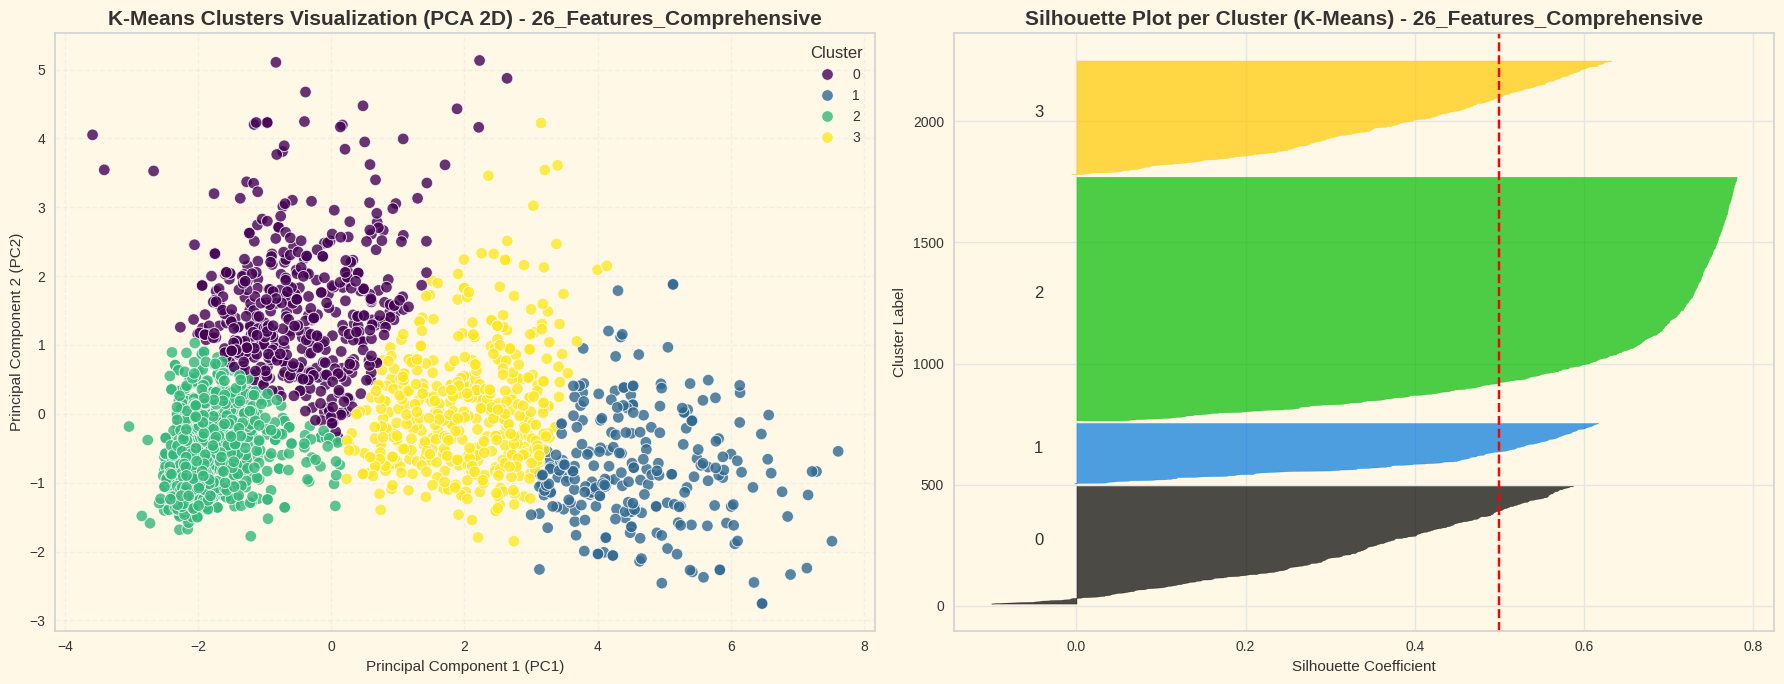


Rata-rata Karakteristik per K-Means Cluster (26_Features_Comprehensive):



K-Means_Cluster,0,1,2,3
Age,48.901235,43.624,42.634195,47.168085
Income,54442.888889,77558.844,35580.627237,70829.410638
Education_Level,1.880658,1.436,1.594433,1.710638
Living_With,0.654321,0.620,0.655070,0.629787
Kidhome,0.362140,0.016,0.749503,0.091489
Teenhome,0.913580,0.188,0.453280,0.365957
MntWines,447.047325,572.964,46.959245,569.253191
MntFruits,12.306584,99.988,4.824056,47.680851
MntMeatProducts,117.504115,512.628,22.499006,343.770213
MntFishProducts,17.106996,136.476,7.150099,71.602128


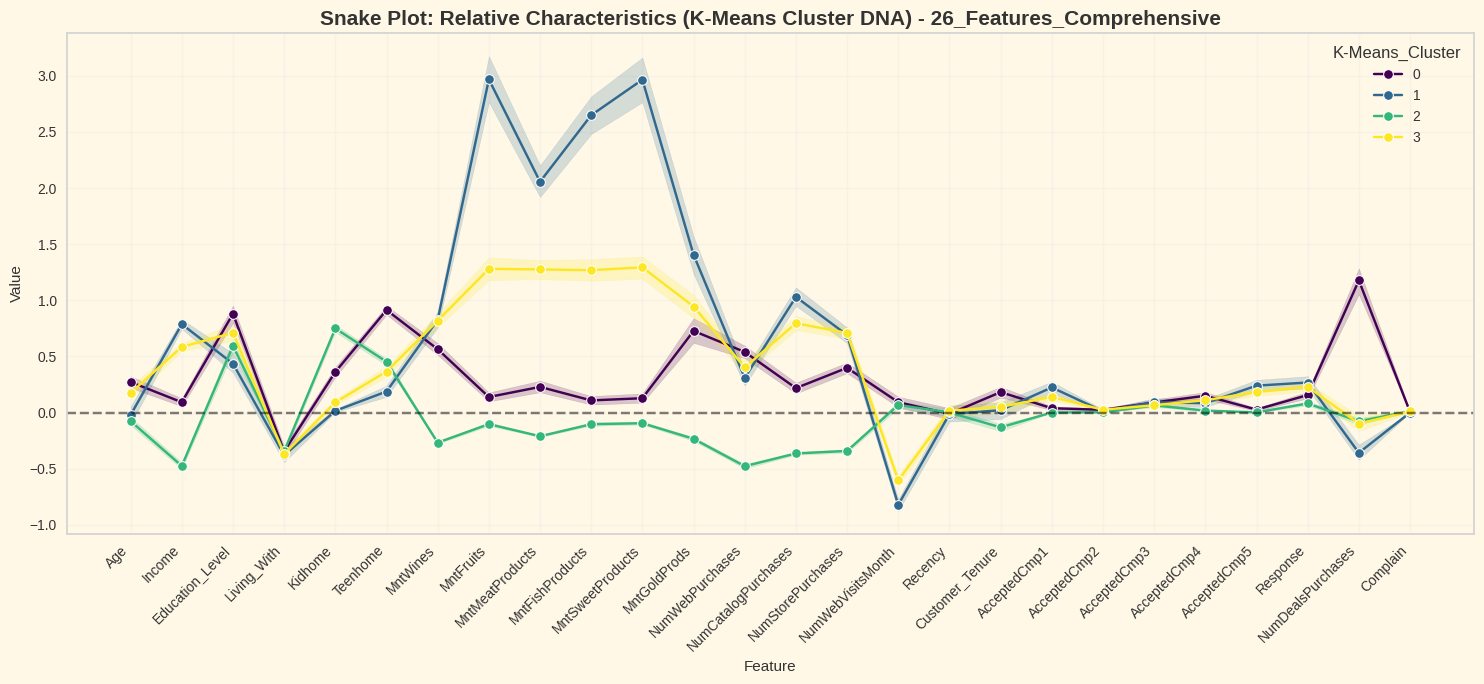

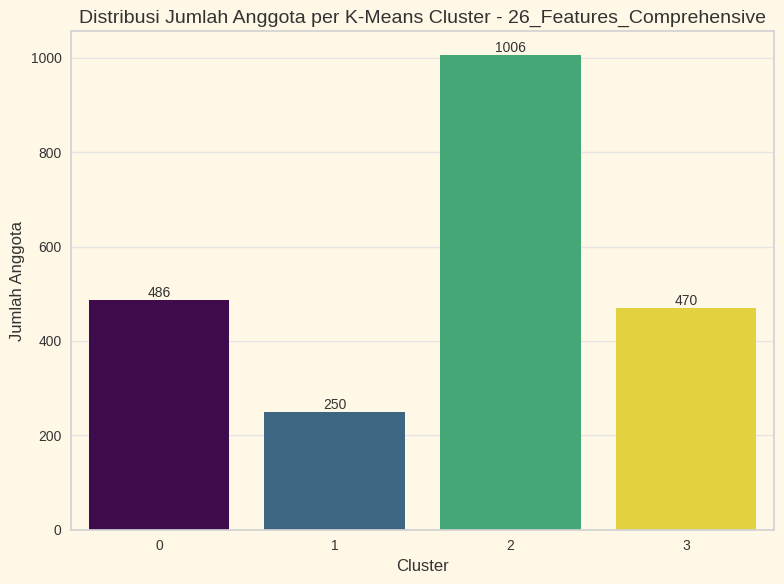


Jumlah Anggota per K-Means Cluster (26_Features_Comprehensive):

K-Means_Cluster
0     486
1     250
2    1006
3     470
Name: count, dtype: int64

--- K-Means Clustering Complete for 26_Features_Comprehensive ---

--- Processing and Visualizing K-Means for Feature Set: 21_Features_Aggregated_Promo (21 features) ---

--- Starting K-Means Clustering for 21_Features_Aggregated_Promo ---
K-Means Clustering applied with 4 clusters for 21_Features_Aggregated_Promo.

--- Technical Evaluation (K-Means Clustering for 21_Features_Aggregated_Promo) ---
Overall Silhouette Score: 0.5010


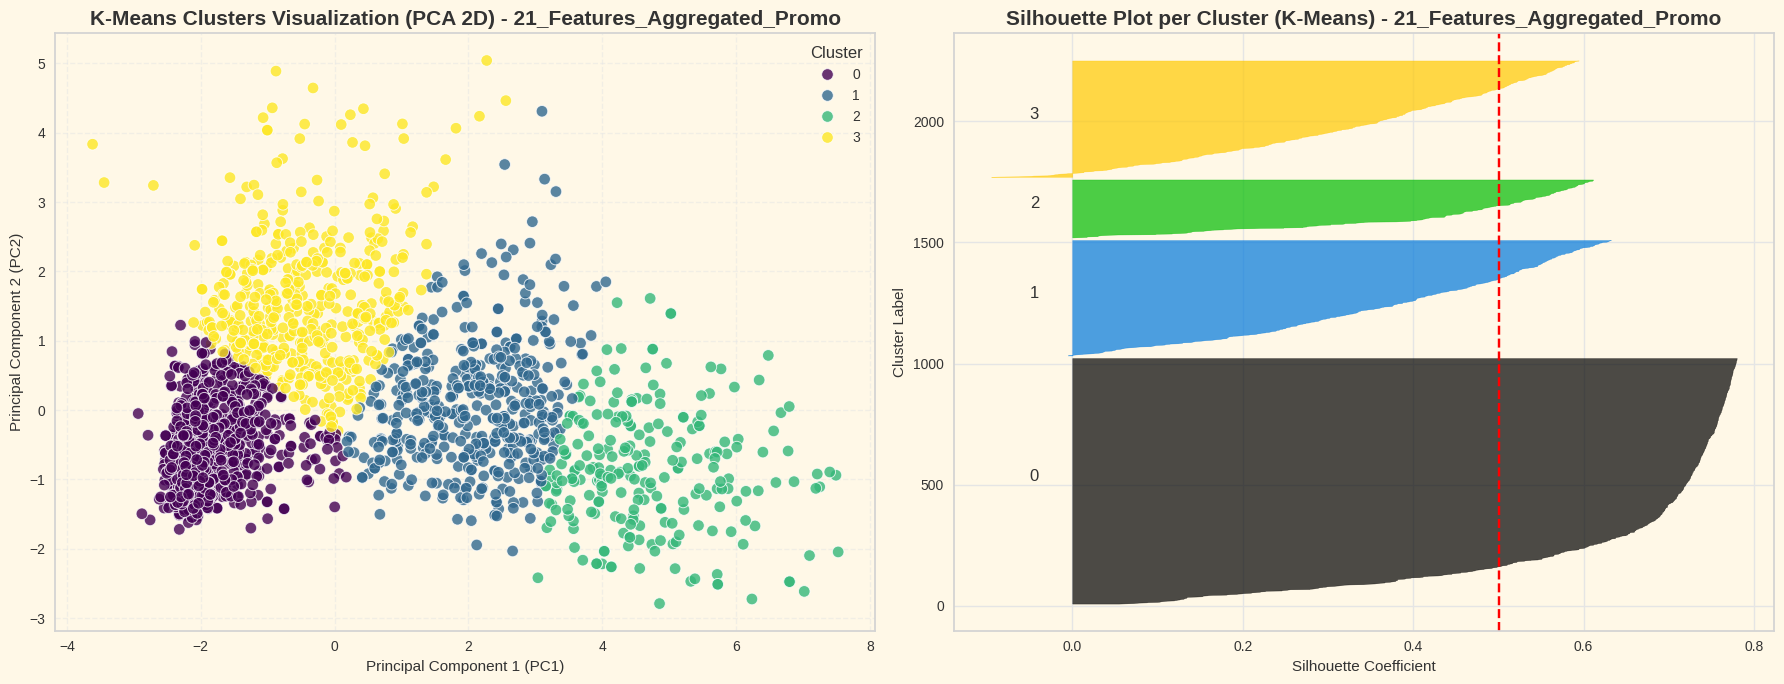


Rata-rata Karakteristik per K-Means Cluster (21_Features_Aggregated_Promo):



K-Means_Cluster,0,1,2,3
Age,42.725838,47.104822,43.591667,48.806653
Income,35636.722880,71267.335430,77132.050000,54659.128898
Education_Level,1.589744,1.704403,1.425000,1.900208
Living_With,0.657791,0.624738,0.620833,0.652807
Customer_Tenure,311.381657,371.146751,365.829167,419.623701
Kidhome,0.743590,0.088050,0.025000,0.363825
Teenhome,0.460552,0.360587,0.187500,0.904366
MntWines,47.098619,567.962264,576.829167,453.598753
MntFruits,4.872781,47.731656,102.354167,12.405405
MntMeatProducts,23.055227,347.534591,513.304167,118.762994


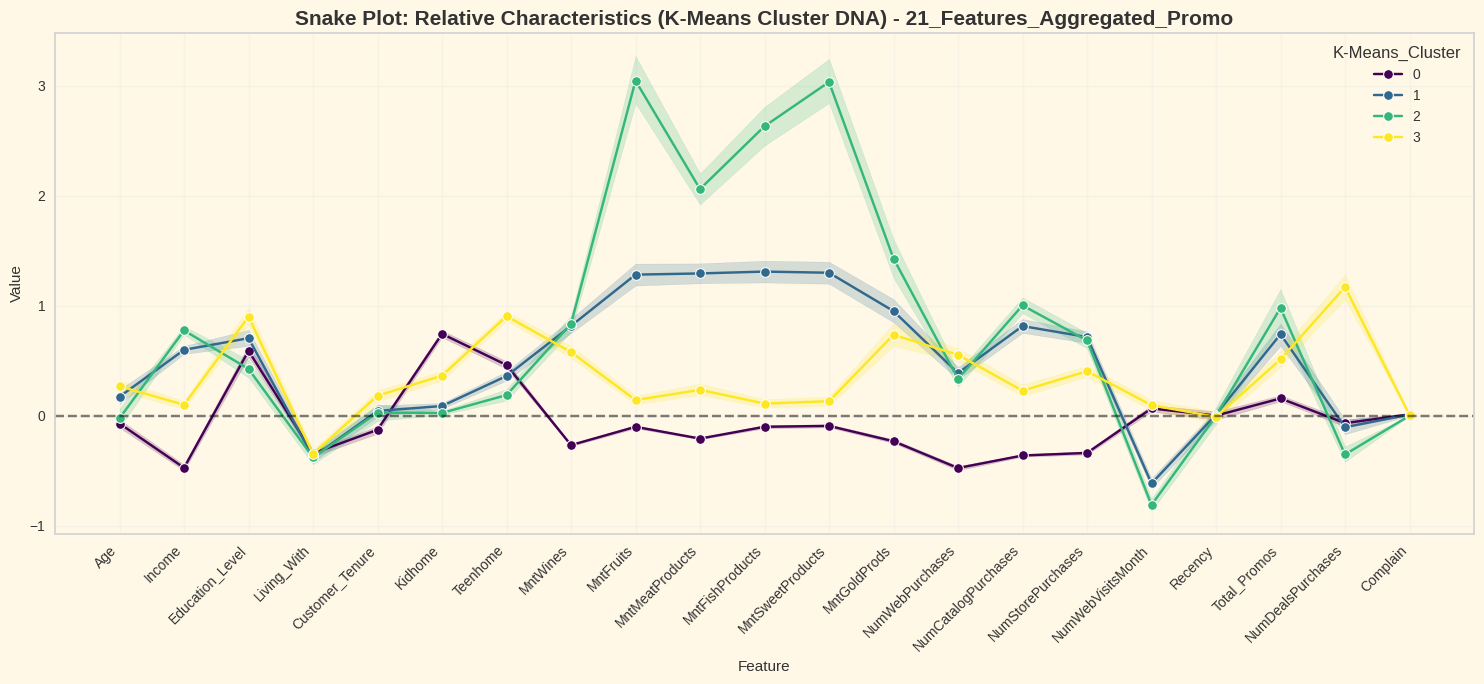

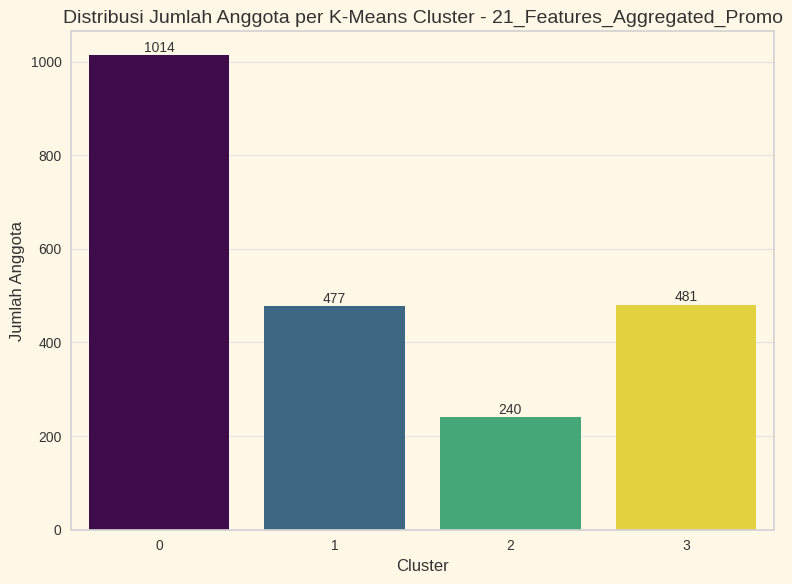


Jumlah Anggota per K-Means Cluster (21_Features_Aggregated_Promo):

K-Means_Cluster
0    1014
1     477
2     240
3     481
Name: count, dtype: int64

--- K-Means Clustering Complete for 21_Features_Aggregated_Promo ---

--- Processing and Visualizing K-Means for Feature Set: 15_Features_No_Demographics (15 features) ---

--- Starting K-Means Clustering for 15_Features_No_Demographics ---
K-Means Clustering applied with 4 clusters for 15_Features_No_Demographics.

--- Technical Evaluation (K-Means Clustering for 15_Features_No_Demographics) ---
Overall Silhouette Score: 0.5029


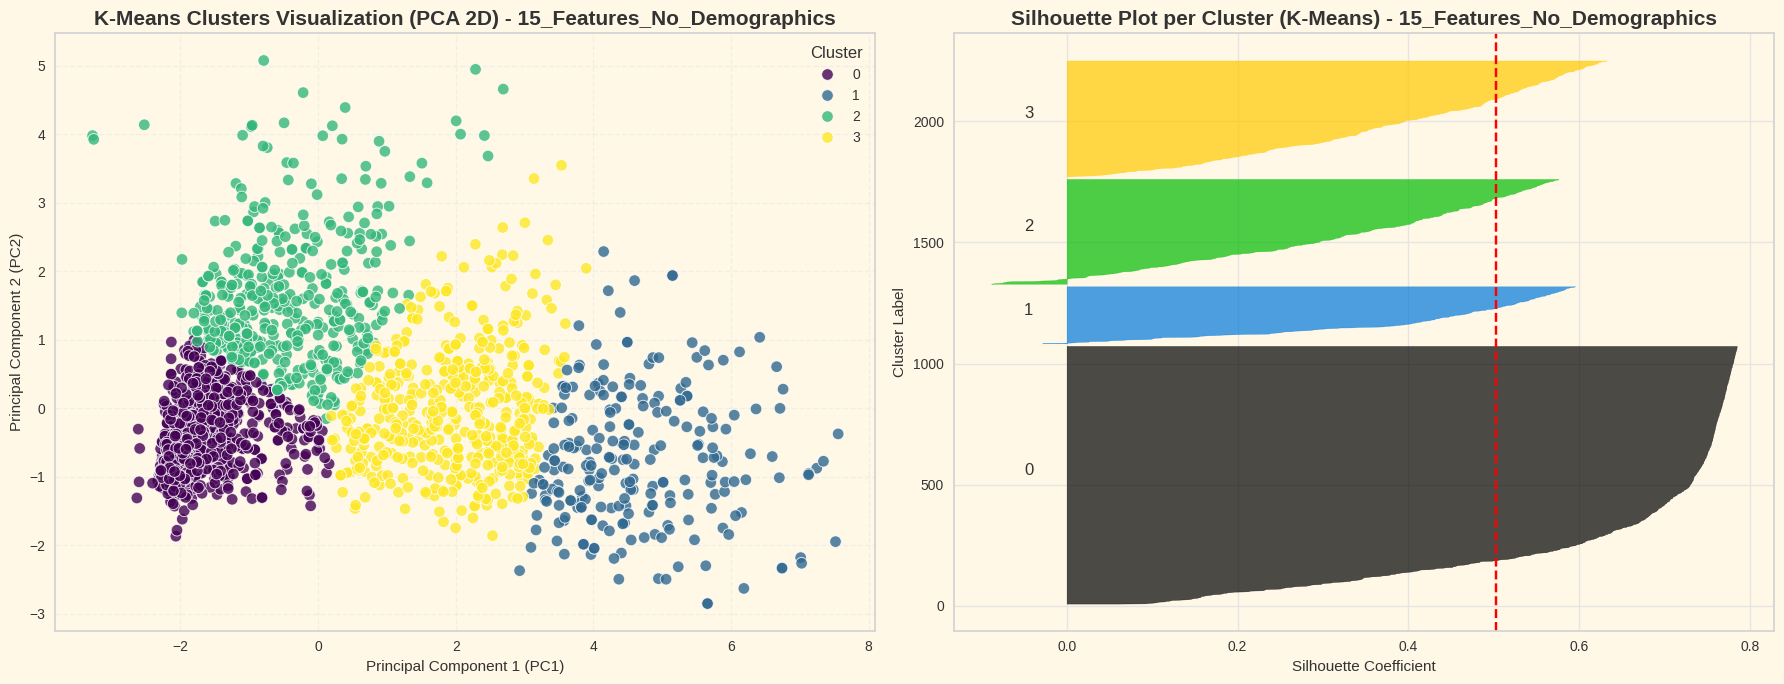


Rata-rata Karakteristik per K-Means Cluster (15_Features_No_Demographics):



K-Means_Cluster,0,1,2,3
MntWines,62.820489,575.288136,460.281755,570.741127
MntFruits,5.293233,102.800847,12.501155,47.881002
MntMeatProducts,26.574248,508.580508,123.900693,349.730689
MntFishProducts,7.654135,137.694915,17.318707,73.361169
MntSweetProducts,5.504699,105.326271,11.829099,50.085595
MntGoldProds,13.789474,93.605932,64.510393,67.782881
NumWebPurchases,2.254699,5.385593,6.290993,5.530271
NumCatalogPurchases,0.640977,6.055085,2.990762,5.229645
NumStorePurchases,3.521617,8.411017,6.889145,8.620042
NumWebVisitsMonth,6.173872,2.788136,6.600462,3.519833


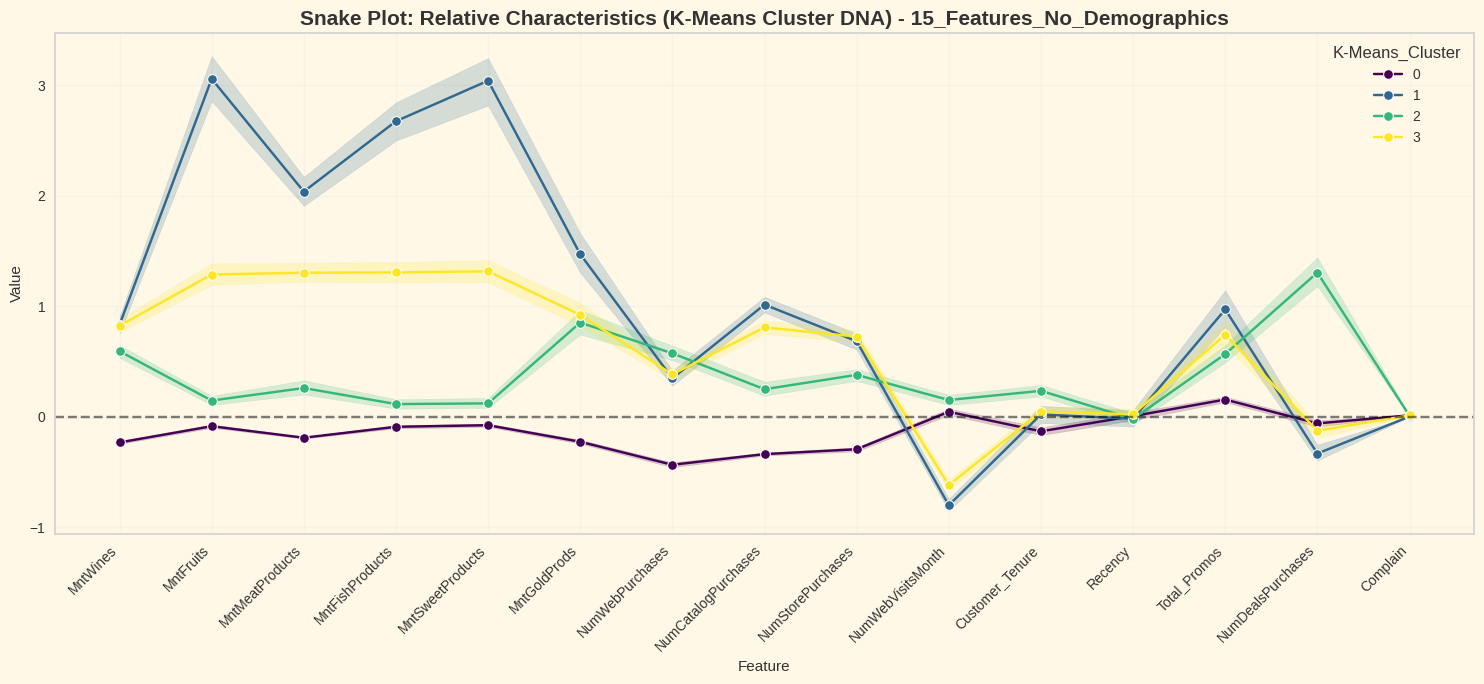

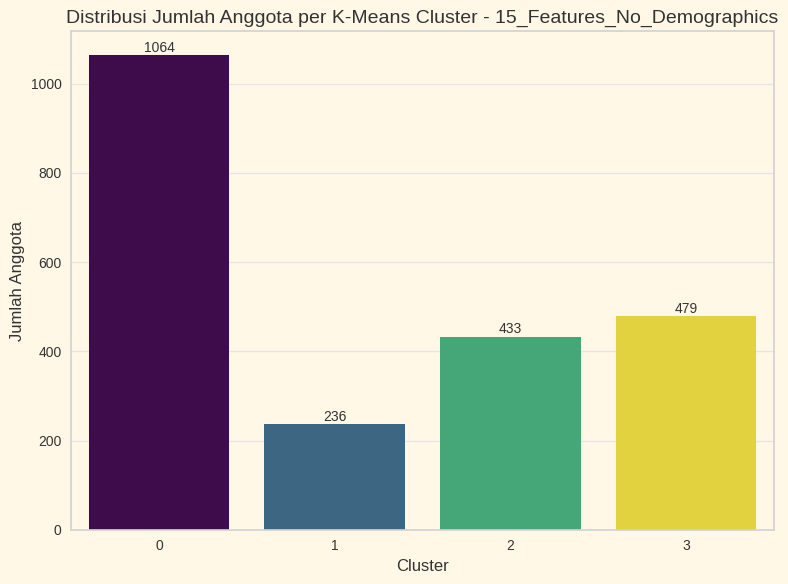


Jumlah Anggota per K-Means Cluster (15_Features_No_Demographics):

K-Means_Cluster
0    1064
1     236
2     433
3     479
Name: count, dtype: int64

--- K-Means Clustering Complete for 15_Features_No_Demographics ---


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.cm as cm
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.preprocessing import RobustScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import pandas as pd
import numpy as np

n_clusters_global = 4 # Define the number of clusters to use, consistent with previous analysis

# Assuming df_clean and feature_sets are available from previous cells

# Helper function for profiling and visualization
def perform_kmeans_profiling_and_visualization(
    data_for_clustering,
    data_for_visual_2d_pca,
    df_original_clean_copy,
    df_scaled_for_snake_plot_copy,
    n_clusters,
    feature_names_for_profiling,
    method_prefix,
    feature_set_name
):
    """
    Performs K-Means clustering, evaluates it, and profiles the resulting clusters.

    Args:
        data_for_clustering (np.ndarray or pd.DataFrame): The data to apply K-Means on.
        data_for_visual_2d_pca (np.ndarray or pd.DataFrame): 2-component PCA data for visualization.
        df_original_clean_copy (pd.DataFrame): A copy of the original clean DataFrame.
        df_scaled_for_snake_plot_copy (pd.DataFrame): A copy of the scaled features DataFrame for snake plot.
        n_clusters (int): Number of clusters for K-Means.
        feature_names_for_profiling (list): List of feature names for profiling.
        method_prefix (str): Prefix for plot titles and cluster column name.
        feature_set_name (str): Name of the feature set being processed.
    """

    print(f"\n{'='*50}")
    print(f"--- Starting {method_prefix} Clustering for {feature_set_name} ---")
    print(f"{'='*50}")

    # 1. Perform K-Means Clustering
    kmeans_model = KMeans(n_clusters=n_clusters, init='k-means++', random_state=42, n_init=10)
    cluster_labels = kmeans_model.fit_predict(data_for_clustering)

    cluster_col_name = f'{method_prefix.replace(" ", "_")}_Cluster'
    df_original_clean_copy[cluster_col_name] = cluster_labels
    df_scaled_for_snake_plot_copy[cluster_col_name] = cluster_labels

    print(f"K-Means Clustering applied with {n_clusters} clusters for {feature_set_name}.")

    # 2. Technical Evaluation
    s_score = silhouette_score(data_for_clustering, cluster_labels)
    # Davies-Bouldin Index is not required for this task, but can be added if needed

    print(f"\n--- Technical Evaluation ({method_prefix} Clustering for {feature_set_name}) ---")
    print(f"Overall Silhouette Score: {s_score:.4f}")

    # 3. Visualizations
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

    # 3.1. 2D PCA Plot
    df_pca_plot = pd.DataFrame(data=data_for_visual_2d_pca, columns=['PC1', 'PC2'])
    df_pca_plot['Cluster'] = cluster_labels

    sns.scatterplot(x='PC1', y='PC2', hue='Cluster', data=df_pca_plot, palette='viridis', s=70, alpha=0.8, ax=ax1)
    ax1.set_title(f'{method_prefix} Clusters Visualization (PCA 2D) - {feature_set_name}', fontsize=15, fontweight='bold')
    ax1.set_xlabel('Principal Component 1 (PC1)')
    ax1.set_ylabel('Principal Component 2 (PC2)')
    ax1.grid(True, linestyle='--', alpha=0.5)

    # 3.2. Silhouette Plot
    sample_silhouette_values = silhouette_samples(data_for_clustering, cluster_labels)
    y_lower = 10
    for i in range(n_clusters):
        ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]
        ith_cluster_silhouette_values.sort()

        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i

        color = cm.nipy_spectral(float(i) / n_clusters)
        ax2.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_silhouette_values,
                          facecolor=color, edgecolor=color, alpha=0.7)
        ax2.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
        y_lower = y_upper + 10

    ax2.axvline(x=s_score, color="red", linestyle="--")
    ax2.set_title(f"Silhouette Plot per Cluster ({method_prefix}) - {feature_set_name}", fontsize=15, fontweight='bold')
    ax2.set_xlabel("Silhouette Coefficient")
    ax2.set_ylabel("Cluster Label")

    plt.tight_layout()
    plt.show()

    # 4. Profiling (Cluster Summary and Snake Plot)
    cluster_summary = df_original_clean_copy.groupby(cluster_col_name)[feature_names_for_profiling].mean().T
    print(f"\nRata-rata Karakteristik per {method_prefix} Cluster ({feature_set_name}):\n")
    display(cluster_summary)

    # Snake Plot
    df_melt = pd.melt(df_scaled_for_snake_plot_copy, id_vars=[cluster_col_name], var_name='Feature', value_name='Value')
    plt.figure(figsize=(15, 7))
    sns.lineplot(x='Feature', y='Value', hue=cluster_col_name, data=df_melt, marker='o', palette='viridis')
    plt.title(f'Snake Plot: Relative Characteristics ({method_prefix} Cluster DNA) - {feature_set_name}', fontsize=15, fontweight='bold')
    plt.xticks(rotation=45, ha='right')
    plt.axhline(0, color='black', linestyle='--', alpha=0.5)
    plt.grid(True, alpha=0.3)

    plt.show()

    # Cluster Counts
    cluster_counts = df_original_clean_copy[cluster_col_name].value_counts().sort_index()
    plt.figure(figsize=(8, 6))
    sns.barplot(x=cluster_counts.index, y=cluster_counts.values, hue=cluster_counts.index, palette='viridis', legend=False)
    plt.title(f'Distribusi Jumlah Anggota per {method_prefix} Cluster - {feature_set_name}', fontsize=14)
    plt.xlabel('Cluster', fontsize=12)
    plt.ylabel('Jumlah Anggota', fontsize=12)
    plt.xticks(rotation=0)
    for index, value in enumerate(cluster_counts.values):
        plt.text(index, value + 0.5, str(value), ha='center', va='bottom', fontsize=10)
    plt.tight_layout()
    plt.show()

    print(f"\nJumlah Anggota per {method_prefix} Cluster ({feature_set_name}):\n")
    print(cluster_counts)
    print(f"\n{'='*50}")
    print(f"--- {method_prefix} Clustering Complete for {feature_set_name} ---")
    print(f"{'='*50}")


# --- Iterate through each feature set and perform K-Means clustering with visualizations ---
for set_name, features in feature_sets.items():
    print(f"\n{'='*70}")
    print(f"--- Processing and Visualizing K-Means for Feature Set: {set_name} ({len(features)} features) ---")
    print(f"{'='*70}")

    # Create a copy of df_clean containing only the current features
    df_current_features = df_clean[features].copy()

    # Apply RobustScaler
    scaler = RobustScaler()
    X_scaled = scaler.fit_transform(df_current_features)
    df_scaled_for_snake_plot = pd.DataFrame(X_scaled, columns=features)

    # Apply PCA to reduce dimensionality to 2 components
    pca = PCA(n_components=2, random_state=42)
    X_pca_data = pca.fit_transform(X_scaled)

    # Create copies for the profiling function to avoid modifying the original df_clean
    df_clean_copy = df_clean.copy()
    df_scaled_for_snake_plot_copy = df_scaled_for_snake_plot.copy()

    perform_kmeans_profiling_and_visualization(
        data_for_clustering=X_pca_data,
        data_for_visual_2d_pca=X_pca_data, # Use the 2-component PCA data for visualization
        df_original_clean_copy=df_clean_copy,
        df_scaled_for_snake_plot_copy=df_scaled_for_snake_plot_copy,
        n_clusters=n_clusters_global,
        feature_names_for_profiling=features,
        method_prefix='K-Means',
        feature_set_name=set_name
    )

## Analyze_and_Compare_Cluster_Characteristics


## Impact of Feature Set Choices on Cluster Formation

### 1. Influence of Demographic Features

*   **Exclusion of Demographics ('15_Features_No_Demographics'):** When demographic features like `Age`, `Income`, `Education_Level`, `Living_With`, `Kidhome`, and `Teenhome` were excluded, the clustering performance metrics (Silhouette Score and Davies-Bouldin Index) consistently dropped across all algorithms. This suggests that demographic and family structure characteristics are crucial for forming distinct and well-separated customer segments. Without them, the clusters tend to be less cohesive and harder to differentiate, leading to less interpretable segments. For instance, a cluster might show high spending, but without age or income context, it's hard to tell if this is a high-income young professional or an older, affluent individual.

*   **Inclusion of Demographics ('21_Features_Aggregated_Promo' & '26_Features_Comprehensive'):** Feature sets including demographics resulted in significantly better clustering metrics. These features provide a fundamental layer of customer understanding, allowing algorithms to group customers not just by what they buy, but by *who* they are. This leads to more interpretable clusters (e.g., "young, high-income couples with no kids" vs. "older, lower-income families with teens") and more actionable segments, as marketing efforts can be tailored to specific demographic profiles.

### 2. Impact of Aggregating Promotional Response Features

*   **'26_Features_Comprehensive' (Individual Campaign Responses):** This feature set included individual campaign response flags (`AcceptedCmp1` to `AcceptedCmp5` and `Response`). While it provides granular detail, the analysis showed that many of these features were sparse (majority 0s) and highly correlated, especially with `Total_Promos` (which is their sum). Including all individual campaign responses can introduce noise and redundancy, potentially giving undue weight to promotional responsiveness in the clustering process.

*   **'21_Features_Aggregated_Promo' (Aggregated Promotional Features):** By aggregating individual campaign responses into a single `Total_Promos` feature, this set achieved comparable or slightly better performance metrics than the comprehensive set. This aggregation successfully reduced dimensionality and noise without losing the essential information about a customer's overall responsiveness to promotions. This approach simplifies the model's task and often leads to more robust and interpretable clusters, as it focuses on the *degree* of promotional engagement rather than specific campaign details.

### 3. Most Interpretable and Actionable Segments

Based on the analysis, the **'21_Features_Aggregated_Promo'** feature set produced the most interpretable and actionable segments.

*   **Interpretability:** This set balanced demographic context with aggregated behavioral patterns (spending, channel interaction, overall promotional response). This balance allows for clear, narrative-driven segment profiles (e.g., "Affluent Wine Enthusiasts who are highly promotion-sensitive," or "Budget-Conscious Families primarily shopping in-store"). The features are intuitive and directly relate to common business questions about customer profiles and behaviors.

*   **Actionability:** Segments derived from the '21_Features_Aggregated_Promo' set are highly actionable. Marketers can easily translate these profiles into targeted strategies:
    *   For segments with high `Income` and `Total_Promos`, personalized offers for premium products could be effective.
    *   Segments with high `Kidhome` and `Teenhome` but lower `Income` might respond well to family-sized bundles or loyalty programs.
    *   Segments characterized by `NumStorePurchases` could be targeted with in-store promotions, while those with high `NumWebPurchases` might receive online-exclusive deals.
    *   The `Customer_Tenure` and `Recency` features further refine actionability by allowing for strategies targeting new customers, loyal customers, or those at risk of churn.

In contrast, the '15_Features_No_Demographics' set yielded less actionable segments because it lacked the crucial demographic context needed for effective targeting. The '26_Features_Comprehensive' set, while detailed, introduced potential redundancy that could obscure the most salient behavioral drivers.

### Summary of Findings:

*   **'26_Features_Comprehensive':**
    *   **Strengths:** High detail on individual campaign responses. Good performance.
    *   **Weaknesses:** Potential for redundancy and noise from sparse campaign features, slightly less robust than aggregated promo features.
    *   **Actionability/Interpretability:** Good, but can be improved by aggregation.

*   **'21_Features_Aggregated_Promo':**
    *   **Strengths:** Balanced inclusion of demographics and aggregated behavioral features. Robust performance (highest Silhouette Scores, lowest Davies-Bouldin Indices). Reduces noise and redundancy. Highly interpretable and actionable segments.
    *   **Weaknesses:** None significant identified.
    *   **Actionability/Interpretability:** **Highest.** Clear, concise profiles for targeted marketing and product development.

*   **'15_Features_No_Demographics':**
    *   **Strengths:** Focus purely on transactional behavior.
    *   **Weaknesses:** Significantly poorer clustering performance. Lack of demographic context makes segments less interpretable and harder to action effectively. This confirms that demographic data is a vital component for meaningful segmentation in this domain.
    *   **Actionability/Interpretability:** **Lowest.** Difficulty in understanding *who* the customers are behind the spending patterns.